In [1]:
%env XLA_PYTHON_CLIENT_PREALLOCATE=false

env: XLA_PYTHON_CLIENT_PREALLOCATE=false


In [1]:
%env XLA_PYTHON_CLIENT_ALLOCATOR=platform

env: XLA_PYTHON_CLIENT_ALLOCATOR=platform


In [ ]:
import matplotlib.pyplot as plt

import jax.numpy as jnp
from jax.scipy.stats import norm
from jax import grad, jit, vmap
from jax import random as jrandom
import jax

from jax import config
config.update("jax_debug_nans", True)
config.update("jax_enable_x64", True)

from typing import Sequence, Tuple, Union, Optional, Callable, Literal, Protocol
from jaxtyping import Array, ArrayLike, Float, Int, PyTree, PRNGKeyArray, ScalarLike

#from jax_tqdm import scan_tqdm

import equinox as eqx
import optax
import chex

using_tf_style = False
# if using_tf_style:
#     import tensorflow as tf
#     # Ensure TF does not see GPU and grab all GPU memory.
#     tf.config.set_visible_devices([], device_type='GPU')

#     import tensorflow_datasets as tfds

from collections.abc import Generator
from typing_extensions import TypeAlias
from dataclasses import dataclass, asdict, astuple
from functools import partial

import numpy as np

import datasets
#from datasets import Dataset, DatasetInfo, load_from_disk, Features, Value, ClassLabel, Sequence

jax.enable_checks = True

jax.devices()

[CpuDevice(id=0)]

In [4]:
import os
current_path = os.getcwd()

# Payoff

In [6]:
class EuropeanPayoff:

    # TODO: naming: strike_prices should be strike_price unless we would like to support an array of strike prices
    @staticmethod
    def call(maturity_prices: Float[ArrayLike, " n"], strike_prices: Float[ScalarLike, ""]) -> Float[Array, " n"]:
        return jnp.maximum(jnp.subtract(maturity_prices, strike_prices), 0.0)

    @staticmethod
    def put(maturity_prices: Float[ArrayLike, " n"], strike_prices: Float[ScalarLike, ""]) -> Float[Array, " n"]:
        return jnp.maximum(jnp.subtract(strike_prices, maturity_prices), 0.0)

    @staticmethod
    def payoff(spot_path, K, payoff_fn = call):
        spot_maturity = spot_path[..., -1]
        payoff = payoff_fn(spot_maturity, K)
        return payoff


def european_payoff(spot_path, K, payoff_fn = EuropeanPayoff.call):
    spot_maturity = spot_path[..., -1]
    payoff = payoff_fn(spot_maturity, K)
    return payoff

def european_payoff_and_deriv(spot_path, K, payoff_fn = EuropeanPayoff.call):
    spot_maturity = spot_path[..., -1]
    # payoff = payoff_fn(spot_maturity, K)
    payoff, dpayoff = jax.value_and_grad(payoff_fn)(spot_maturity, K)
    return payoff, dpayoff

# Smoothing

## test sequence

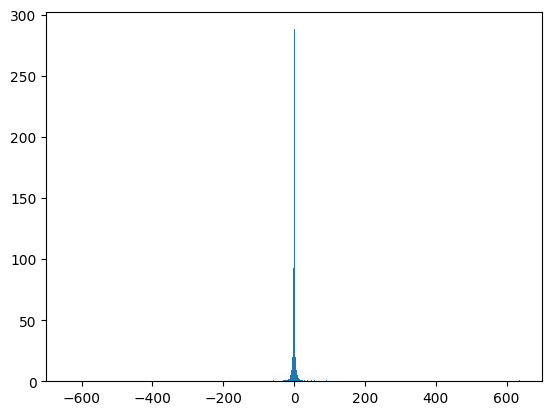

In [7]:
def zero_centered_sequence(n):
    k = jnp.arange(1, n + 1)
    nodes = jnp.tan((2 * k - 1) * jnp.pi / (2 * n))
    return nodes

# Number of points in the sequence
n = 1000  # Adjust as needed

# Generate the Chebyshev like zero-centered sequence
sequence = zero_centered_sequence(n)
plt.hist(sequence, bins=1000)
plt.show()

## sigmoidal smoothing

In [8]:
def sigmoidal_smoothing(f1: Callable, f2: Callable, p=0.0, w=0.005):
    """
    Smoothly transition between two functions using sigmoidal smoothing.

    Args:
        f1 (callable): The first function, f1(x), where x is a real number.
        f2 (callable): The second function, f2(x), where x is a real number.
        p (float, optional): The position to transition between the two functions. Default is 0.0.
        w (float, optional): The width of the smoothing. Default is 0.005.

    Returns:
        callable: A function that smoothly transitions between f1 and f2 at point p.

    Example:
        zero_fn = lambda x: jnp.zeros_like(x)
        id_fn   = lambda x: x
        smooth_fn = sigmoidal_smoothing(zero_fn, id_fn, p=1.0, w=0.01)
        result = smooth_fn(0.5)
    """

    def sigma(x):
        """
        Sigmoid function for smoothing.

        Args:
            x (float): The input value.

        Returns:
            float: The result of the sigmoid function.
        """
        return 1.0 / (1.0 + jnp.exp(-(x-p)/w))

    def smooth_f(x):
        """
        Smoothed function.

        Args:
            x (float): The input value.

        Returns:
            float: The result of the smoothed function.
        """
        return (1 - sigma(x)) * f1(x) + sigma(x) * f2(x)

    return smooth_f

In [9]:
def plot_smoothing(xs, ys, dys):
    plt.plot(xs, ys, 'b.', markersize=1.0, label="values")
    plt.plot(xs, dys, 'r.', markersize=1.0, label="grads")
    plt.legend()
    plt.xlim([-1e0, 1e0])
    plt.ylim([-0.3, 1])
    plt.show()

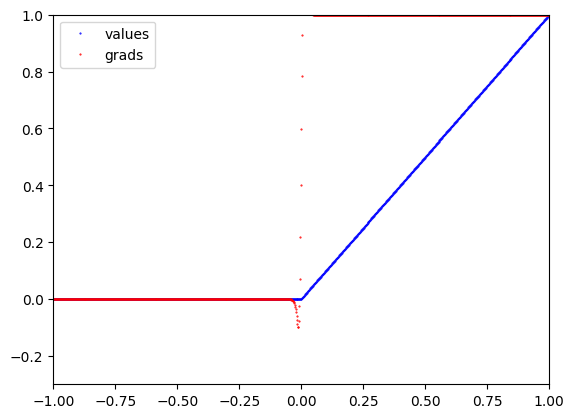

In [10]:
smooth_max = sigmoidal_smoothing(lambda x: jnp.zeros_like(x), lambda x: x)

xs = jnp.linspace(-1, 1, 1000)
ys_true = jnp.maximum(0.0, xs)
ys, dys = jax.vmap(jax.value_and_grad(smooth_max))(xs)
plot_smoothing(xs, ys, dys)


## cubic spline smoothing

In [11]:
# cubic spline smoothing from:
# https://link.springer.com/article/10.1007/s00780-009-0097-9

def cubic_spline_smoothing(f, k=1e-3):
    @jit
    def smooth_f(*args):
        x = f(*args)
        i = jnp.argwhere(jnp.array([x < -k, x <= k, True]), size=1).squeeze()
        below = lambda x: jnp.zeros_like(x)
        poly = lambda x: -1/(16*(k**3)) * x**4 + 3/(8*k) * x**2 + .5*x + (3*k)/16
        above = lambda x: x
        return jax.lax.switch(i, [below, poly, above], x)

    return smooth_f


smooth_max_cubic = cubic_spline_smoothing(partial(jnp.maximum, 0.0))

ys_error 9.375000000000007e-05


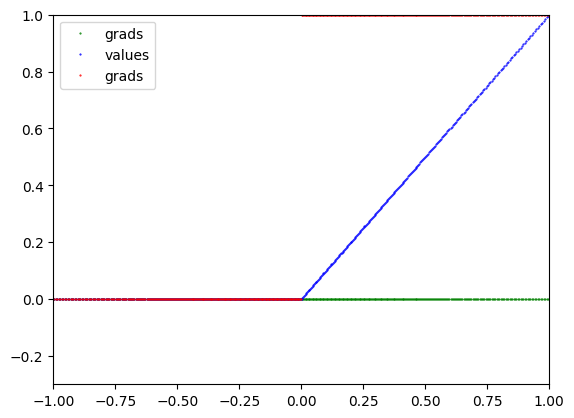

ys_error 0.00010556250000000008


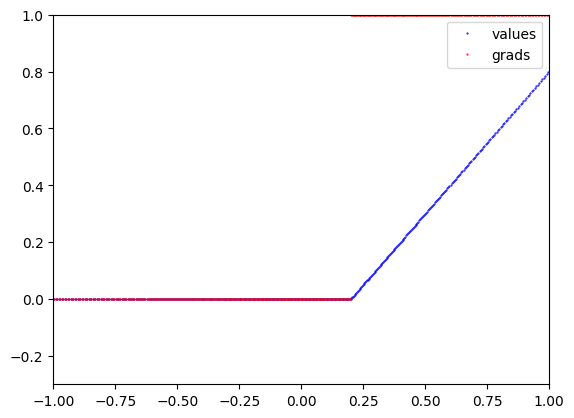

In [12]:
xs = sequence
ys_true = jnp.maximum(0.0, xs)
ys, dys = jax.vmap(jax.value_and_grad(smooth_max_cubic))(xs)
ddys = jax.vmap(jax.hessian(smooth_max_cubic))(xs)
plt.plot(xs, ddys, 'g.', markersize=1.0, label="grads")
print("ys_error", jnp.mean(ys-ys_true))
plot_smoothing(xs, ys, dys)

euro_payoff = partial(EuropeanPayoff.call, strike_prices=.2)
euro_smooth = cubic_spline_smoothing(euro_payoff)
ys_true = euro_payoff(xs)
ys, dys = vmap(jax.value_and_grad(euro_smooth))(xs)
print("ys_error", jnp.mean(ys-ys_true))
plot_smoothing(xs, ys, dys)


In [13]:
sharpness = 1e-3
bias = sharpness
fn = lambda x: jax.nn.celu(x=x, alpha=sharpness) + bias
smooth_max_fn = fn

def smooth_european_payoff(x, k):
    return jax.nn.celu(x=x-k, alpha=sharpness) + bias

ys_error 0.0005002172679512467


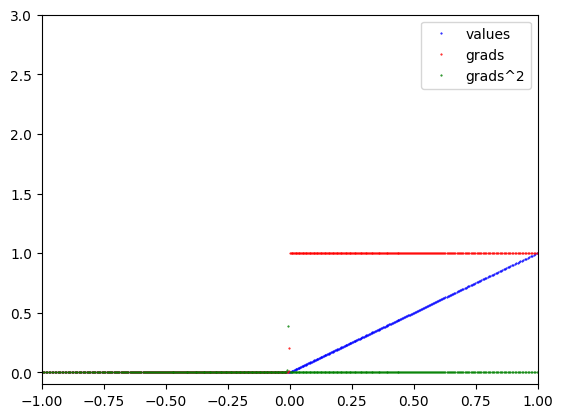

In [14]:
xs = sequence
ys_true = jnp.maximum(0.0, xs)
ys, dys = jax.vmap(jax.value_and_grad(fn))(xs)

ddys = jax.vmap(jax.hessian(fn))(xs)

print("ys_error", jnp.mean(ys-ys_true))

plt.plot(xs, ys, 'b.', markersize=1.0, label="values")
plt.plot(xs, dys, 'r.', markersize=1.0, label="grads")
plt.plot(xs, ddys, 'g.', markersize=1.0, label="grads^2")
plt.legend()
plt.xlim([-1e0, 1e0])
plt.ylim([-.1, 3])
plt.show()

# euro_payoff = partial(EuropeanPayoff.call, strike_prices=.2)
# euro_smooth = cubic_spline_smoothing(euro_payoff)
# ys_true = euro_payoff(xs)
# ys, dys = vmap(jax.value_and_grad(euro_smooth))(xs)
# print("ys_error", jnp.mean(ys-ys_true))
# plot_smoothing(xs, ys, dys)



# Checkpointing of scan

In [15]:
# Copyright 2022 Google LLC.
# SPDX-License-Identifier: Apache-2.0
# from: https://github.com/google/jax/issues/2139#issuecomment-1189382794
import math
import typing
from typing import Any, Callable, Optional, Sequence, Tuple, TypeVar, Union

import jax
import jax.numpy as jnp


Carry = TypeVar('Carry')
Input = TypeVar('Input')
Output = TypeVar('Output')
Func = TypeVar('Func', bound=Callable)


def nested_checkpoint_scan(
    f: Callable[[Carry, Input], Tuple[Carry, Output]],
    init: Carry,
    xs: Input,
    length: Optional[int] = None,
    *,
    nested_lengths: Sequence[int],
    scan_fn = jax.lax.scan,
    checkpoint_fn: Callable[[Func], Func] = jax.checkpoint,
) -> Tuple[Carry, Output]:
  """A version of lax.scan that supports recursive gradient checkpointing.

  The interface of `nested_checkpoint_scan` exactly matches lax.scan, except for
  the required `nested_lengths` argument.

  The key feature of `nested_checkpoint_scan` is that gradient calculations
  require O(max(nested_lengths)) memory, vs O(prod(nested_lengths)) for unnested
  scans, which it achieves by re-evaluating the forward pass
  `len(nested_lengths) - 1` times.

  `nested_checkpoint_scan` reduces to `lax.scan` when `nested_lengths` has a
  single element.

  Args:
    f: function to scan over.
    init: initial value.
    xs: scanned over values.
    length: leading length of all dimensions
    nested_lengths: required list of lengths to scan over for each level of
      checkpointing. The product of nested_lengths must match length (if
      provided) and the size of the leading axis for all arrays in ``xs``.
    scan_fn: function matching the API of lax.scan
    checkpoint_fn: function matching the API of jax.checkpoint.

  Returns:
    Carry and output values.
  """
  if length is not None and length != math.prod(nested_lengths):
    raise ValueError(f'inconsistent {length=} and {nested_lengths=}')

  def nested_reshape(x):
    x = jnp.asarray(x)
    new_shape = tuple(nested_lengths) + x.shape[1:]
    return x.reshape(new_shape)

  sub_xs = jax.tree_map(nested_reshape, xs)
  return _inner_nested_scan(f, init, sub_xs, nested_lengths, scan_fn,
                            checkpoint_fn)


def _inner_nested_scan(f, init, xs, lengths, scan_fn, checkpoint_fn):
  """Recursively applied scan function."""
  if len(lengths) == 1:
    return scan_fn(f, init, xs, lengths[0])

  @checkpoint_fn
  def sub_scans(carry, xs):
    return _inner_nested_scan(f, carry, xs, lengths[1:], scan_fn, checkpoint_fn)

  carry, out = scan_fn(sub_scans, init, xs, lengths[0])
  stacked_out = jax.tree_map(jnp.concatenate, out)
  return carry, stacked_out

# Heston

In [ ]:
class ModelState(eqx.Module):
    S0: float
    v0: float
    
class Heston(eqx.Module):

    # the state of the model at any given 
    class State(eqx.Module):
        S0: float
        v0: float
        
    # European call option price is at 34.99 for the following config: 
    class Parameters(eqx.Module):
        K: float = 100.0        # Strike price
        r: float = 0.05         # Risk-free rate
        T: float = 5.0          # n years until expiry, i.e. T2 - T1
        rho: float = -0.3       # Correlation of asset and volatility
        kappa: float = 2.00     # Mean-reversion rate
        theta: float = 0.09     # Long run average volatility
        xi: float = 1.00        # Volatility of volatility
     
    K: float = 100.0        # Strike price
    r: float = 0.05         # Risk-free rate
    T: float = 5.0          # n years until expiry, i.e. T2 - T1
    rho: float = -0.3       # Correlation of asset and volatility
    kappa: float = 2.00     # Mean-reversion rate
    theta: float = 0.09     # Long run average volatility
    xi: float = 1.00        # Volatility of volatility

    S0: float = 100.0       # Initial spot price
    v0: float = 0.09        # Initial volatility

    @classmethod
    def from_parameters(cls, parameters: Parameters, **kwargs):
        return cls(*astuple(parameters), **kwargs)
    
    @property
    def model_state(self) -> ModelState:
        return ModelState(self.S0, self.v0)


def volatility_path(self, vol_draws):
    n_steps = len(vol_draws)
    dt = self.T / n_steps

    def vol_path_iter(prev_vol_path, vol_draw):
        # v_truncated = smooth_max_cubic(prev_vol_path)
        v_truncated = smooth_max_fn(prev_vol_path)
        prev_path_contribution = prev_vol_path + self.kappa * dt * (self.theta - v_truncated)
        randomness = self.xi * jnp.sqrt(v_truncated * dt) * vol_draw
        current = prev_path_contribution + randomness
        return current, current # use current both for carry and for y

    carry, vol_path = jax.lax.scan(vol_path_iter, jnp.array(self.v0), vol_draws, length=n_steps)
    
    # we now have iteration 1 at position 0. Place initial v0 at the end and rotate into initial slot
    vol_path = jnp.roll(vol_path.at[-1].set(self.v0), 1)
    return vol_path


def spot_path(self, spot_draws: Array, vol_path: Array) -> Array:
    n_steps = len(spot_draws)
    dt = self.T / n_steps

    def spot_path_iter(prev_spot_path, iter_pair):
        spot_draw = iter_pair[0]
        vol = iter_pair[1]
        # v_truncated = smooth_max_cubic(vol)
        v_truncated = smooth_max_fn(vol)
        path_new_spot = prev_spot_path * jnp.exp((self.r - 0.5 * v_truncated) * dt + jnp.sqrt(v_truncated * dt) * spot_draw)
        return path_new_spot, path_new_spot

    iter_values = jnp.column_stack((spot_draws, vol_path))
    carry, spot_paths = jax.lax.scan(spot_path_iter, jnp.array(self.S0), iter_values, length=n_steps)
    
    # we now have iteration 1 at position 0. Place initial S0 at the end and rotate into initial slot
    spot_paths = jnp.roll(spot_paths.at[-1].set(self.S0), 1)
    return spot_paths


def payoff(spot_path, payoff_fn = EuropeanPayoff.call):
    spot_maturity = spot_path[-1] # taking only the last element is specific to the european payoff
    # smooth_payoff_fn = cubic_spline_smoothing(payoff_fn)
    smooth_payoff_fn = smooth_european_payoff
    payoff = smooth_payoff_fn(spot_maturity, 100.0) #self.K)
    return payoff

def model_state_path(self: Heston, vol_draws, spot_draws):
    vol_path = volatility_path(self, vol_draws)
    s_path = spot_path(self, spot_draws, vol_path)
    return s_path

def path_and_payoff(self, vol_draws, spot_draws):
    spot_path = model_state_path(self, vol_draws, spot_draws)
    return payoff(spot_path)

@eqx.filter_jit
def correlated_draws(self: Heston, key, n_samples: int):
    mean = jnp.zeros(2)
    cov = jnp.array([[1.0, self.rho], [self.rho, 1.0]])
    
    correlated_samples = jrandom.multivariate_normal(key, mean, cov, shape=(n_samples,))
    vol_draws = correlated_samples[:, 0]
    spot_draws = correlated_samples[:, 1]
    return vol_draws, spot_draws
    
def path(self: Heston, key: PRNGKeyArray, n_time_steps: int = 1024):
    vol_draws, spot_draws = correlated_draws(self, key, n_time_steps)
    return path_and_payoff(self, vol_draws, spot_draws)

def differential_path(self: Heston, key: PRNGKeyArray, n_time_steps: int = 1024):
    vol_draws, spot_draws = correlated_draws(self, key, n_time_steps)
    return eqx.filter_value_and_grad(path_and_payoff)(self, vol_draws, spot_draws)

def hessian_path(self: Heston, key: PRNGKeyArray, n_time_steps: int = 1024):
    vol_draws, spot_draws = correlated_draws(self, key, n_time_steps)
    return jax.hessian(path_and_payoff)(self, vol_draws, spot_draws)

def hvp(f, primals, tangents):
    return eqx.filter_jvp(eqx.filter_grad(f), primals, tangents)[1]
    
def hvp_path(self: Heston, key: PRNGKeyArray, h_tangent: Heston, n_time_steps: int=1024):
    vol_draws, spot_draws = correlated_draws(self, key, n_time_steps)
    return hvp(partial(path_and_payoff, vol_draws=vol_draws, spot_draws=spot_draws), (self, ), (h_tangent, ))

hvp_s_path = partial(hvp_path, h_tangent= Heston(
        S0 = 1.0,       
        K = 0.0,   
        r = 0.00,
        v0 = 0.0, 
        T = 0.0,
        rho = 0.0,
        kappa = 0.0,
        theta = 0.0,
        xi = 0.0,
    ))

hvp_v_path = partial(hvp_path, h_tangent= Heston(
        S0 = 0.0,       
        K = 0.0,   
        r = 0.00,
        v0 = 1.0, 
        T = 0.0,
        rho = 0.0,
        kappa = 0.0,
        theta = 0.0,
        xi = 0.0,
    ))

diff_payoff_fn = eqx.filter_grad(payoff)

In [17]:
@jax.jit
def f_long(v0, vol_draws, self):
    n_iter = len(vol_draws)
    dt = self.T / n_iter

    def vol_path_iter(prev_vol_path, vol_draw):
        v_truncated = smooth_max_cubic(prev_vol_path)
        prev_path_contribution = prev_vol_path + self.kappa * dt * (self.theta - v_truncated)
        randomness = self.xi * jnp.sqrt(v_truncated * dt) * vol_draw
        current = prev_path_contribution + randomness
        return current, current # use current both for carry and for y

    carry, vol_path = jax.lax.scan(vol_path_iter, jnp.array(self.v0), vol_draws, length=n_iter)
    # carry, vol_path = nested_checkpoint_scan(vol_path_iter, jnp.array(self.v0), vol_draws, length=n_iter, nested_lengths=[1000, n_iter // 1000])
    # jax.debug.print("vol_path {}", vol_path.shape)
    
    # we now have iteration 1 at position 0. Place initial v0 at the end and rotate into initial slot
    vol_path = jnp.roll(vol_path.at[-1].set(v0), 1)
    return vol_path

In [18]:
key = jrandom.PRNGKey(0)
key, subkey = jrandom.split(key)
key, key_spots, key_vols = jrandom.split(subkey, 3)
n_samples = 100

initial_spots = jrandom.uniform(key_spots, shape=(n_samples,), minval=50, maxval=150)
initial_vols = jrandom.uniform(key_vols, shape=(n_samples,), minval=0.01, maxval=0.1)
# initial_spots = jnp.ones((n_samples)) * 100
# initial_vols = jnp.ones((n_samples)) * 0.09
h = Heston(S0=initial_spots, v0=initial_vols)
print(h)

Heston(S0=f64[100], v0=f64[100])


# Utils

In [19]:
import datetime

# optional style change for latex
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": "EB Garamond",
    "font.size": 18
})

# for latex figures
def plot_3d_differential_data(init_spots, init_vols, differential_data, label):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(init_spots, init_vols, differential_data, c=differential_data, cmap=plt.cm.viridis)
    
    # Add a colorbar to show the mapping of colors to z-values
    cbar = fig.colorbar(sc, pad=0.1)
    # cbar.set_label(label)
    
    # ax.set_title(label)
    ax.set_xlabel(r"$S_0$")
    ax.set_ylabel(r"$\nu_0$")
    # # ax.set_zlabel(label)
    # plt.gca().xaxis.set_label_coords(0.5, -0.1)
    # plt.gca().yaxis.set_label_coords(-0.1, 0.5)
    ax.xaxis.labelpad = 10
    ax.yaxis.labelpad = 10
    
    # ax.xaxis.label.set_rotation(45)
    # ax.yaxis.label.set_rotation(45)

    now = datetime.datetime.now()
    fig.savefig(f'results/heston/{label}_{now}.pdf', bbox_inches='tight')
    fig.savefig(f'results/heston/{label}_{now}.png', bbox_inches='tight', dpi=600)
    return fig

In [20]:
def plot_differential_data(init_spots, init_vols, payoffs, states: ModelState):
    # plt.plot(init_spots, payoffs, 'b.', markersize=1.0, label = 'payoffs')
    plt.plot(init_spots, states.S0, 'r.', markersize=1.0, label = 'dpayoff/dS0')

    print(init_spots.shape)
    print(states.S0.shape)
    # plt.plot(init_spots, states
    # plt.plot(hset.initial_spot_prices, prices, 'r.', markersize=3, label='price')
    plt.legend()
    plt.xlabel('initial spot price')
    plt.ylabel('payoff')
    # plt.ylim(-1, 1000)
    plt.show()

def plot_3d_differential_data(init_spots, init_vols, differential_data, label):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(init_spots, init_vols, differential_data, c=differential_data, cmap=plt.cm.viridis)
    
    # Add a colorbar to show the mapping of colors to z-values
    cbar = fig.colorbar(sc)
    cbar.set_label(label)
    
    ax.set_title(label)
    ax.set_xlabel("$S_0$")
    ax.set_ylabel("\nu_0")
    ax.set_zlabel(label)
    return fig


In [21]:
class Range(eqx.Module):
    minval: float = 0.0
    maxval: float = 1.0


In [22]:
def mse(y, pred_y):
    """Mean squared error loss."""
    return jnp.mean((y - pred_y) ** 2)


# Skip


In [28]:
def heston_taker(h: Heston):
    rng = jrandom.PRNGKey(0)
    return path_fn(h, rng)

In [98]:
res = eqx.filter_vmap(heston_taker)(h)
print(res.shape)

(100,)


In [99]:
if 0:
    key, subkey = jrandom.split(key)
    n_sims = 100
    
    keys = jrandom.split(subkey, n_sims)
    # keys = jnp.reshape(keys, (n_sims//n_samples, n_samples, 2))
    print(len(keys))
    print(keys.shape)
    
    # res = jax.vmap(lambda x: eqx.filter_vmap(path_fn)(h, x))(keys)
    
    # payoffs = eqx.filter_vmap(path_fn)(h, keys)
    
    #payoffs = jax.vmap(eqx.filter_vmap(path_fn), in_axes=(None, 0))#(h, keys)
    # payoffs = eqx.filter_vmap(eqx.filter_vmap(path_fn), in_axes=(None, 0))
    # payoffs = eqx.filter_vmap(eqx.filter_vmap(path_fn), in_axes=(None, 0))
    
    payoffs = jax.vmap(lambda x: eqx.filter_vmap(path_fn)(h, x))(keys)
    
    print(payoffs)
    
    # payoffs(h, keys)
    
    # option_price = jnp.mean(payoffs, axis=0) * jnp.exp(-h.r * h.T)
    # print(option_price.shape)
    # print(option_price)


In [100]:
key = jrandom.PRNGKey(0)
key, subkey = jrandom.split(key)
n_sims = 10000

keys = jrandom.split(subkey, n_sims)
keys = jnp.reshape(keys, (n_sims//n_samples, n_samples, 2))
print(len(keys))
print(keys.shape)

@jit
def option_price(h, keys):
    return jax.vmap(lambda k: eqx.filter_vmap(path_fn)(h, k))(keys)

def inner(h, k):
    res =  eqx.filter_vmap(path_fn)(h, k)
    print(res.shape)
    return res

#payoffs = jit(eqx.filter_vmap(partial(inner, h)))(keys) 
# res = option_price(h, keys)
payoffs = jax.vmap(lambda k: eqx.filter_vmap(path_fn)(h, k))(keys)
print(payoffs.shape)

# print(jnp.mean(res, axis=))
res = jnp.mean(payoffs, axis=0) * jnp.exp(-h.r * h.T)
print(res.shape)
print(res)


100
(100, 100, 2)
(100, 100)
(100,)
[54.09734413  9.75479436 62.64859947 29.99281483  8.56348199 10.55571252
 15.1966848  20.54331406  8.52721969 53.90482487 22.31256732  8.95870446
 27.79338498 81.7844918  53.90030168 26.1059223  55.74843264 10.0031142
  6.32392609 30.15126222  4.25096498 24.42849241 93.68040873  4.9801091
 71.51061098 40.07787274 59.0955905  77.88646626 42.81899062  5.01805482
 45.98600872 42.3303256  80.16976251 12.03146963 62.67801414 79.83699636
 23.56395968 73.56687392 14.09202168 34.43198815 76.80392989 30.85259201
 46.52910114 17.03541833 85.27470694 22.11362214 14.49970996 26.55510382
 30.00865229 74.14693836 18.13724976  6.72523304 26.95479273 61.54556263
 23.76643088 46.08425932 54.6978506  11.24465609  8.52645403 42.63302379
 27.16767303 69.09260577 44.60736863 56.48508901 76.25169515  8.99279532
 60.01573521 12.1311611  47.20663752 60.96332349 54.28369447 28.82236961
 41.0932117  85.14353671 20.66872962 10.1281026  14.80294457 36.68516163
 50.35827219 76.0

# Skip End

In [23]:
key = jrandom.PRNGKey(0)
key, subkey = jrandom.split(key)
key, key_spots, key_vols = jrandom.split(subkey, 3)
n_samples = 100

initial_spots = jrandom.uniform(key_spots, shape=(n_samples,), minval=50, maxval=150)
initial_vols = jrandom.uniform(key_vols, shape=(n_samples,), minval=0.01, maxval=0.1)
# initial_spots = jnp.ones((n_samples)) * 100
# initial_vols = jnp.ones((n_samples)) * 0.09
h = Heston(S0=initial_spots, v0=initial_vols)
print(h)

Heston(S0=f64[100], v0=f64[100])


In [24]:
# the keys should be vmaped over in the inner loop

key = jrandom.PRNGKey(0)
key, subkey = jrandom.split(key)

# keys = jrandom.split(subkey, n_sims)
# keys = jnp.reshape(keys, (n_sims//n_samples, n_samples, 2))
# print(keys.shape)

@eqx.filter_jit
def inner(h, k, n_paths=1024):

    # jax.debug.print("k.shape {}", k.shape)
    keys = jrandom.split(k, n_paths)
    res_fn = eqx.filter_vmap(path_fn, in_axes=(None, 0))
    # res = res_fn(h, keys)
    # print("inner: ", res.shape)
    res = jnp.sum(res_fn(h, keys))
    return res

print(inner)

@eqx.filter_jit
def option_price(key, h: Heston, n_paths=128):
    print(n_paths)
    payoffs_fn = eqx.filter_vmap(partial(inner, n_paths=n_paths))
    
    keys = jrandom.split(key, n_samples)
    # payoffs = payoffs_fn(h, keys) 
    price = jnp.divide(payoffs_fn(h, keys), n_paths) * jnp.exp(-h.r * h.T)
    return price
    # print(option_price)


# payoffs = eqx.filter_vmap(inner)(h, keys)

# res = option_price(h, keys)
# payoffs = jax.vmap(lambda x: eqx.filter_vmap(path_fn)(x, keys))(h)
# print(payoffs.shape)
# print(payoffs)

# res = jnp.mean(payoffs, axis=0) * jnp.exp(-h.r * h.T)
# print(res.shape)
# print(res)

_JitWrapper(
  fn='inner', filter_warning=False, donate_first=False, donate_rest=False
)


In [25]:
key = jrandom.PRNGKey(14)
key, subkey = jrandom.split(key)
p = option_price(subkey, h)
print(p)


128


NameError: name 'path_fn' is not defined

In [26]:

@eqx.filter_jit
def option_price2(key, h: Heston, n_sims=100):
    n_samples = h.S0.shape[0]
    # print(n_samples)
    keys = jrandom.split(key, n_sims)
    keys = jnp.reshape(keys, (n_sims//n_samples, n_samples, 2))
    
    payoffs = jax.vmap(lambda x: eqx.filter_vmap(path_fn)(h, x))(keys)
    price = jnp.mean(payoffs, axis=0) * jnp.exp(-h.r * h.T)
    return price

def price(key, heston: Heston):
    n_multiplier = 1
    n_simulations = 10000 * n_multiplier
    n_outside_iter = 10 * n_multiplier
    n_sims_per_iter = n_simulations // n_outside_iter
    payoff_sum: float = 0.0
    n_states = heston.S0.shape[0]

    if n_simulations % n_states:
        raise ValueError("n_states must be divisor of 1000")
    
    def pathwise_payoff_fn(payoff_sum, key):
        #print("Payoff sum shape", payoff_sum.shape)
        keys_path = jrandom.split(key, num=n_sims_per_iter)
        keys_path = jnp.reshape(keys_path, (n_sims_per_iter//n_states, n_states, 2))
        
        res = jax.vmap(lambda x: eqx.filter_vmap(path_fn)(heston, x))(keys_path)
        pathwise_payoff = jnp.reshape(res, n_sims_per_iter)
        
        jax.debug.print("keys_path.shape {}", keys_path.shape)
        # pathwise_payoff = vmap(heston.payoff)(keys)

        # fn = eqx.filter_vmap(differential_path)
        # pathwise_payoff, grads = fn(heston, keys_path)
        # pathwise_payoff = eqx.filter_vmap(partial(path, heston))(keys_path)

        # map_over_inits = lambda key: eqx.filter_vmap(partial(path_fn, key=key))(heston)
        # pathwise_payoff = jax.vmap(map_over_inits)(keys_path)
        # pathwise_payoff = eqx.filter_vmap(path_fn)(heston, keys_path)
        
        
        # map_over_keys = lambda h: jax.vmap(partial(path, h))(keys_path)
        # pathwise_payoff = eqx.filter_vmap(map_over_keys)(heston)

        # pathwise_payoff = map_over_inits(jrandom.PRNGKey(4))
        
        print("pathwise payoff", pathwise_payoff.shape)
        # jax.debug.print("pathwise payoff: {}", pathwise_payoff)
        
        payoff_sum_iter = jnp.sum(pathwise_payoff, axis=0)
        # jax.debug.print("payoff sum iter {}", payoff_sum_iter)
        payoff_sum += payoff_sum_iter
        # jax.debug.print("payoff_sum: {}", payoff_sum)
        return payoff_sum, payoff_sum_iter

    keys = jrandom.split(key, num=n_outside_iter)

    # print("heston.n_states: :", n_states)
    payoff_sum, _ = jax.lax.scan(pathwise_payoff_fn, jnp.zeros(n_states), keys, length=n_outside_iter)
    print(payoff_sum)
    option_price = (payoff_sum / n_simulations) * jnp.exp(-heston.r * heston.T)
    return option_price




@eqx.filter_jit
def option_price_scalar_chunked(h: Heston, key, n_paths=100000):

    def chunk_fn(h, keys):
        payoffs = eqx.filter_vmap(path_fn, in_axes=(None, 0))(h, keys)
        
    
    
    keys = jrandom.split(key, n_paths)
    price = jnp.mean(payoffs) * jnp.exp(-h.r * h.T)

    return price
    
@eqx.filter_jit
def option_price_scalar(h: Heston, key, n_paths=100000):
    keys = jrandom.split(key, n_paths)
    payoffs = eqx.filter_vmap(path_fn, in_axes=(None, 0))(h, keys)
    price = jnp.mean(payoffs) * jnp.exp(-h.r * h.T)

    return price

def option_greeks_scalar(h: Heston, key, n_paths=10000):
    price, greeks = eqx.filter_value_and_grad(option_price_scalar)(h, key, n_paths)
    return price, greeks


def option_second_order_greeks_scalar(h: Heston, key, n_paths=10000):
    # (price, greeks), snd_greeks = eqx.filter_value_and_grad(eqx.filter_value_and_grad(option_price_scalar))(h, key, n_paths)
    res = jax.hessian(option_price_scalar)(h, key, n_paths)
    return res

def option_snd_order_jvp(h: Heston, key, n_paths = 1000):

    tangents = jax.tree_util.tree_map(lambda x: jnp.ones_like(x), h)
    print(tangents)
    # primals = jax.tree_util.tree_flatten(h)[0]
    primals = h
    print(primals)
    # tangents = jax.tree_util.tree_flatten(tangents)[0]
    return eqx.filter_jvp(eqx.filter_grad(partial(option_price_scalar, key=key)), primals, tangents)[1]


In [27]:
# key = jrandom.PRNGKey(14)
key, subkey = jrandom.split(key)
p = option_price2(subkey, h, n_sims=10000)
print(p)
print(jnp.mean(p))

NameError: name 'path_fn' is not defined

# Clear buffers

In [214]:
backend = jax.lib.xla_bridge.get_backend()
for buf in backend.live_buffers(): buf.delete()

# Example price scenarios

from:
https://www.researchgate.net/publication/220243902_Exact_Simulation_of_Stochastic_Volatility_and_Other_Affine_Jump_Diffusion_Processes

and: 
https://papers.ssrn.com/sol3/papers.cfm?abstract_id=1718102


In [32]:
def mse(y_pred, y_true):
    return jnp.mean((jnp.array(y_pred) - jnp.array(y_true))**2)

def rmse(y_pred, y_true):
    return jnp.sqrt(mse(y_pred, y_true))


In [17]:
def test_heston(key, h: Heston, true_prices):
    keys = jrandom.split(key, h.S0.shape[0])
    print(keys.shape)
    # p_h = eqx.filter_vmap(option_price_scalar)(h, keys)
    p_h, greeks_h = eqx.filter_vmap(partial(option_greeks_scalar, n_paths=1000))(h, keys)
    
    
    rmse_h = jnp.sqrt((p_h - true_prices)**2)
    jax.debug.print("sim price: {}", p_h)
    jax.debug.print("true price: {}", true_prices)
    jax.debug.print("rmse: {}", rmse_h)
    jax.debug.print("greeks s0: {}", greeks_h.S0)
    jax.debug.print("greeks v0: {}", greeks_h.v0)
    jax.debug.print("greeks kappa: {}", greeks_h.kappa)
    jax.debug.print("greeks theta: {}", greeks_h.theta)
    jax.debug.print("greeks rho: {}", greeks_h.rho)

def test_heston_snd_greeks(key, h: Heston):
    keys = jrandom.split(key, h.S0.shape[0])
    snd_greeks_h = eqx.filter_vmap(partial(option_second_order_greeks_scalar, n_paths=256))(h, keys)
    jax.debug.print("snd_greeks: {}", snd_greeks_h)
    return snd_greeks_h


def test_heston_snd_greeks_(key, h: Heston):
    keys = jrandom.split(key, h.S0.shape[0])
    snd_greeks_h = eqx.filter_vmap(partial(option_snd_order_jvp, n_paths=256))(h, keys)
    jax.debug.print("snd_greeks: {}", snd_greeks_h)
    return snd_greeks_h

# https://www.researchgate.net/publication/220243902_Exact_Simulation_of_Stochastic_Volatility_and_Other_Affine_Jump_Diffusion_Processes
# https://papers.ssrn.com/sol3/papers.cfm?abstract_id=1718102

hs = Heston(
    S0 = jnp.array([100.0, 100.0, 100.0, 100.0, 100.0]),
    K = jnp.array([100.0, 100.0, 100.0, 100.0, 100.0]),
    r = jnp.array([0.05, 0.0319, 0.0, 0.0, 0.0]),
    v0 = jnp.array([0.09, 0.010201, 0.04, 0.04, 0.09]),
    T = jnp.array([5.0, 1.0, 1.0, 1.0, 1.0]),
    rho = jnp.array([-0.3, -0.7, -0.9, -0.5, -0.3]),
    kappa = jnp.array([2.0, 6.21, 0.5, 0.3, 1.0]),
    theta = jnp.array([0.09, 0.019, 0.04, 0.04, 0.09]),
    xi = jnp.array([1.0, 0.61, 1.0, 0.9, 1.0])
)
print(hs)

h1_true_price = 34.9998
h2_true_price = 6.8061
h3_true_price = 4.403
h4_true_price = 5.100
h5_true_price = 9.774

true_prices = jnp.array([h1_true_price, h2_true_price, h3_true_price, h4_true_price, h5_true_price])
key = jrandom.PRNGKey(0)
test_heston(key, hs, true_prices)

Heston(
  K=f64[5],
  r=f64[5],
  T=f64[5],
  rho=f64[5],
  kappa=f64[5],
  theta=f64[5],
  xi=f64[5],
  S0=f64[5],
  v0=f64[5]
)
(5, 2)
sim price: [34.0880749   6.40413603  4.83328214  5.07698491  9.52860928]
true price: [34.9998  6.8061  4.403   5.1     9.774 ]
rmse: [0.9117251  0.40196397 0.43028214 0.02301509 0.24539072]
greeks s0: [0.78012375 0.68394691 0.79433235 0.67276914 0.59828516]
greeks v0: [15.82032448 16.67997881 64.39338207 82.08105476 37.74896066]
greeks kappa: [0.96740446 0.05579641 0.8456157  0.63716287 0.75791596]
greeks theta: [ 93.14401777 109.99705555  19.57909261  11.87348618  26.40324607]
greeks rho: [ 0.7116741  -0.7114375   3.45655576  0.77890001  1.4759682 ]


In [18]:
key = jrandom.PRNGKey(0)
snd_greeks = test_heston_snd_greeks(key, hs)

snd_greeks: Heston(
  K=Heston(
    K=f64[5],
    r=f64[5],
    T=f64[5],
    rho=f64[5],
    kappa=f64[5],
    theta=f64[5],
    xi=f64[5],
    S0=f64[5],
    v0=f64[5]
  ),
  r=Heston(
    K=f64[5],
    r=f64[5],
    T=f64[5],
    rho=f64[5],
    kappa=f64[5],
    theta=f64[5],
    xi=f64[5],
    S0=f64[5],
    v0=f64[5]
  ),
  T=Heston(
    K=f64[5],
    r=f64[5],
    T=f64[5],
    rho=f64[5],
    kappa=f64[5],
    theta=f64[5],
    xi=f64[5],
    S0=f64[5],
    v0=f64[5]
  ),
  rho=Heston(
    K=f64[5],
    r=f64[5],
    T=f64[5],
    rho=f64[5],
    kappa=f64[5],
    theta=f64[5],
    xi=f64[5],
    S0=f64[5],
    v0=f64[5]
  ),
  kappa=Heston(
    K=f64[5],
    r=f64[5],
    T=f64[5],
    rho=f64[5],
    kappa=f64[5],
    theta=f64[5],
    xi=f64[5],
    S0=f64[5],
    v0=f64[5]
  ),
  theta=Heston(
    K=f64[5],
    r=f64[5],
    T=f64[5],
    rho=f64[5],
    kappa=f64[5],
    theta=f64[5],
    xi=f64[5],
    S0=f64[5],
    v0=f64[5]
  ),
  xi=Heston(
    K=f64[5],
    r=f64[5],

In [20]:
snd_greeks.S0.v0

Array([0.1129243 , 0.31792997, 0.61583363, 0.59175582, 0.33928052],      dtype=float64)

In [584]:
key = jrandom.PRNGKey(0)
h = Heston(
    S0 = 100.0,       
    K = 100.0,   
    r = 0.00,
    v0 = 0.09, 
    T = 1.0,
    rho = -0.3,
    kappa = 1.0,
    theta = 0.09,
    xi = 1.0,
)

fn = partial(option_price_scalar, n_paths=2**10)
p, dp = jax.value_and_grad(fn)(h, key)
ddp = jax.hessian(fn)(h, key)

p_vjp, vjp_fn = jax.vjp(fn, h, key)
assert(jnp.allclose(p, p_vjp))

dp_vjp = vjp_fn(jnp.ones_like(p_vjp))[0]
assert(jax.tree_util.tree_all(jax.tree_util.tree_map(jnp.allclose, dp_vjp, dp)))


# print(jnp.zeros_like(p_vjp))
print(dp_vjp)

def hvp(f, primals, tangents):
    return jax.jvp(eqx.filter_grad(f), primals, tangents, has_aux=False)[1]

h_tangent = Heston(
    S0 = 0.0,       
    K = 0.0,   
    r = 0.00,
    v0 = 1.0, 
    T = 0.0,
    rho = 0.0,
    kappa = 0.0,
    theta = 0.0,
    xi = 0.0,
)
if True:
    # ddp_jvpvjp = jax.jvp(vjp_fn, (h, ), (jnp.zeros_like(p_vjp), ))
    # tangents = jax.tree_util.tree_map(lambda x: jnp.zeros_like(x), h)
    # tangents.S0 = jnp.ones_like(tangents.S0)
    # print(tangents.v0)
    ddp_hvp = hvp(partial(fn, key=key), (h, ), (h_tangent, ))
    print("ddp_hvp", ddp_hvp)
    print(ddp_hvp.S0)
    print(ddp_hvp.v0)
    print(ddp_hvp.rho)
    print(ddp_hvp.kappa)
# print(p)
# print(dp.S0)
print("ddp.v0.S0", ddp.v0.S0)
# print("-"*12)
# jax.tree_util.tree_map(lambda x: print(x), ddp)

Heston(
  K=f64[],
  r=f64[],
  T=f64[],
  rho=f64[],
  kappa=f64[],
  theta=f64[],
  xi=f64[],
  S0=f64[],
  v0=f64[]
)
ddp_hvp Heston(
  K=f64[],
  r=f64[],
  T=f64[],
  rho=f64[],
  kappa=f64[],
  theta=f64[],
  xi=f64[],
  S0=f64[],
  v0=f64[]
)
0.42176386354072803
607.4142858870954
8.10365390195688
-16.884181118746657
ddp.v0.S0 0.4217638635407281


In [220]:
def test_heston(key, h: Heston, true_price: float):
    key, subkey = jrandom.split(key)
    p_h = option_price_scalar(h, subkey, n_paths=100000)
    # p_h, greeks_h = option_greeks_scalar(h, subkey, n_paths=100000)
    rmse_h = rmse(p_h, true_price)
    jax.debug.print("sim price: {:.4f} vs true price: {:.4f} | rmse: {:.4f}", p_h, true_price, rmse_h)
    # jax.debug.print("greeks are: {}", greeks_h)
    return p_h, rmse_h   

# https://www.researchgate.net/publication/220243902_Exact_Simulation_of_Stochastic_Volatility_and_Other_Affine_Jump_Diffusion_Processes
h1 = Heston(S0=100.0, v0=0.09)
h1_true_price = 34.9998

h2 = Heston(
    S0 = 100.0,       
    K = 100.0,   
    r = 0.0319,
    v0 = 0.010201, 
    T = 1.0,
    rho = -0.7,
    kappa = 6.21,
    theta = 0.019,
    xi = 0.61,
)
h2_true_price = 6.8061

# https://papers.ssrn.com/sol3/papers.cfm?abstract_id=1718102
h3 = Heston(
    S0 = 100.0,       
    K = 100.0,   
    r = 0.00,
    v0 = 0.04, 
    T = 1.0,
    rho = -0.9,
    kappa = 0.5,
    theta = 0.04,
    xi = 1.00,
)
h3_true_price = 4.403

h4 = Heston(
    S0 = 100.0,       
    K = 100.0,   
    r = 0.00,
    v0 = 0.04, 
    T = 1.0,
    rho = -0.5,
    kappa = 0.3,
    theta = 0.04,
    xi = 0.9,
)
h4_true_price = 5.100

h5 = Heston(
    S0 = 100.0,       
    K = 100.0,   
    r = 0.00,
    v0 = 0.09, 
    T = 1.0,
    rho = -0.3,
    kappa = 1.0,
    theta = 0.09,
    xi = 1.0,
)
h5_true_price = 9.774

key = jrandom.PRNGKey(0)
key, key_h1, key_h2, key_h3, key_h4, key_h5 = jrandom.split(key, 6)
test_heston(key_h1, h1, h1_true_price)
test_heston(key_h2, h2, h2_true_price)
test_heston(key_h3, h3, h3_true_price)
test_heston(key_h4, h4, h4_true_price)
test_heston(key_h5, h5, h5_true_price)

sim price: 34.9302 vs true price: 34.9998 | rmse: 0.0696
sim price: 6.8591 vs true price: 6.8061 | rmse: 0.0530
sim price: 4.5687 vs true price: 4.4030 | rmse: 0.1657
sim price: 5.3078 vs true price: 5.1000 | rmse: 0.2078
sim price: 9.8831 vs true price: 9.7740 | rmse: 0.1091


(Array(9.88307561, dtype=float64), Array(0.10907561, dtype=float64))

In [266]:
# for smoothing the heston, maybe: https://papers.ssrn.com/sol3/papers.cfm?abstract_id=1718102
# page 18

# Pricing example

In [33]:
# Price calculation of heston model on european call option
@eqx.filter_jit
def price(heston: Heston, *, key: PRNGKeyArray, n_multiplier: int = 1):
    n_simulations = 10000 * n_multiplier
    n_outside_iter = 100 * n_multiplier
    n_sims_per_iter = n_simulations // n_outside_iter
    payoff_sum: float = 0.0
    n_states = heston.S0.shape[0]

    if n_simulations % n_states:
        raise ValueError("n_states must be divisor of 1000")
    
    def pathwise_payoff_fn(payoff_sum, key):
        #print("Payoff sum shape", payoff_sum.shape)
        keys_path = jrandom.split(key, num=n_sims_per_iter)
        keys_path = jnp.reshape(keys_path, (n_sims_per_iter//n_states, n_states, 2))
        
        res = jax.vmap(lambda x: eqx.filter_vmap(path_fn)(heston, x))(keys_path)
        pathwise_payoff = jnp.reshape(res, n_sims_per_iter)
        
        # jax.debug.print("keys_path.shape {}", keys_path.shape)
        # pathwise_payoff = vmap(heston.payoff)(keys)

        # fn = eqx.filter_vmap(differential_path)
        # pathwise_payoff, grads = fn(heston, keys_path)
        # pathwise_payoff = eqx.filter_vmap(partial(path, heston))(keys_path)

        # map_over_inits = lambda key: eqx.filter_vmap(partial(path_fn, key=key))(heston)
        # pathwise_payoff = jax.vmap(map_over_inits)(keys_path)
        # pathwise_payoff = eqx.filter_vmap(path_fn)(heston, keys_path)
        
        
        # map_over_keys = lambda h: jax.vmap(partial(path, h))(keys_path)
        # pathwise_payoff = eqx.filter_vmap(map_over_keys)(heston)

        # pathwise_payoff = map_over_inits(jrandom.PRNGKey(4))
        
        print("pathwise payoff", pathwise_payoff.shape)
        # jax.debug.print("pathwise payoff: {}", pathwise_payoff)
        
        payoff_sum_iter = jnp.sum(pathwise_payoff, axis=0)
        # jax.debug.print("payoff sum iter {}", payoff_sum_iter)
        payoff_sum += payoff_sum_iter
        # jax.debug.print("payoff_sum: {}", payoff_sum)
        return payoff_sum, payoff_sum_iter

    keys = jrandom.split(key, num=n_outside_iter)

    # print("heston.n_states: :", n_states)
    payoff_sum, _ = jax.lax.scan(pathwise_payoff_fn, jnp.zeros(n_states), keys, length=n_outside_iter)
    print(payoff_sum)
    option_price = (payoff_sum / n_simulations) * jnp.exp(-heston.r * heston.T)
    return option_price


# Pricing

## Different implementation strategies for computing the price with limited GPU memory

### avg outside of loop

In [35]:
# Price calculation of heston model on european call option
@eqx.filter_jit
def price(heston: Heston, *, key: PRNGKeyArray, n_multiplier: int = 1):
    n_simulations = 10000 * n_multiplier
    n_outside_iter = 100 * n_multiplier
    n_sims_per_iter = n_simulations // n_outside_iter
    payoff_sum: float = 0.0
    n_states = heston.S0.shape[0]

    if n_simulations % n_states:
        raise ValueError("n_states must be divisor of 1000")
    
    def pathwise_payoff_fn(payoff_sum, key):
        #print("Payoff sum shape", payoff_sum.shape)
        keys_path = jrandom.split(key, num=n_sims_per_iter)
        keys_path = jnp.reshape(keys_path, (n_sims_per_iter//n_states, n_states, 2))
        
        res = jax.vmap(lambda x: eqx.filter_vmap(path_fn)(heston, x))(keys_path)
        pathwise_payoff = jnp.reshape(res, n_sims_per_iter)
        
        payoff_sum_iter = jnp.sum(pathwise_payoff, axis=0)
        payoff_sum += payoff_sum_iter
        return payoff_sum, payoff_sum_iter

    keys = jrandom.split(key, num=n_outside_iter)

    # print("heston.n_states: :", n_states)
    payoff_sum, _ = jax.lax.scan(pathwise_payoff_fn, jnp.zeros(n_states), keys, length=n_outside_iter)
    # print(payoff_sum)
    # option_price = (payoff_sum / n_simulations) * jnp.exp(-heston.r * heston.T)
    return payoff_sum


In [311]:
key = jrandom.PRNGKey(0)
key, subkey = jrandom.split(key)
key, key_spots, key_vols = jrandom.split(subkey, 3)
n_samples = 1

initial_spots = jnp.ones(n_samples) * 100
initial_vols = jnp.ones(n_samples) * 0.09

h = Heston(S0=initial_spots, v0=initial_vols,
    K = 100.0,   
    r = 0.00,
    T = 1.0,
    rho = -0.3,
    kappa = 1.0,
    theta = 0.09,
    xi = 1.0,
)

key, subkey = jrandom.split(key)
prices, vjp_fn = eqx.filter_vjp(partial(price, key=subkey, n_multiplier=1), h)
greeks = vjp_fn(jnp.ones(prices.size))[0]

n_simulations = 10000.0
# avg computation outside of function
prices = (prices / n_simulations) * jnp.exp(-h.r * h.T)
greeks = jax.tree_util.tree_map(lambda x: (x/n_simulations) * jnp.exp(-h.r * h.T), greeks)


print("prices", prices) # 9.774
print("dS", greeks.S0) # 0.608
print("dV", greeks.v0) # 39.495

prices [9.94194222]
dS [0.61071851]
dV [38.90583572]


### grad before scan

In [144]:
Heston()

Heston(
  K=100.0,
  r=0.05,
  T=5.0,
  rho=-0.3,
  kappa=2.0,
  theta=0.09,
  xi=1.0,
  S0=100.0,
  v0=0.09
)

In [36]:
# Price calculation of heston model on european call option

class ScanState(eqx.Module):
    payoff_sum: Array
    dpayoff_sum: ModelState
    
    def __iter__(self):
        return iter(astuple(self))

@eqx.filter_jit
def price(heston: Heston, *, key: PRNGKeyArray, n_multiplier: int = 1):
    n_simulations = 1000000 * n_multiplier
    n_outside_iter = 100 * n_multiplier
    n_sims_per_iter = n_simulations // n_outside_iter
    payoff_sum: float = 0.0
    n_states = heston.S0.shape[0]

    if n_simulations % n_states:
        raise ValueError("n_states must be divisor of 1000")

    def pathwise_payoff_fn(pp: ScanState, key):
        payoff_sum = pp.payoff_sum
        # print("Payoff sum", payoff_sum)
        dpayoff_sum = pp.dpayoff_sum
        # print("DPayoff sum", dpayoff_sum)
        # @eqx.filter_value_and_grad
        def payoff(heston, key):
            keys_path = jrandom.split(key, num=n_sims_per_iter)
            keys_path = jnp.reshape(keys_path, (n_sims_per_iter//n_states, n_states, 2))
            
            res = jax.vmap(lambda x: eqx.filter_vmap(path_fn)(heston, x))(keys_path)
            pathwise_payoff = jnp.reshape(res, n_sims_per_iter)
            return pathwise_payoff
        
        pathwise_payoff, vjp_fn = eqx.filter_vjp(payoff, heston, key)
        # print("payoff: {}", pathwise_payoff)
        dpayoff = vjp_fn(jnp.ones(pathwise_payoff.size))[0]
        # print("dpayoff: {}", dpayoff)
        
        dpayoff_sum_iter = jax.tree_util.tree_map(lambda x: jnp.sum(x, axis=0), dpayoff)
        # print("dpayoff_sum_iter: {}", dpayoff_sum_iter)
        
        payoff_sum_iter = jnp.sum(pathwise_payoff, axis=0)
        payoff_sum += payoff_sum_iter
        dpayoff_sum = ModelState(dpayoff_sum.S0 + dpayoff_sum_iter.S0, dpayoff_sum.v0 + dpayoff_sum_iter.v0)
        # dpayoff_sum 
        return ScanState(payoff_sum, dpayoff_sum), pathwise_payoff
        # return pp, payoff_sum_iter

    keys = jrandom.split(key, num=n_outside_iter)
    
    # print("heston.n_states: :", n_states)
    (payoff_sum, dpayoff_sum), pathwise_payoffs = jax.lax.scan(pathwise_payoff_fn, ScanState(jnp.zeros(n_states), ModelState(jnp.zeros(n_states), jnp.zeros(n_states))), keys, length=n_outside_iter)
    # print(payoff_sum)
    # option_price = (payoff_sum / n_simulations) * jnp.exp(-heston.r * heston.T)
    return (payoff_sum, dpayoff_sum), pathwise_payoffs


In [218]:
key = jrandom.PRNGKey(0)
key, subkey = jrandom.split(key)
key, key_spots, key_vols = jrandom.split(subkey, 3)
n_samples = 1

initial_spots = jnp.ones(n_samples) * 100
initial_vols = jnp.ones(n_samples) * 0.09

h = Heston(S0=initial_spots, v0=initial_vols,
    K = 100.0,   
    r = 0.00,
    T = 1.0,
    rho = -0.3,
    kappa = 1.0,
    theta = 0.09,
    xi = 1.0,
)

key, subkey = jrandom.split(key)
# prices, vjp_fn = eqx.filter_vjp(partial(price, key=subkey, n_multiplier=1), h)
prices, pathwise_payoffs = price(h, key=subkey, n_multiplier=1)

if 0:
    greeks = vjp_fn(jnp.ones(prices.size))[0]
    
    n_simulations = 10000.0
    # avg computation outside of function
    prices = (prices / n_simulations) * jnp.exp(-h.r * h.T)
    greeks = jax.tree_util.tree_map(lambda x: (x/n_simulations) * jnp.exp(-h.r * h.T), greeks)
    
    
    print("prices", prices) # 9.774
    print("dS", greeks.S0) # 0.608
    print("dV", greeks.v0) # 39.495

In [219]:
n_simulations = 1000000.0
jax.tree_util.tree_map(lambda x: (x/n_simulations) * jnp.exp(-h.r * h.T), prices)

(Array([9.8319347], dtype=float64),
 (Array([0.60837535], dtype=float64), Array([39.29787313], dtype=float64)))

In [276]:
pathwise_payoffs

Array([[1.82308223e+01, 1.87500000e-04, 1.87500000e-04, ...,
        1.87500000e-04, 8.51187149e+00, 3.63637871e+00],
       [1.87500000e-04, 1.87500000e-04, 1.87500000e-04, ...,
        1.99945605e+01, 3.12068770e+00, 3.42503992e+01],
       [1.16136500e+01, 9.22835772e+00, 1.87500000e-04, ...,
        1.87500000e-04, 3.01115886e+01, 1.56088412e+01],
       ...,
       [1.87500000e-04, 1.87500000e-04, 1.16061557e+01, ...,
        1.87500000e-04, 5.87491996e+01, 1.87500000e-04],
       [1.20446479e+01, 1.87500000e-04, 1.87500000e-04, ...,
        1.87500000e-04, 1.87500000e-04, 1.87500000e-04],
       [8.28023488e+00, 1.87500000e-04, 1.87500000e-04, ...,
        1.50775674e+01, 1.87500000e-04, 4.37010375e-01]], dtype=float64)

### grad directly after path

In [37]:
class ScanState(eqx.Module):
    payoff_sum: Array
    dpayoff_sum: ModelState
    
    def __iter__(self):
        return iter(astuple(self))

@eqx.filter_jit
def price(heston: Heston, *, key: PRNGKeyArray, n_multiplier: int = 1):
    n_simulations = 100000 * n_multiplier
    n_outside_iter = 100 * n_multiplier
    n_sims_per_iter = n_simulations // n_outside_iter
    payoff_sum: float = 0.0
    n_states = heston.S0.shape[0]

    if n_simulations % n_states:
        raise ValueError("n_states must be divisor of 1000")

    def pathwise_payoff_fn(pp: ScanState, key):
        payoff_sum = pp.payoff_sum
        dpayoff_sum = pp.dpayoff_sum
        
        def payoff(heston, key):
            keys_path = jrandom.split(key, num=n_sims_per_iter)
            keys_path = jnp.reshape(keys_path, (n_sims_per_iter//n_states, n_states, 2))
            
            res, dres = jax.vmap(lambda x: eqx.filter_vmap(differential_path)(heston, x))(keys_path)
            # print("res.shape: ", res)
            pathwise_payoff = jnp.reshape(res, n_sims_per_iter)
            dpayoff = dres
            return pathwise_payoff, dpayoff


        pathwise_payoff, dpayoff = payoff(heston, key)
        
        dpayoff_sum_iter = jax.tree_util.tree_map(lambda x: jnp.sum(x, axis=0), dpayoff)
        # print("dpayoff_sum_iter: {}", dpayoff_sum_iter)
        
        payoff_sum_iter = jnp.sum(pathwise_payoff, axis=0)
        payoff_sum += payoff_sum_iter
        dpayoff_sum = ModelState(dpayoff_sum.S0 + dpayoff_sum_iter.S0, dpayoff_sum.v0 + dpayoff_sum_iter.v0)
        # dpayoff_sum 
        return ScanState(payoff_sum, dpayoff_sum), pathwise_payoff
        # return pp, payoff_sum_iter

    keys = jrandom.split(key, num=n_outside_iter)
    
    # print("heston.n_states: :", n_states)
    (payoff_sum, dpayoff_sum), pathwise_payoffs = jax.lax.scan(pathwise_payoff_fn, ScanState(jnp.zeros(n_states), ModelState(jnp.zeros(n_states), jnp.zeros(n_states))), keys, length=n_outside_iter)
    # print(payoff_sum)
    # option_price = (payoff_sum / n_simulations) * jnp.exp(-heston.r * heston.T)
    return (payoff_sum, dpayoff_sum), pathwise_payoffs


In [38]:
key = jrandom.PRNGKey(0)
key, subkey = jrandom.split(key)
key, key_spots, key_vols = jrandom.split(subkey, 3)
n_samples = 1

initial_spots = jnp.ones(n_samples) * 100
initial_vols = jnp.ones(n_samples) * 0.09

h = Heston(S0=initial_spots, v0=initial_vols,
    K = 100.0,   
    r = 0.00,
    T = 1.0,
    rho = -0.3,
    kappa = 1.0,
    theta = 0.09,
    xi = 1.0,
)

key, subkey = jrandom.split(key)
# prices, vjp_fn = eqx.filter_vjp(partial(price, key=subkey, n_multiplier=1), h)
prices, pathwise_payoffs = price(h, key=subkey, n_multiplier=1)

In [14]:
n_simulations = 100000.0
jax.tree_util.tree_map(lambda x: (x/n_simulations) * jnp.exp(-h.r * h.T), prices)

(Array([9.82948279], dtype=float64),
 (Array([0.60944754], dtype=float64), Array([40.0847548], dtype=float64)))

# Exp end

In [23]:
key = jrandom.PRNGKey(0)
key, subkey = jrandom.split(key)
key, key_spots, key_vols = jrandom.split(subkey, 3)
n_samples = 1

# initial_spots = jrandom.uniform(key_spots, shape=(n_samples,), minval=50, maxval=150)
# initial_vols = jrandom.uniform(key_vols, shape=(n_samples,), minval=0.01, maxval=0.1)
initial_spots = jnp.ones(n_samples) * 100
initial_vols = jnp.ones(n_samples) * 0.09
# h = Heston(S0=initial_spots, v0=initial_vols)

h = Heston(S0=initial_spots, v0=initial_vols,
    K = 100.0,   
    r = 0.00,
    T = 1.0,
    rho = -0.3,
    kappa = 1.0,
    theta = 0.09,
    xi = 1.0,
)

key, subkey = jrandom.split(key)
# prices, vjp_fn = eqx.filter_vjp(price)(h, key=subkey)
# jax.debug.print("prices {}", prices)

prices, vjp_fn = eqx.filter_vjp(partial(price, key=subkey, n_multiplier=1), h)
greeks = vjp_fn(jnp.ones(prices.size))[0]

print("prices", prices) # 9.774
print("deltas", greeks.S0) # 0.608
print("vegas", greeks.v0) # 39.495


# tes = vjp_fn(jnp.zeros(prices.size).at[0].set(1.0))[0]
# print("deltas", tes.S0) # 0.608
# print("vegas", tes.v0) # 39.495
# print(eqx.filter_vmap(eqx.filter_grad(partial(price, key=subkey)))(h))

pathwise payoff (100,)
Traced<ShapedArray(float64[1])>with<DynamicJaxprTrace(level=3/0)>
prices [9.94194222]
deltas [0.61071851]
vegas [38.90583572]


In [35]:
n_samples = 10000
key = jrandom.PRNGKey(4)
key, key_spots, key_vols = jrandom.split(key, 3)
initial_spots = jrandom.uniform(key_spots, shape=(n_samples,), minval=50, maxval=150)
initial_vols = jrandom.uniform(key_vols, shape=(n_samples,), minval=0.01, maxval=0.1)
heston = Heston(S0=initial_spots, v0=initial_vols)

key, subkey = jrandom.split(key)
key_rngs = jrandom.split(subkey, n_samples)
ps, dps = eqx.filter_vmap(differential_path)(heston, key_rngs)

payoff_sum = jnp.sum(ps)
option_price = (payoff_sum / len(ps)) * jnp.exp(-heston.r * heston.T)


print("payoffs: ", ps)
print("dps S0: ", dps.S0)
# print("dps v0: ", dps.v0)
print("option price: ", option_price)

payoffs:  [1.71777289e+02 1.25557928e+02 8.42538711e+01 ... 2.49574380e+01
 1.87500000e-04 1.87500000e-04]
dps S0:  [2.96447186 1.86827729 2.35169921 ... 0.95399397 0.         0.        ]
option price:  36.92943951141284


# Data generation

## Pathwise Differential Data

In [39]:
n_samples = 8 * 1024
key = jrandom.PRNGKey(4)
key, key_spots, key_vols = jrandom.split(key, 3)
initial_spots = jrandom.uniform(key_spots, shape=(n_samples,), minval=50, maxval=150)
initial_vols = jrandom.uniform(key_vols, shape=(n_samples,), minval=0.01, maxval=0.1)
hs = Heston(S0=initial_spots, v0=initial_vols)

key, subkey = jrandom.split(key)
key_rngs = jrandom.split(subkey, n_samples)
ps, dps = eqx.filter_vmap(differential_path)(hs, key_rngs)

print("payoffs.shape: ", ps.shape)
print("payoffs: ", ps)
print("dps S0: ", dps.S0)
print("dps v0: ", dps.v0)

payoffs.shape:  (8192,)
payoffs:  [64.71042989  0.         41.17101307 ... 75.43375739  0.
  0.        ]
dps S0:  [1.89342705 0.         2.03719184 ... 1.45932932 0.         0.        ]
dps v0:  [160.78797804   0.         590.98115445 ... 133.0132918    0.
   0.        ]


In [40]:
def plot_differential_data(init_spots, init_vols, payoffs, states: ModelState):
    # plt.plot(init_spots, payoffs, 'b.', markersize=1.0, label = 'payoffs')
    plt.plot(init_spots, states.S0, 'r.', markersize=1.0, label = 'dpayoff/dS0')

    print(init_spots.shape)
    print(states.S0.shape)
    # plt.plot(init_spots, states
    # plt.plot(hset.initial_spot_prices, prices, 'r.', markersize=3, label='price')
    plt.legend()
    plt.xlabel('initial spot price')
    plt.ylabel('payoff')
    # plt.ylim(-1, 1000)
    plt.show()


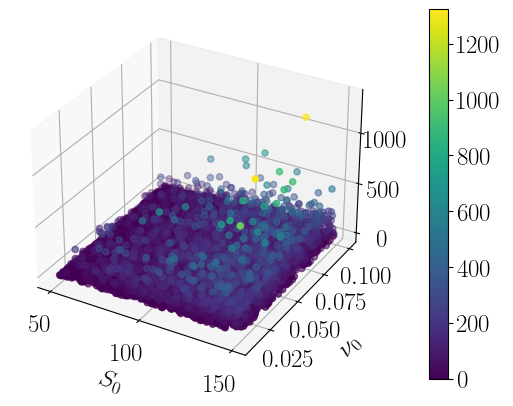

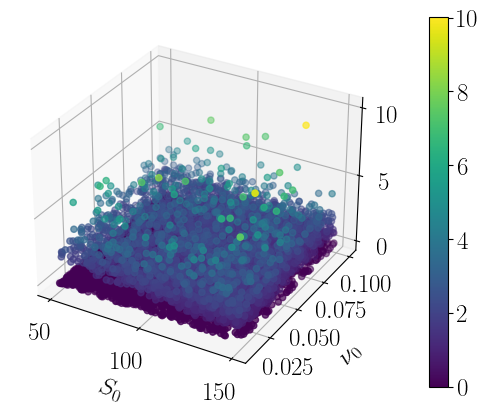

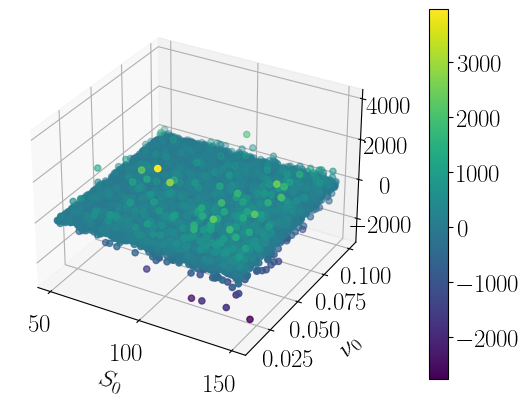

In [99]:
fig_payoff = plot_3d_differential_data(initial_spots, initial_vols, ps, "pathwise payoff")
fig_dS = plot_3d_differential_data(initial_spots, initial_vols, dps.S0, "pathwise differential dpayoff dS0")
fig_dv = plot_3d_differential_data(initial_spots, initial_vols, dps.v0, "pathwise differential dpayoff dv0")

## TrainingSet generation

In [105]:
class HestonTrainingSet(eqx.Module):
    initial_states: Array
    payoffs: Array
    differentials: ModelState
    
    def as_flattened_dict(self):
        d = asdict(self)

        d["payoffs"] = jnp.ravel(d["payoffs"])
        d["initial_states"] = jnp.reshape(d["initial_states"], (-1, d["initial_states"].shape[-1]))
        d["differentials"] = jnp.stack(jax.tree_util.tree_flatten(jax.tree_util.tree_map(jnp.ravel, ds.differentials))[0], axis=1)
        return d

    def metadata(self, spot_range: Range, vol_range: Range):
        return {"spot_range": asdict(spot_range), "vol_range": asdict(vol_range), "n_samples": self.payoffs.size}

def training_set_precomputed(params: Heston.Parameters, *, key: PRNGKeyArray, spot_range: Range, vol_range: Range) -> HestonTrainingSet:

    def training_set_precomputed_inner(carry, key):
        n_inner_paths = 2**13 # 15
        # key, key_spots, key_vols = jrandom.split(key, 3)
        key, key_state = jrandom.split(key, 2)
        # initial_spots = jrandom.uniform(key_spots, shape=(n_inner_paths,), minval=spot_range.minval, maxval=spot_range.maxval)
        # initial_vols = jrandom.uniform(key_vols, shape=(n_inner_paths,), minval=vol_range.minval, maxval=vol_range.maxval)

        
        initial_states = jrandom.uniform(key_state, shape=(n_inner_paths, 2), minval=jnp.array([spot_range.minval, vol_range.minval]), maxval=jnp.array([spot_range.maxval, vol_range.maxval]))
        initial_spots = initial_states[:, 0]
        initial_vols = initial_states[:, 1]
        
        # initial_spots = jnp.ones(n_inner_paths) * 100.0
        # initial_vols = jnp.ones(n_inner_paths) * 0.09    
        
        hs = Heston.from_parameters(params, S0=initial_spots, v0=initial_vols)
        
        path_seeds = jrandom.split(key, n_inner_paths)
        ps, dps = eqx.filter_vmap(partial(differential_path, n_time_steps=1024))(hs, path_seeds)
        
        return carry, HestonTrainingSet(initial_states, ps, dps)
    
    # due to limited vram of gpu we need to split up the computation into outer and inner paths.
    n_outer_paths = 2**6
    key, subkey = jrandom.split(key)
    key_rngs = jrandom.split(subkey, n_outer_paths)
    carry, dataset = jax.lax.scan(training_set_precomputed_inner, None, key_rngs)
    return dataset

In [106]:
key = jrandom.PRNGKey(0)

spot_range = Range(50.0, 150.0)
vol_range = Range(0.01, 0.1)

hs_params = Heston.Parameters(
    K = 100.0,   
    r = 0.00,
    T = 1.0,
    rho = -0.3,
    kappa = 1.0,
    theta = 0.09,
    xi = 1.0,
)

ds = training_set_precomputed(params=hs_params, key=key, spot_range=spot_range, vol_range=vol_range)

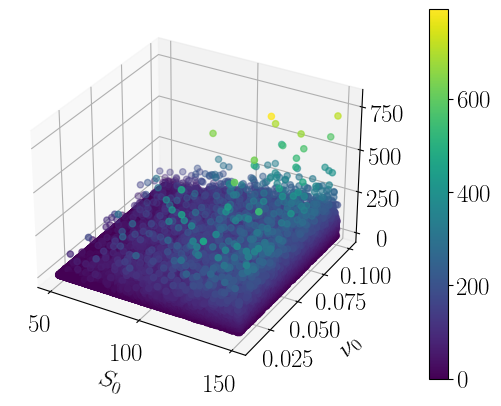

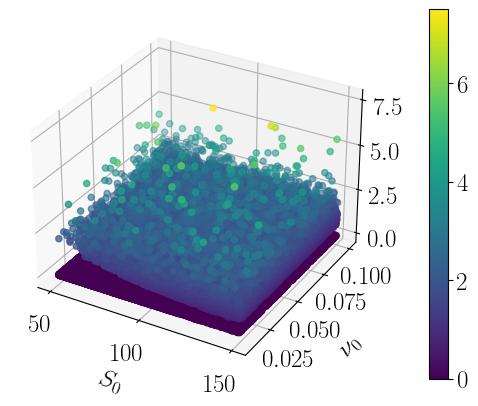

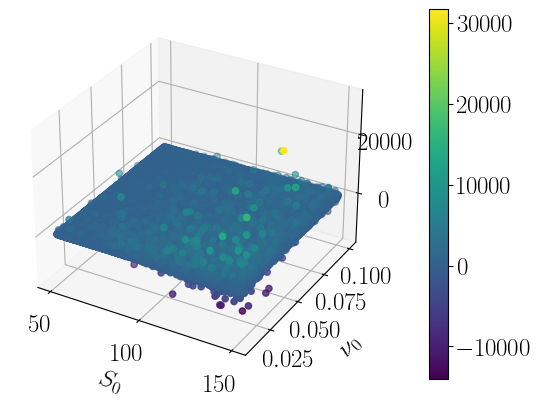

In [107]:
xs = ds.initial_states[..., 0]
ys = ds.initial_states[..., 1]

fig_payoff = plot_3d_differential_data(xs, ys, ds.payoffs, "pathwise payoff")
fig_dS = plot_3d_differential_data(xs, ys, ds.differentials.S0, "pathwise differential dpayoff dS0")
fig_dv = plot_3d_differential_data(xs, ys, ds.differentials.v0, "pathwise differential dpayoff dv0")

In [108]:
def uniform_mean(range):
    return (range.minval + range.maxval) / 2.0

def uniform_std(range):
    return jnp.sqrt((range.maxval - range.minval)**2 / 12)

# compute x mean and std dev. from uniform dist. properties
spot_mean = uniform_mean(spot_range)
print(spot_mean)
vol_mean = uniform_mean(vol_range)
print(vol_mean)
x_mean = jnp.stack((spot_mean, vol_mean))
print("mean computed: ", x_mean)

spot_std = uniform_std(spot_range)
print(spot_std)
vol_std = uniform_std(vol_range)
print(vol_std)

x_std = jnp.stack((spot_std, vol_std))
print("stddev computed: ", x_std)


100.0
0.055
mean computed:  [1.0e+02 5.5e-02]
28.867513459481287
0.025980762113533163
stddev computed:  [2.88675135e+01 2.59807621e-02]


In [109]:
def normalize(x, x_mean, x_std):
    return (x - x_mean) / x_std
    
def add_normalized_columns(ds):
    ds["normalized_initial_states"] = normalize(ds["initial_states"], x_mean, x_std) 
    
    payoffs = ds["payoffs"]
    ds["normalized_payoffs"] = normalize(payoffs, jnp.mean(payoffs), jnp.std(payoffs))
    return ds

In [110]:
def save_train_dataset(ds: HestonTrainingSet, spot_range: Range, vol_range: Range):
    train_data_dict = add_normalized_columns(ds.as_flattened_dict())
    
    citation = r"""@misc{dataset:heston,
        author = {Kichler, Neil},
        year = {2023},
        title = {{Heston Dataset}},
        howpublished= {\url{https://github.com/neilkichler/diff-ml/tree/main/datasets/bachelier}}
    """
    
    spot_minval = spot_range.minval
    spot_maxval = spot_range.maxval
    vol_minval = vol_range.minval
    vol_maxval = vol_range.maxval
    
    ds_info = DatasetInfo(
        description=f"Example data of a Heston model for a european call option. The generated data has initial spot range of: [{spot_minval}, {spot_maxval}] and volatility range of: [{vol_minval}, {vol_maxval}].",
        homepage="https://github.com/neilkichler/diff-ml/tree/main/datasets/heston",
        license="MIT License",
        citation=citation,
        version="1.1.0",
    )
    
    train_dataset = Dataset.from_dict(train_data_dict, info=ds_info, split="train")
    train_dataset = train_dataset.with_format("jax")
    save_folder = f"datasets/heston/arrow/payoffs/spot_{spot_minval}_to_{spot_maxval}_vol_{vol_minval}_to_{vol_maxval}"
    train_dataset.save_to_disk(save_folder)
    
    # save metadata
    
    import json
    
    ds_json = ds.metadata(spot_range, vol_range)
    
    with open(f"{save_folder}/metadata.json", 'w') as f:
        json.dump(ds_json, f)

    return save_folder

In [362]:
save_folder = save_train_dataset(ds, spot_range, vol_range)

Saving the dataset (0/1 shards):   0%|          | 0/524288 [00:00<?, ? examples/s]

In [363]:
train_dataset_loaded = load_from_disk(save_folder)
print(train_dataset_loaded)

ds_gen = train_dataset_loaded.iter(batch_size=512)
for d in ds_gen:
    jax.tree_util.tree_map(lambda x: print(x.shape), d)
    break

Dataset({
    features: ['initial_states', 'payoffs', 'differentials', 'normalized_initial_states', 'normalized_payoffs'],
    num_rows: 524288
})
(512, 2)
(512, 2)
(512, 2)
(512,)
(512,)


In [364]:
# Now the same but with larger vol range

key = jrandom.PRNGKey(0)

# TODO: should this be part of the HestonParams class?
spot_range = Range(50.0, 150.0)
vol_range = Range(0.01, 1.0)

hs_params = Heston.Parameters(
    K = 100.0,   
    r = 0.00,
    T = 1.0,
    rho = -0.3,
    kappa = 1.0,
    theta = 0.09,
    xi = 1.0,
)

ds = training_set_precomputed(params=hs_params, key=key, spot_range=spot_range, vol_range=vol_range)

In [365]:
save_train_dataset(ds, spot_range, vol_range)

Saving the dataset (0/1 shards):   0%|          | 0/524288 [00:00<?, ? examples/s]

'datasets/heston/arrow/payoffs/spot_50.0_to_150.0_vol_0.01_to_1.0'

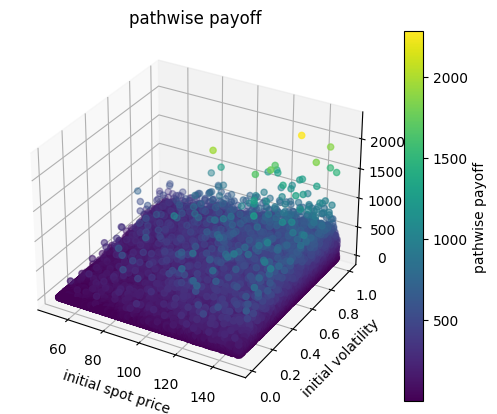

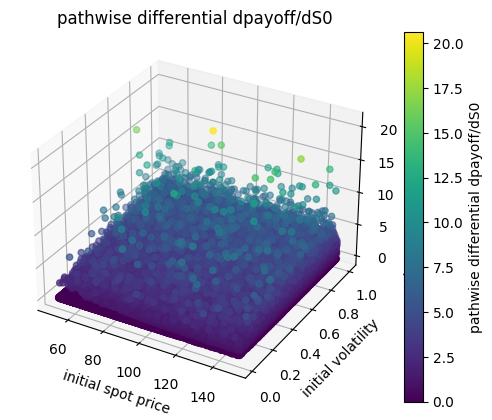

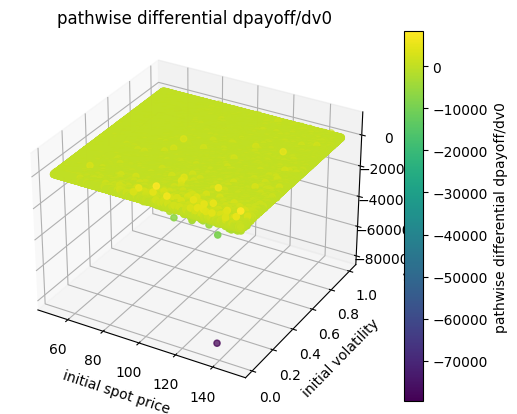

In [366]:
xs = ds.initial_states[..., 0]
ys = ds.initial_states[..., 1]

fig_payoff = plot_3d_differential_data(xs, ys, ds.payoffs, "pathwise payoff")
fig_dS = plot_3d_differential_data(xs, ys, ds.differentials.S0, "pathwise differential dpayoff/dS0")
fig_dv = plot_3d_differential_data(xs, ys, ds.differentials.v0, "pathwise differential dpayoff/dv0")

## TestSet generation, large volatility

In [ ]:
class HestonTestSet(eqx.Module):
    initial_states: Array
    prices: Array
    greeks: ModelState
    
    def as_flattened_dict(self):
        d = asdict(self)
        d["greeks"] = jnp.stack(self.greeks[-2:], axis=1)
        return d

    def metadata(self, spot_range: Range, vol_range: Range):
        return {"spot_range": asdict(spot_range), "vol_range": asdict(vol_range), "n_samples": self.prices.size}

@eqx.filter_jit
def test_set_precomputed(params: Heston.Parameters, *, key: PRNGKeyArray, spot_range: Range, vol_range: Range) -> HestonTestSet:

    minvals = jnp.array([spot_range.minval, vol_range.minval])
    maxvals = jnp.array([spot_range.maxval, vol_range.maxval])
    
    def test_set_precomputed_inner(carry, key):
        n_inner_paths = 2**13
        key, key_state = jrandom.split(key)

        # inisde the inner loop of the test set we always use the same initial state to determine the price afterwards.
        initial_states = jnp.ones((n_inner_paths, 2)) * jrandom.uniform(key_state, shape=(2,), minval=minvals, maxval=maxvals)
        initial_spots = initial_states[:, 0]
        initial_vols = initial_states[:, 1]
        
        # jax.debug.print("initial spots {}", initial_spots)
        
        hs = Heston.from_parameters(params, S0=initial_spots, v0=initial_vols)
        
        path_seeds = jrandom.split(key, n_inner_paths)
        ps, dps = eqx.filter_vmap(partial(differential_path, n_time_steps=1024))(hs, path_seeds)
        # jax.lax.cond(carry % 100, lambda x: jax.debug.print("finished price calcuation {}", x), lambda _: None, carry)
        jax.debug.print("finished price calcuation {}", carry)
        
        return carry + 1, HestonTestSet(initial_states, ps, dps)
    


    # due to limited vram of gpu we need to split up the computation into outer and inner paths.
    n_outer_paths = 2**10
    key, subkey = jrandom.split(key)
    key_rngs = jrandom.split(subkey, n_outer_paths)
    carry, ds = jax.lax.scan(test_set_precomputed_inner, 0, key_rngs)





    # jax.debug.print("ds payoffs {}", ds.payoffs.shape)
    # jax.debug.print("ds payoffs {}", ds.payoffs)

    def discounted_avg(x, h: Heston.Parameters):
        return jnp.mean(x, axis=1) * jnp.exp(-h.r * h.T) 
    
    test_set = HestonTestSet(*astuple(jax.tree_util.tree_map(partial(discounted_avg, h=hs_params), ds)))

    # jax.debug.print("test set {}", test_set)
    
    return test_set

In [390]:
key = jrandom.PRNGKey(0)

spot_range = Range(50.0, 150.0)
vol_range = Range(0.01, 10.0)

hs_params = Heston.Parameters(
    K = 100.0,   
    r = 0.00,
    T = 1.0,
    rho = -0.3,
    kappa = 1.0,
    theta = 0.09,
    xi = 1.0,
)

test_set_high_vol = test_set_precomputed(params=hs_params, key=key, spot_range=spot_range, vol_range=vol_range)

finished price calcuation 0
finished price calcuation 1
finished price calcuation 2
finished price calcuation 3
finished price calcuation 4
finished price calcuation 5
finished price calcuation 6
finished price calcuation 7
finished price calcuation 8
finished price calcuation 9
finished price calcuation 10
finished price calcuation 11
finished price calcuation 12
finished price calcuation 13
finished price calcuation 14
finished price calcuation 15
finished price calcuation 16
finished price calcuation 17
finished price calcuation 18
finished price calcuation 19
finished price calcuation 20
finished price calcuation 21
finished price calcuation 22
finished price calcuation 23
finished price calcuation 24
finished price calcuation 25
finished price calcuation 26
finished price calcuation 27
finished price calcuation 28
finished price calcuation 29
finished price calcuation 30
finished price calcuation 31
finished price calcuation 32
finished price calcuation 33
finished price calcuatio

In [115]:
import json

def save_test_dataset(ds: HestonTrainingSet, spot_range: Range, vol_range: Range, label = "prices"):
    data_dict = ds.as_flattened_dict()
    
    citation = r"""@misc{dataset:heston,
        author = {Kichler, Neil},
        year = {2023},
        title = {{Heston Prices Large Volatility Range Dataset}},
        howpublished= {\url{https://github.com/neilkichler/diff-ml/tree/main/datasets/bachelier}}
    """
    
    spot_minval = spot_range.minval
    spot_maxval = spot_range.maxval
    vol_minval = vol_range.minval
    vol_maxval = vol_range.maxval

    
    ds_info = DatasetInfo(
        description=f"MC-Sampled {label} of a Heston model for a european call option. The generated data has initial spot range of: [{spot_minval}, {spot_maxval}] and volatility range of: [{vol_minval}, {vol_maxval}].",
        homepage="https://github.com/neilkichler/diff-ml/tree/main/datasets/heston",
        license="MIT License",
        citation=citation,
        version="1.1.0",
    )
    
    train_dataset = Dataset.from_dict(data_dict, info=ds_info, split="test")
    train_dataset = train_dataset.with_format("jax")
    save_folder = f"datasets/heston/arrow/{label}/spot_{spot_minval}_to_{spot_maxval}_vol_{vol_minval}_to_{vol_maxval}"
    train_dataset.save_to_disk(save_folder)
    
    # save metadata in separate metadata.json file
    ds_json = ds.metadata(spot_range, vol_range)
    
    with open(f"{save_folder}/metadata.json", 'w') as f:
        json.dump(ds_json, f)

    return save_folder

In [392]:
fpath = save_test_dataset(test_set_high_vol, spot_range, vol_range, label="prices")

Saving the dataset (0/1 shards):   0%|          | 0/1024 [00:00<?, ? examples/s]

In [393]:
test_set_high_vol = load_from_disk(fpath)

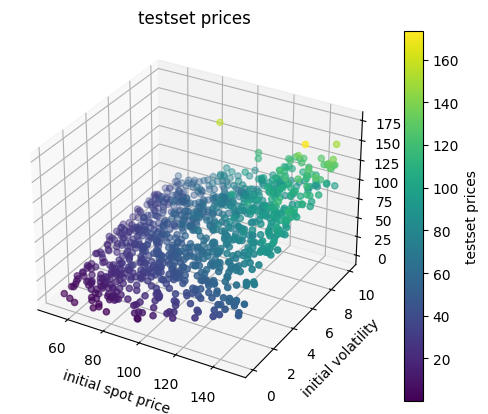

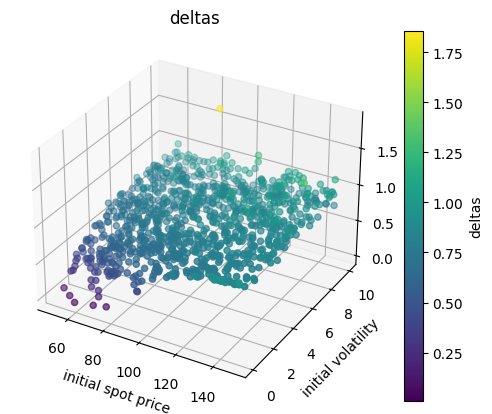

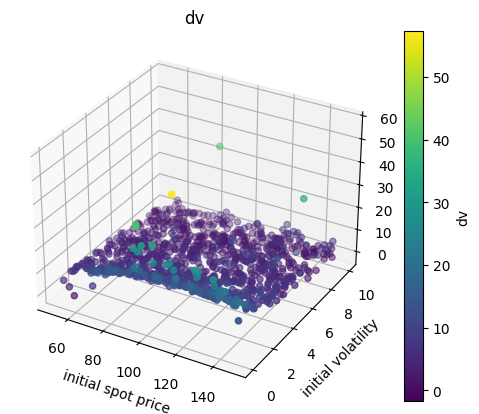

In [394]:
xs = test_set_high_vol["initial_states"]
ys = test_set_high_vol["prices"]
greeks = test_set_high_vol["greeks"]
fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys, "testset prices")
fig_dS = plot_3d_differential_data(xs[:, 0], xs[:, 1], greeks[:, 0], "deltas")
fig_dS = plot_3d_differential_data(xs[:, 0], xs[:, 1], greeks[:, 1], "dv")

## TestSet generation, small volatility

In [113]:
key = jrandom.PRNGKey(0)

spot_range = Range(50.0, 150.0)
vol_range = Range(0.01, 0.1)

hs_params = Heston.Parameters(
    K = 100.0,   
    r = 0.00,
    T = 1.0,
    rho = -0.3,
    kappa = 1.0,
    theta = 0.09,
    xi = 1.0,
)

test_set_low_vol = test_set_precomputed(params=hs_params, key=key, spot_range=spot_range, vol_range=vol_range)


finished price calcuation 0
finished price calcuation 1
finished price calcuation 2
finished price calcuation 3
finished price calcuation 4
finished price calcuation 5
finished price calcuation 6
finished price calcuation 7
finished price calcuation 8
finished price calcuation 9
finished price calcuation 10
finished price calcuation 11
finished price calcuation 12
finished price calcuation 13
finished price calcuation 14
finished price calcuation 15
finished price calcuation 16
finished price calcuation 17
finished price calcuation 18
finished price calcuation 19
finished price calcuation 20
finished price calcuation 21
finished price calcuation 22
finished price calcuation 23
finished price calcuation 24
finished price calcuation 25
finished price calcuation 26
finished price calcuation 27
finished price calcuation 28
finished price calcuation 29
finished price calcuation 30
finished price calcuation 31
finished price calcuation 32
finished price calcuation 33
finished price calcuatio

In [116]:
fpath = save_test_dataset(test_set_low_vol, spot_range, vol_range, label="prices")

Saving the dataset (0/1 shards):   0%|          | 0/1024 [00:00<?, ? examples/s]

In [117]:
test_set_low_vol = load_from_disk(fpath)

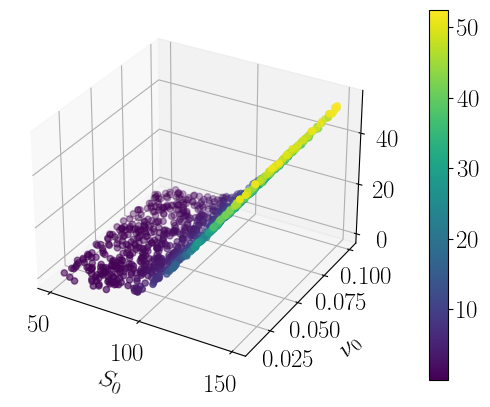

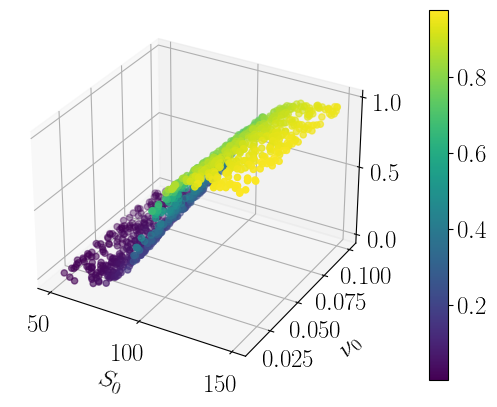

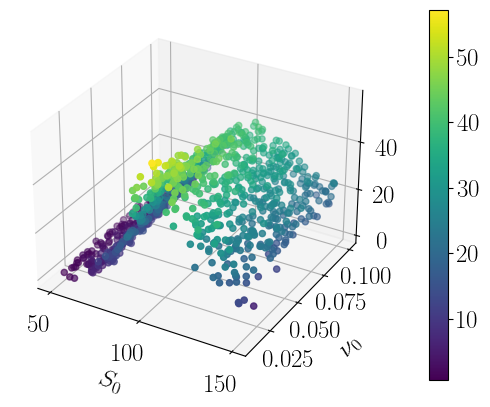

In [118]:
xs = test_set_low_vol["initial_states"]
ys = test_set_low_vol["prices"]
greeks = test_set_low_vol["greeks"]
fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys, "testset prices")
fig_dS = plot_3d_differential_data(xs[:, 0], xs[:, 1], greeks[:, 0], "testset deltas")
fig_dS = plot_3d_differential_data(xs[:, 0], xs[:, 1], greeks[:, 1], "testset vegas")

## Example price scenario (from pathwise samples)

In [404]:
key = jrandom.PRNGKey(0)

spot_range = Range(100.0, 100.0)
vol_range = Range(0.09, 0.09)

hs_params = Heston.Parameters(
    K = 100.0,   
    r = 0.00,
    T = 1.0,
    rho = -0.3,
    kappa = 1.0,
    theta = 0.09,
    xi = 1.0,
)

example_scenario = test_set_precomputed(params=hs_params, key=key, spot_range=spot_range, vol_range=vol_range)


finished price calcuation 0
finished price calcuation 1
finished price calcuation 2
finished price calcuation 3
finished price calcuation 4
finished price calcuation 5
finished price calcuation 6
finished price calcuation 7
finished price calcuation 8
finished price calcuation 9
finished price calcuation 10
finished price calcuation 11
finished price calcuation 12
finished price calcuation 13
finished price calcuation 14
finished price calcuation 15
finished price calcuation 16
finished price calcuation 17
finished price calcuation 18
finished price calcuation 19
finished price calcuation 20
finished price calcuation 21
finished price calcuation 22
finished price calcuation 23
finished price calcuation 24
finished price calcuation 25
finished price calcuation 26
finished price calcuation 27
finished price calcuation 28
finished price calcuation 29
finished price calcuation 30
finished price calcuation 31
finished price calcuation 32
finished price calcuation 33
finished price calcuatio

In [406]:
jax.tree_util.tree_map(jnp.mean, example_scenario.greeks)

(None,
 None,
 None,
 None,
 None,
 None,
 None,
 Array(0.60778374, dtype=float64),
 Array(39.33239533, dtype=float64))

# Load Dataset for training

In [119]:
import json

In [120]:
def load_dataset(fpath):
    ds = load_from_disk(fpath)
    ds = ds.with_format("jax")

    with open(f"{fpath}/metadata.json", "r") as f:
        metadata = json.load(f)
    return ds, metadata

In [121]:
train_dataset, meta_train = load_dataset("datasets/heston/arrow/payoffs/spot_50.0_to_150.0_vol_0.01_to_0.1")
test_dataset, meta_test = load_dataset("datasets/heston/arrow/prices/spot_50.0_to_150.0_vol_0.01_to_0.1")


In [122]:
jnp.max(train_dataset["initial_states"][:, 1])

Array(0.0999999, dtype=float32)

## Test dataset visualization

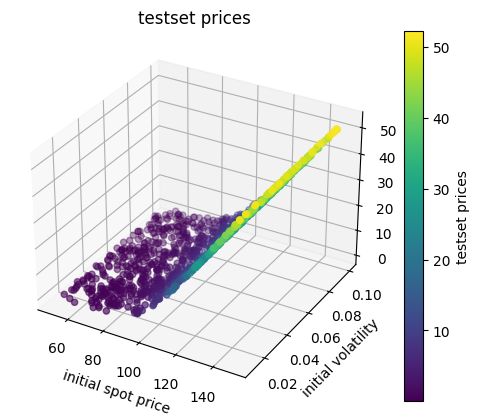

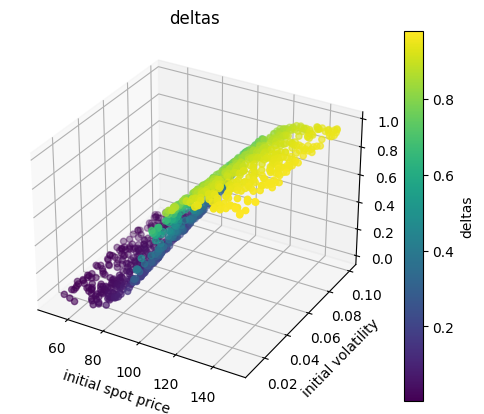

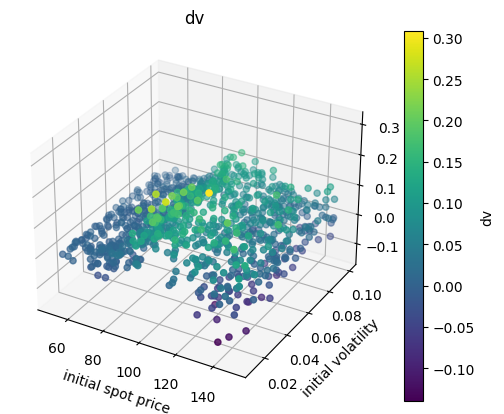

In [26]:
xs = test_dataset["initial_states"]
xs, ys = xs[:, 0], xs[:, 1]
zs = test_dataset["prices"]
greeks = test_dataset["greeks"]
fig_payoff = plot_3d_differential_data(xs, ys, zs, "testset prices")
fig_dS = plot_3d_differential_data(xs, ys, greeks[:, 0], "deltas")
fig_dS = plot_3d_differential_data(xs, ys, greeks[:, 1], "dv")

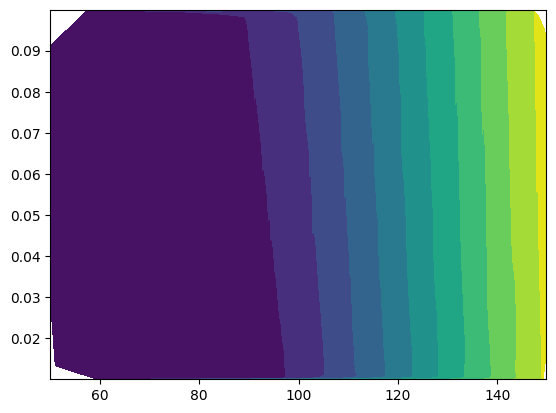

In [27]:
plt.tricontourf(xs, ys, zs, levels = 10)
plt.show()

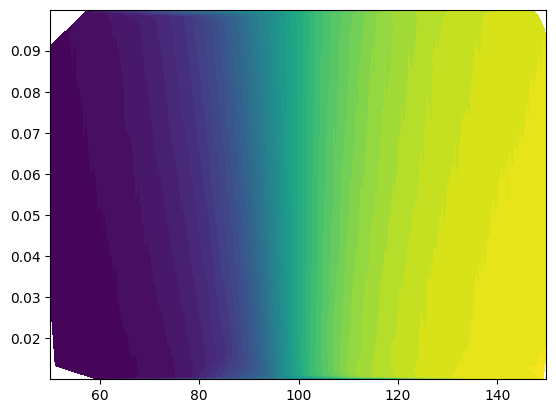

In [28]:
plt.tricontourf(xs, ys, greeks[:, 0], levels=40)
plt.show()

0


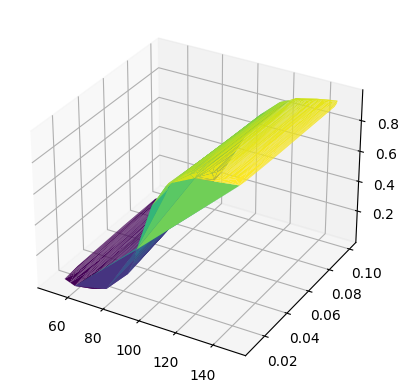

In [29]:
import matplotlib.tri as mtri

# Make parameter spaces radii and angles.
n_angles = 36
n_radii = 8
min_radius = 0.25
radii = np.linspace(min_radius, 0.95, n_radii)

angles = np.linspace(0, 2*np.pi, n_angles, endpoint=False)
angles = np.repeat(angles[..., np.newaxis], n_radii, axis=1)
angles[:, 1::2] += np.pi/n_angles


x = xs
y = ys

triang = mtri.Triangulation(x, y)

# Mask off unwanted triangles.
xmid = x[triang.triangles].mean(axis=1)
ymid = y[triang.triangles].mean(axis=1)
mask = (xmid**2 + ymid**2) < min_radius**2

print(np.sum(mask))
triang.set_mask(mask)

z = greeks[:, 0]

# Plot the surface.
# ax = fig.add_subplot(1, 2, 2, projection='3d')
# ax = fig.add_subplot(1, 2, 2, projection='3d')
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(triang, z, cmap=plt.cm.viridis) #CMRmap)


plt.show()

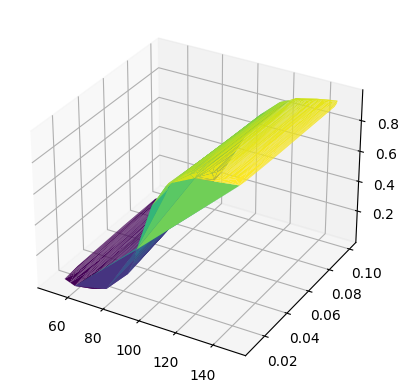

In [30]:

x = xs
y = ys

tri = mtri.Triangulation(x, y)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(x, y, z, triangles=tri.triangles, cmap=plt.cm.viridis) #, cmap=plt.cm.Spectral)



# Standard ML

In [123]:
Model = Callable[[Array, Optional[PRNGKeyArray]], Array]


class Normalization(eqx.Module):
    """Preprocessing layer to receive normalized input.

    Similar to `Normalization` layer of Keras.
    """

    mean: Float[Array, ""]
    std: Float[Array, ""]

    def __call__(self, x: Array, *, key: Optional[PRNGKeyArray] = None) -> Array:
        res = (x - self.mean) / self.std
        # jax.debug.print("normalized x is: {}", res)
        return res

class Denormalization(eqx.Module):
    """Preprocessing layer to denormalize data to original scale."""

    mean: Float[Array, ""]
    std: Float[Array, ""]

    def __call__(self, x: Array, *, key: Optional[PRNGKeyArray] = None) -> Array:
        res = x * self.std + self.mean
        # jax.debug.print("normalized y was: {}", x)
        # jax.debug.print("denormalized y is: {}", res)
        return res

class Normalized(eqx.Module):
    seq: eqx.nn.Sequential

    def __init__(
        self,
        x_normalizer: Normalization,
        model: eqx.Module,
        y_denormalizer: Denormalization,
    ):
        self.seq = eqx.nn.Sequential(layers=(x_normalizer, model, y_denormalizer))

    def __call__(self, x: Array, *, key: Optional[PRNGKeyArray] = None) -> Array:
        return self.seq(x, key=key)

In [124]:
def trunc_init(weight: Array, key: jax.random.PRNGKey) -> Array:
  out, in_ = weight.shape
  stddev = jnp.sqrt(1 / in_)
  return jax.nn.initializers.glorot_normal()(key, (out, in_))

def init_linear_weight(model, init_fn, key):
  is_linear = lambda x: isinstance(x, eqx.nn.Linear)
  get_weights = lambda m: [x.weight
                           for x in jax.tree_util.tree_leaves(m, is_leaf=is_linear)
                           if is_linear(x)]
  weights = get_weights(model)
  new_weights = [init_fn(weight, subkey)
                 for weight, subkey in zip(weights, jax.random.split(key, len(weights)))]
  new_model = eqx.tree_at(get_weights, model, new_weights)
  return new_model

In [125]:
using_normalized_dataset=True
if using_normalized_dataset:
    key = jrandom.PRNGKey(0)
    key, subkey = jrandom.split(key)
    
    class Range(eqx.Module):
        minval: float = 0.0
        maxval: float = 1.0
    # this info should perhaps be stored inside the dataset?
    spot_range = Range(50.0, 150.0)
    vol_range = Range(0.01, 0.1)
    
    
    ds = train_dataset
    
    
    def uniform_mean(range):
        return (range.minval + range.maxval) / 2.0
    
    def uniform_std(range):
        return jnp.sqrt((range.maxval - range.minval)**2 / 12)
    
    # compute x mean and std dev. from uniform dist. properties
    spot_mean = uniform_mean(spot_range)
    print(spot_mean)
    # print(jnp.mean(ds["initial_spots"]))
    
    vol_mean = uniform_mean(vol_range)
    print(vol_mean)
    # print(jnp.mean(ds["initial_vols"]))
    
    x_mean = jnp.stack((spot_mean, vol_mean))#[:, jnp.newaxis]
    print("mean computed: ", x_mean)
    print("mean data: ", jnp.mean(ds["initial_states"], axis=0))
    
    spot_std = uniform_std(spot_range)
    print(spot_std)
    
    print(vol_range)
    vol_std = uniform_std(vol_range)
    print(vol_std)
    
    x_std = jnp.stack((spot_std, vol_std))#[:, jnp.newaxis]
    print("stddev computed: ", x_std)
    print("stddev data: ", jnp.std(ds["initial_states"], axis=0))
    
    # compute y mean and std. dev. from data
    y_mean = jnp.mean(ds["payoffs"])
    y_std = jnp.std(ds["payoffs"])
    
    # ds["payoffs"] = (ds["payoffs"] - y_mean) / y_std
    
    # def normalize_payoffs(example):
    #     example["payoffs"] = (example["payoffs"] - y_mean) / y_std
    
    # ds = ds.map(normalize_payoffs, batched=True)
    # print(ds)
    # print(jnp.mean(ds["payoffs"]))
    # print(jnp.max(ds["payoffs"]))
    
    # print(type(ds["payoffs"]))
    # ds["payoffs"] = ds["payoffs"] * 2.0 
    # ds.add_column("payoff_normalized", (ds["payoffs"] - y_mean) / y_std)
    
    # surrogate model initialization
    # x_normalizer = Normalization(mean=x_mean, std=x_std)
    # y_denormalizer = Denormalization(mean=y_mean, std=y_std)
    # surrogate_model = Normalized(x_normalizer, mlp, y_denormalizer)

100.0
0.055
mean computed:  [1.0e+02 5.5e-02]
mean data:  [9.9986588e+01 5.4999344e-02]
28.867513459481287
Range(minval=0.01, maxval=0.1)
0.025980762113533163
stddev computed:  [2.88675135e+01 2.59807621e-02]
stddev data:  [2.8887899e+01 2.5966838e-02]


In [126]:
jnp.allclose(ds["payoffs"], ds["normalized_payoffs"] * y_std + y_mean, atol=1e-3)

Array(True, dtype=bool)

In [127]:
train_ds = train_dataset
# train_ds = train_ds[:16 * 1024]

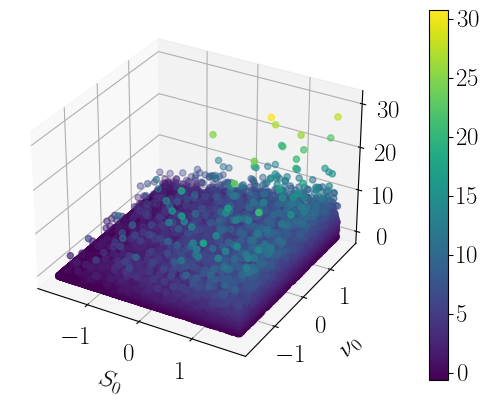

In [128]:
n_samples = 2**20
xs = train_ds["normalized_initial_states"][:n_samples]
ys = train_ds["normalized_payoffs"][:n_samples]
fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys, "normalized pathwise payoff")


In [130]:
from itertools import islice

Data: TypeAlias = dict[str, Float[Array, "n_samples ..."]]
DataGenerator: TypeAlias = Generator[Data, None, None]

def loss_fn(
    model, x, y
):
    pred_y = vmap(model)(x)
    # jax.debug.print("pred_y is {}", pred_y)
    # jax.debug.print("true_y is {}", y)
    # jax.debug.print("y: {}", y.shape)
    # jax.debug.print("pred_y: {}", (y-pred_y).shape)
    # jax.debug.print("y - pred_y: {}", jnp.mean((y-pred_y)**2))
    return mse(y, pred_y)


def train(
    model: PyTree,
    train_data: DataGenerator,
    test_data: Optional[Data],
    optim: optax.GradientTransformation,
    n_epochs: int,
) -> PyTree:
    @eqx.filter_jit
    def train_step(model: PyTree, opt_state: PyTree, batch: Data):

        if using_tf_style:
            x, y = batch
        else:
            x = batch["normalized_initial_states"]
            y = batch["normalized_payoffs"]
        
        loss_value, grads = eqx.filter_value_and_grad(loss_fn)(model, x, y)
        updates, opt_state = optim.update(grads, opt_state, model)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss_value

    opt_state = optim.init(eqx.filter(model, eqx.is_array))
    train_loss = jnp.zeros(1)

    n_steps_per_epoch = 64
    n_steps = n_epochs * n_steps_per_epoch
    print(n_steps)

    if not using_tf_style:
        for i, batch in zip(range(n_steps), train_data):
            # print(i)
            # print(batch["normalized_initial_states"])
            # print(batch["normalized_payoffs"].shape)
            with jax.profiler.StepTraceAnnotation("Train Step", step_num=i):  

                model, opt_state, train_loss = train_step(model, opt_state, batch)
            
            if i % n_steps_per_epoch == 0 or i == n_steps-1:
                epoch_stats = f"Finished step {i} | Train Loss: {train_loss:.5f}"    
                print(epoch_stats)
        # def train_inner(model, opt_state, train_loss):
        #     batch = next(train_data)
        #     model, opt_state, train_loss = train_step(model, opt_state, batch)
    
        #     if i % n_steps_per_epoch == 0:
        #         epoch_stats = f"Finished epoch {i:3d} | Train Loss: {train_loss:.5f}"    
        #         print(epoch_stats)
    
        #     return model, opt_state, train_loss
        
        # model = jax.lax.fori_loop(0, n_steps, train_inner, (model, opt_state, train_loss))
    else: 
        for epoch in range(n_epochs):
            for batch in train_data:
                model, opt_state, train_loss = train_step(model, opt_state, batch)
                # print(f"batch {i} finished")
                
            epoch_stats = f"Finished epoch {epoch:3d} | Train Loss: {train_loss:.5f}"
    
            if test_data:
                test_loss = jnp.sqrt(loss_fn(model, test_data["spot"], test_data["payoff"]))
                print(f"{epoch_stats} | Test Loss: {test_loss:.5f}")
            else:
                print(epoch_stats)

    return model

## TF specific

In [66]:
#tf_ds = ds.with_format("tf")

In [196]:
tf_ds

Dataset({
    features: ['initial_states', 'payoffs', 'differentials', 'normalized_initial_states', 'normalized_payoffs'],
    num_rows: 2097152
})

In [318]:
BATCH_SIZE = 512

tf_train_dataset = tf.data.Dataset.from_tensor_slices((ds["normalized_initial_states"], ds["normalized_payoffs"]))

tf_train_dataset = tf_train_dataset.shuffle(1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
# tf_test_dataset = tf_test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

tf_generator_train_ds = tfds.as_numpy(tf_train_dataset)
# generator_test_ds = tfds.as_numpy(test_dataset)

In [37]:
tf_train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 2), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>

In [55]:
len(ds["payoffs"])

2097152

## Training

In [132]:
key = jrandom.PRNGKey(0)
key, subkey = jrandom.split(key)

# in_size is 2 for initial_spot and initial_vol
n_dims = 2
mlp = eqx.nn.MLP(key=subkey, in_size=n_dims, out_size="scalar", width_size=20, depth=3, activation=jax.nn.elu)

key, subkey = jax.random.split(key)
mlp = init_linear_weight(mlp, trunc_init, key)
surrogate_model = mlp

In [133]:
def generator_train_data(train_dataset, batch_size: int):
    train_ds_temp = train_dataset.with_format(None)
    train_ds_iter = train_ds_temp.to_iterable_dataset(num_shards=128)
    train_ds_iter = train_ds_iter.with_format("numpy")
    
    while True:
        for el in train_ds_iter.iter(batch_size=batch_size):
            yield el
        train_ds_iter = train_ds_iter.shuffle(buffer_size=10_000)
        

In [134]:
n_epochs = 100
BATCH_SIZE = 256

if using_tf_style:
    generator_train_ds = tf_generator_train_ds
else:
    # generator_train_ds = train_dataset.iter(batch_size=BATCH_SIZE)
    generator_train_ds = generator_train_data(train_dataset, batch_size=BATCH_SIZE)

generator_test_ds = None
# total_steps = n_epochs * (len(ds["payoffs"]) // BATCH_SIZE) + n_epochs

# total_steps = 64 * n_epochs
# lr_schedule = optax.exponential_decay(init_value=0.01, transition_steps=total_steps, transition_begin=int(total_steps*0.2), decay_rate=0.9)
# optim = optax.adam(learning_rate=lr_schedule)
optim = optax.adam(learning_rate=3e-4)


# for batch in generator_train_ds:
#     x = jnp.stack((batch["initial_spots"], batch["initial_vols"]))
#     y = batch["payoffs"]
#     print(x.shape)
#     print(y.shape)
#     print(type(batch["normalized_initial_states"]))
    # break

#with jax.profiler.trace(f"{current_path}/tmp/jax-trace", create_perfetto_trace=True):
surrogate_model = train(surrogate_model, generator_train_ds, generator_test_ds, optim, n_epochs=n_epochs)


6400
Finished step 0 | Train Loss: 1.68638
Finished step 64 | Train Loss: 0.66923
Finished step 128 | Train Loss: 0.57408
Finished step 192 | Train Loss: 0.55886
Finished step 256 | Train Loss: 0.57121
Finished step 320 | Train Loss: 0.53718
Finished step 384 | Train Loss: 0.54809
Finished step 448 | Train Loss: 1.08101
Finished step 512 | Train Loss: 0.43597
Finished step 576 | Train Loss: 0.40648
Finished step 640 | Train Loss: 0.59829
Finished step 704 | Train Loss: 1.08417
Finished step 768 | Train Loss: 0.49147
Finished step 832 | Train Loss: 2.10014
Finished step 896 | Train Loss: 0.36231
Finished step 960 | Train Loss: 0.40242
Finished step 1024 | Train Loss: 0.45643
Finished step 1088 | Train Loss: 0.56208
Finished step 1152 | Train Loss: 0.44798
Finished step 1216 | Train Loss: 0.42258
Finished step 1280 | Train Loss: 0.49718
Finished step 1344 | Train Loss: 0.48890
Finished step 1408 | Train Loss: 0.45883
Finished step 1472 | Train Loss: 0.61288
Finished step 1536 | Train Los

In [135]:
train_dataset

Dataset({
    features: ['initial_states', 'payoffs', 'differentials', 'normalized_initial_states', 'normalized_payoffs'],
    num_rows: 524288
})

In [138]:
# mse(pred_y, ds["normalized_payoffs"])
# on the test data
test_normalized_xs = test_dataset["initial_states"]
test_normalized_xs = (test_normalized_xs - x_mean) / x_std
test_normalized_ys = test_dataset["prices"]
test_normalized_ys = (test_normalized_ys - y_mean) / y_std

In [140]:
# eval price predictions
test_normalized_pred_ys, test_normalized_pred_dys = vmap(jax.value_and_grad(surrogate_model))(test_normalized_xs)
jnp.sqrt(mse(test_normalized_pred_ys, test_normalized_ys))

Array(0.03086082, dtype=float64)

In [172]:
test_normalized_dys = (test_dataset["greeks"] / payoffs_std) * state_std

In [173]:
# eval greek predictions
print(jnp.sqrt(mse(test_normalized_pred_dys[:, 0], test_normalized_dys[:, 0])))
print(jnp.sqrt(mse(test_normalized_pred_dys[:, 1], test_normalized_dys[:, 1])))

0.05810713
0.019133741


In [174]:
pred_values, pred_derivs = jax.value_and_grad(surrogate_model)((jnp.array([100.0, 0.09]) - x_mean) / x_std)
print(pred_values * y_std + y_mean)

# unscaled predicted derivs
(payoffs_std / state_std) *  pred_derivs

10.938490506532471


Array([ 0.60911888, 53.19734228], dtype=float64)

In [175]:
test_normalized_pred_ys

Array([-0.60384556, -0.28500801,  1.17470767, ..., -0.56606767,
       -0.12903682,  0.0943439 ], dtype=float64)

In [176]:
test_normalized_ys

Array([-0.60217786, -0.32865795,  1.1225053 , ..., -0.5654277 ,
       -0.12712727,  0.04454126], dtype=float32)

In [177]:
def error_hist(pred_y, true_y, buckets=30):
    plt.hist(jnp.abs(pred_y - true_y), buckets)
    plt.xlabel("absolute error")
    plt.ylabel("count")
    plt.show()

In [178]:
errors = jnp.abs(test_normalized_pred_ys - test_normalized_ys)
errors

Array([0.0016677 , 0.04364994, 0.05220237, ..., 0.00063995, 0.00190955,
       0.04980264], dtype=float64)

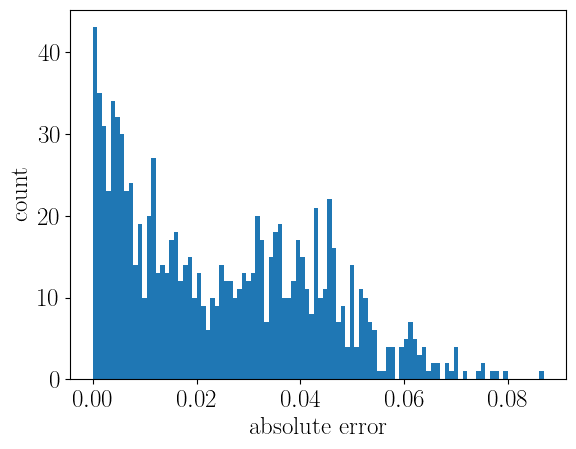

In [179]:
error_hist(test_normalized_pred_ys, test_normalized_ys, 100)

In [182]:
# example price prediction
res = surrogate_model((jnp.array([100.0, 0.09]) - x_mean) / x_std)
print(res * y_std + y_mean)

10.938490506532471


In [181]:
res = surrogate_model((test_dataset["initial_states"][2] - x_mean) / x_std)
print(res * y_std + y_mean)
print("vs true: ", test_dataset["prices"][2])

45.03315221852962
vs true:  43.71714


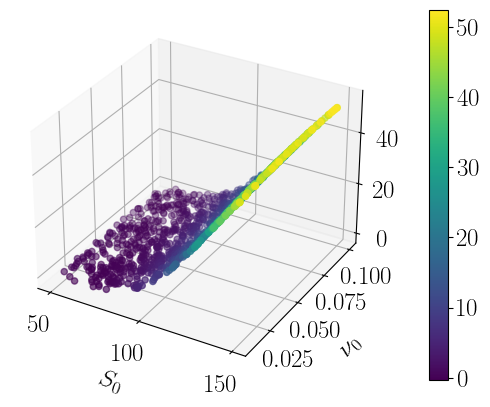

In [183]:
xs = test_dataset["initial_states"]
ys = test_normalized_pred_ys * y_std + y_mean
fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys, "predicted test set prices")

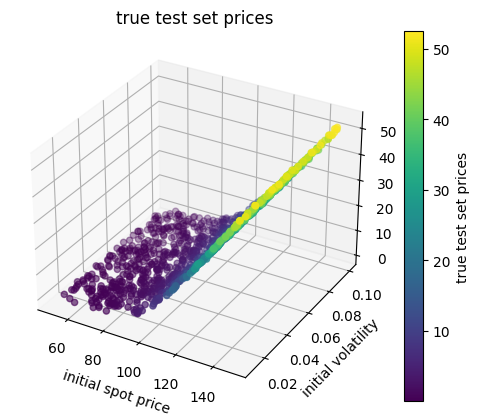

In [504]:
xs = test_dataset["initial_states"]
ys =  test_dataset["prices"]
fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys, "true test set prices")

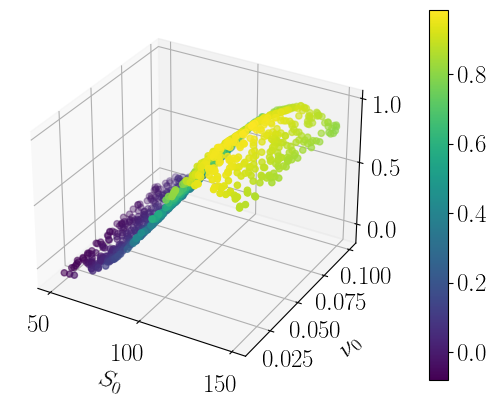

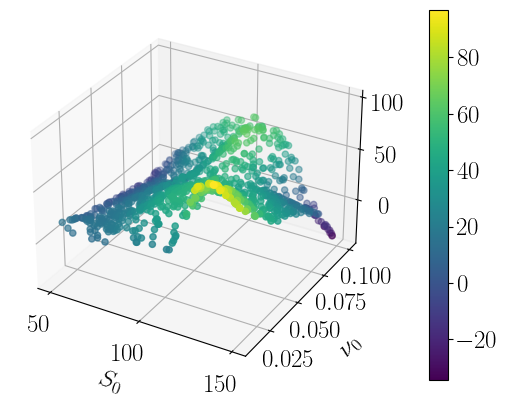

In [184]:
xs = test_dataset["initial_states"]
ys = test_normalized_pred_dys / state_std * payoffs_std

fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys[:, 0], "predicted greeks dS")
fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys[:, 1], "predicted greeks dV")

# Differential ML

## Normalization preamble

In [185]:
diff_mean = jnp.mean(train_dataset["differentials"], axis=0)

In [144]:
diff_std = jnp.std(train_dataset["differentials"], axis=0)

In [145]:
diff_normalized = (train_dataset["differentials"] - diff_mean) / diff_std

In [146]:
jnp.mean(diff_normalized, axis=0)

Array([1.7986167e-08, 3.9290171e-09], dtype=float32)

In [147]:
jnp.std(diff_normalized, axis=0)

Array([0.99999994, 1.        ], dtype=float32)

In [148]:
state_mean = jnp.mean(train_dataset["initial_states"], axis=0)
state_std = jnp.std(train_dataset["initial_states"], axis=0)

state_norm = (train_dataset["initial_states"] - state_mean) / state_std

In [149]:
payoffs_std = jnp.std(train_dataset["payoffs"])
payoffs_std

Array(25.20982, dtype=float32)

In [150]:
(train_dataset["payoffs"] - jnp.mean(train_dataset["payoffs"])) / jnp.std(train_dataset["payoffs"])

Array([ 0.3409949 ,  0.22870165,  1.4910403 , ..., -0.61161864,
        0.32728377, -0.61161864], dtype=float32)

In [151]:
state_norm

Array([[ 0.85959107, -0.6171522 ],
       [ 1.61891   , -1.2308143 ],
       [ 1.5818573 ,  0.91418684],
       ...,
       [-0.06279086, -0.38330862],
       [ 1.598922  , -0.1265819 ],
       [-1.5195249 ,  0.09190781]], dtype=float32)

In [152]:
state_std

Array([2.8887899e+01, 2.5966838e-02], dtype=float32)

In [153]:
1/12 * (0.1 - 0.01)**2

0.000675

In [154]:
x_std

Array([2.88675135e+01, 2.59807621e-02], dtype=float64, weak_type=True)

In [155]:
normalized_differentials = (train_dataset["differentials"] / payoffs_std) * state_std

In [156]:
normalized_differentials

Array([[ 1.1385269 ,  0.06271742],
       [ 0.94624776, -0.23248395],
       [ 1.2035125 , -0.01318837],
       ...,
       [ 0.        ,  0.        ],
       [ 0.9694677 , -0.08135345],
       [ 0.        ,  0.        ]], dtype=float32)

In [157]:
print(jnp.mean(test_dataset["greeks"], axis=0))
print(jnp.std(test_dataset["greeks"], axis=0))

[ 0.5019066 24.210999 ]
[ 0.37473825 13.558125  ]


In [158]:
print(jnp.mean(normalized_differentials, axis=0))
print(jnp.std(normalized_differentials, axis=0))

[0.5922537 0.0253311]
[0.6571097  0.30063263]


In [159]:
train_dataset["differentials"][0] * state_std / payoffs_std

Array([1.1385269 , 0.06271742], dtype=float32)

In [160]:
state_std[1]

Array(0.02596684, dtype=float32)

In [161]:
state_std

Array([2.8887899e+01, 2.5966838e-02], dtype=float32)

In [162]:
lambda_j = 1.0 / jnp.sqrt(jnp.mean(normalized_differentials**2, axis=0))

In [163]:
lambda_j

Array([1.1304252, 3.3145735], dtype=float32)

In [164]:
lambda_j * jnp.mean(normalized_differentials, axis=0) 

Array([0.6694985 , 0.08396178], dtype=float32)

In [165]:
payoffs_std

Array(25.20982, dtype=float32)

In [166]:
print(state_std)

[2.8887899e+01 2.5966838e-02]


In [167]:
payoffs_std * state_std

Array([7.2825873e+02, 6.5461934e-01], dtype=float32)

In [168]:
jnp.mean(train_dataset["differentials"], axis=0)

Array([ 0.5168465, 24.592613 ], dtype=float32)

In [169]:
normalized_differentials = (train_dataset["differentials"] / payoffs_std) * state_std

In [170]:
lambda_j = 1.0 / jnp.sqrt(jnp.mean(normalized_differentials**2, axis=0))
lambda_j

Array([1.1304252, 3.3145735], dtype=float32)

In [171]:
normalized_differentials = (train_dataset["differentials"] / y_std) * x_std
lambda_j = 1.0 / jnp.sqrt(jnp.mean(normalized_differentials**2, axis=0))
lambda_j

Array([1.1312236, 3.3127973], dtype=float32)

## Model description

In [188]:
@eqx.filter_jit
def diff_loss_fn(model: eqx.nn.MLP, x: Float[Array, "batch ..."], y: Float[Array, "batch ..."], dydx: Float[Array, "batch ..."]) -> Float:
    lam = 1
    n_dims = x.shape[1]
    lambda_scale = lam * n_dims
    alpha = 1.0/(1.0 + lambda_scale)
    beta = lambda_scale/(1.0 + lambda_scale)

    # alpha = 0.0
    # beta = 1.0 - alpha
    y_pred, dydx_pred = vmap(eqx.filter_value_and_grad(model))(x)

    # normalize dydx since the predictions are normalized. TODO: should happen somewhere else
    dydx_scaled = dydx / payoffs_std * state_std
    dydx_pred = dydx_pred
        
    assert(y_pred.shape == y.shape)
    assert(dydx_pred.shape == dydx_scaled.shape)
    
    dydx_pred =  dydx_pred * lambda_j
    dydx_scaled = dydx_scaled * lambda_j
    
    value_loss = jnp.mean((y_pred - y)**2)
    # jax.debug.print("value loss: {}", value_loss)
    grad_loss = jnp.mean((dydx_pred - dydx_scaled)**2)
    # jax.debug.print("dydx_pred: {}", dydx_pred)
    # jax.debug.print("dydx_true: {}", dydx_scaled)
    loss = alpha * value_loss + beta * grad_loss

    # jax.debug.print('[Internal] Value Loss {value_loss} | Grad Loss: {grad_loss}', value_loss=value_loss, grad_loss=grad_loss)
    return loss

In [190]:
from itertools import islice

Data: TypeAlias = dict[str, Float[Array, "n_samples ..."]]
DataGenerator: TypeAlias = Generator[Data, None, None]

def mse(y, pred_y):
    """Mean squared error loss."""
    return jnp.mean((y - pred_y) ** 2)


def loss_fn(
    model, x, y
):
    pred_y = vmap(model)(x)
    # jax.debug.print("pred_y is {}", pred_y)
    # jax.debug.print("true_y is {}", y)
    # jax.debug.print("y: {}", y.shape)
    # jax.debug.print("pred_y: {}", (y-pred_y).shape)
    # jax.debug.print("y - pred_y: {}", jnp.mean((y-pred_y)**2))
    return mse(y, pred_y)


using_tf_style = False

def train(
    model: PyTree,
    train_data: DataGenerator,
    test_data: Optional[Data],
    optim: optax.GradientTransformation,
    n_epochs: int,
) -> PyTree:
    @eqx.filter_jit
    def train_step(model: PyTree, opt_state: PyTree, batch: Data):

        if using_tf_style:
            x, y = batch
        else:
            x = batch["normalized_initial_states"]
            y = batch["normalized_payoffs"]
        
        loss_value, grads = eqx.filter_value_and_grad(loss_fn)(model, x, y)
        updates, opt_state = optim.update(grads, opt_state, model)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss_value

    opt_state = optim.init(eqx.filter(model, eqx.is_array))
    train_loss = jnp.zeros(1)

    n_steps_per_epoch = 256
    n_steps = n_epochs * n_steps_per_epoch

    if not using_tf_style:

        
        for i, batch in zip(range(n_steps), train_data):
            model, opt_state, train_loss = train_step(model, opt_state, batch)
    
            if i % n_steps_per_epoch == 0:
                epoch_stats = f"Finished epoch {i:3d} | Train Loss: {train_loss:.5f}"    
                print(epoch_stats)

        # def train_inner(model, opt_state, train_loss):
        #     batch = next(train_data)
        #     model, opt_state, train_loss = train_step(model, opt_state, batch)
    
        #     if i % n_steps_per_epoch == 0:
        #         epoch_stats = f"Finished epoch {i:3d} | Train Loss: {train_loss:.5f}"    
        #         print(epoch_stats)
    
        #     return model, opt_state, train_loss
        
        # model = jax.lax.fori_loop(0, n_steps, train_inner, (model, opt_state, train_loss))
    else: 
        for epoch in range(n_epochs):
            for batch in train_data:
                model, opt_state, train_loss = train_step(model, opt_state, batch)
                # print(f"batch {i} finished")
                
            epoch_stats = f"Finished epoch {epoch:3d} | Train Loss: {train_loss:.5f}"
    
            if test_data:
                test_loss = jnp.sqrt(loss_fn(model, test_data["spot"], test_data["payoff"]))
                print(f"{epoch_stats} | Test Loss: {test_loss:.5f}")
            else:
                print(epoch_stats)

    return model

In [258]:
def diff_train(model: eqx.nn.MLP,
          generator_train_ds,
          generator_test_ds,
          optim: optax.GradientTransformation,
          n_epochs: Int
          ) -> PyTree:
    
    @eqx.filter_jit
    def train_step(model: eqx.nn.MLP,
                   opt_state: PyTree,
                   x: Float[Array, "batch"],
                   y: Float[Array, "batch"],
                   dydx: Float[Array, "batch"]
                   ):
        loss_value, grads = eqx.filter_value_and_grad(diff_loss_fn)(model, x, y, dydx)
        updates, opt_state = optim.update(grads, opt_state)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss_value

    opt_state = optim.init(eqx.filter(model, eqx.is_array))

    for epoch in range(n_epochs):
        for batch in generator_train_ds:
            model, opt_state, train_loss = train_step(model, opt_state, batch_x, batch_y, batch_dydx)

        test_loss = rmse(vmap(model)(x_test), y_test)
        print('Finished epoch {:3d}'.format(epoch), 
                ' | Train Loss: {:.5f}'.format(train_loss),
                ' | Test Loss: {:.5f}'.format(test_loss))

    return model

In [191]:
Data: TypeAlias = dict[str, Float[Array, "n_samples ..."]]
DataGenerator: TypeAlias = Generator[Data, None, None]

def diff_train(
    model: PyTree,
    train_data: DataGenerator,
    test_data: Optional[Data],
    optim: optax.GradientTransformation,
    n_epochs: int,
) -> PyTree:
    @eqx.filter_jit
    def train_step(model: PyTree, opt_state: PyTree, batch: Data):

        x = batch["normalized_initial_states"]
        y = batch["normalized_payoffs"]
        dydx = batch["differentials"]
        
        loss_value, grads = eqx.filter_value_and_grad(diff_loss_fn)(model, x, y, dydx)
        updates, opt_state = optim.update(grads, opt_state, model)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss_value

    opt_state = optim.init(eqx.filter(model, eqx.is_array))
    train_loss = jnp.zeros(1)

    n_steps_per_epoch = 64
    n_steps = n_epochs * n_steps_per_epoch
    
    for i, batch in zip(range(n_steps), train_data):
        model, opt_state, train_loss = train_step(model, opt_state, batch)

        if i % n_steps_per_epoch == 0:
            epoch_stats = f"Finished epoch {i:3d} | Train Loss: {train_loss:.5f}"    
            print(epoch_stats)

    return model

## Train

In [194]:
key = jrandom.PRNGKey(0)
key, subkey = jrandom.split(key)

# in_size is 2 for initial_spot and initial_vol
n_dims = 2
mlp = eqx.nn.MLP(key=subkey, in_size=n_dims, out_size="scalar", width_size=20, depth=3, activation=jax.nn.elu)

key, subkey = jax.random.split(key)
mlp = init_linear_weight(mlp, trunc_init, key)
surrogate_model = mlp

In [195]:
n_epochs = 100
BATCH_SIZE = 256

if using_tf_style:
    generator_train_ds = tf_generator_train_ds
else:
    # generator_train_ds = train_dataset.iter(batch_size=BATCH_SIZE)
    generator_train_ds = generator_train_data(train_dataset, batch_size=BATCH_SIZE)

generator_test_ds = None
# total_steps = n_epochs * (len(ds["payoffs"]) // BATCH_SIZE) + n_epochs

# total_steps = 128 * n_epochs
# lr_schedule = optax.exponential_decay(init_value=0.01, transition_steps=total_steps, transition_begin=int(total_steps*0.2), decay_rate=0.9)
# optim = optax.adam(learning_rate=lr_schedule)
optim = optax.adam(learning_rate=3e-4)


# for batch in generator_train_ds:
#     x = jnp.stack((batch["initial_spots"], batch["initial_vols"]))
#     y = batch["payoffs"]
#     print(x.shape)
#     print(y.shape)
#     break
    
surrogate_model = diff_train(surrogate_model, generator_train_ds, generator_test_ds, optim, n_epochs=n_epochs)


Finished epoch   0 | Train Loss: 1.74962
Finished epoch  64 | Train Loss: 0.67390
Finished epoch 128 | Train Loss: 0.46201
Finished epoch 192 | Train Loss: 0.40936
Finished epoch 256 | Train Loss: 0.60412
Finished epoch 320 | Train Loss: 0.42629
Finished epoch 384 | Train Loss: 0.43169
Finished epoch 448 | Train Loss: 0.59779
Finished epoch 512 | Train Loss: 0.42041
Finished epoch 576 | Train Loss: 0.33330
Finished epoch 640 | Train Loss: 0.49320
Finished epoch 704 | Train Loss: 0.76620
Finished epoch 768 | Train Loss: 0.37179
Finished epoch 832 | Train Loss: 0.98368
Finished epoch 896 | Train Loss: 0.30765
Finished epoch 960 | Train Loss: 0.35886
Finished epoch 1024 | Train Loss: 0.35809
Finished epoch 1088 | Train Loss: 0.44903
Finished epoch 1152 | Train Loss: 0.48173
Finished epoch 1216 | Train Loss: 0.38612
Finished epoch 1280 | Train Loss: 0.43249
Finished epoch 1344 | Train Loss: 0.43335
Finished epoch 1408 | Train Loss: 0.36792
Finished epoch 1472 | Train Loss: 0.39679
Finished

In [196]:
# mse(pred_y, ds["normalized_payoffs"])
# on the test data
test_normalized_xs = test_dataset["initial_states"]
test_normalized_xs = (test_normalized_xs - x_mean) / x_std
test_normalized_ys = test_dataset["prices"]
test_normalized_ys = (test_normalized_ys - y_mean) / y_std

In [197]:
# eval price predictions
test_normalized_pred_ys, test_normalized_pred_dys = vmap(jax.value_and_grad(surrogate_model))(test_normalized_xs)
jnp.sqrt(mse(test_normalized_pred_ys, test_normalized_ys))

Array(0.02306736, dtype=float64)

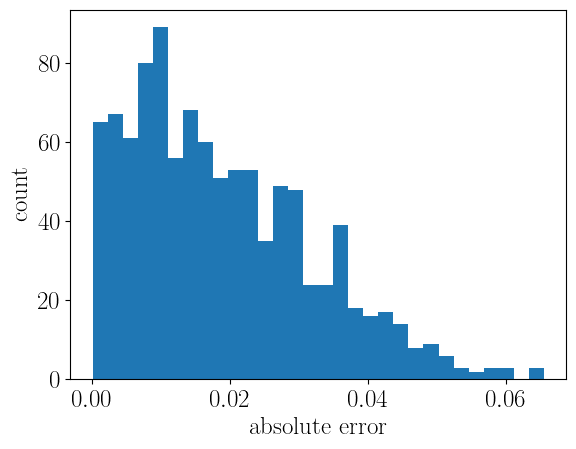

In [198]:
error_hist(test_normalized_pred_ys, test_normalized_ys)

In [199]:
test_normalized_dys = (test_dataset["greeks"] / payoffs_std) * state_std
# test_normalized_dys = 
print(test_normalized_dys)

[[0.0286272  0.00267129]
 [0.6665966  0.04530753]
 [1.081068   0.01601491]
 ...
 [0.11116049 0.01897371]
 [0.88837004 0.04854074]
 [0.87786275 0.03905698]]


In [200]:
# overall error in dS predictions
jnp.sqrt(mse(test_normalized_pred_dys[:, 0], test_normalized_dys[:, 0]))

Array(0.02036249, dtype=float32)

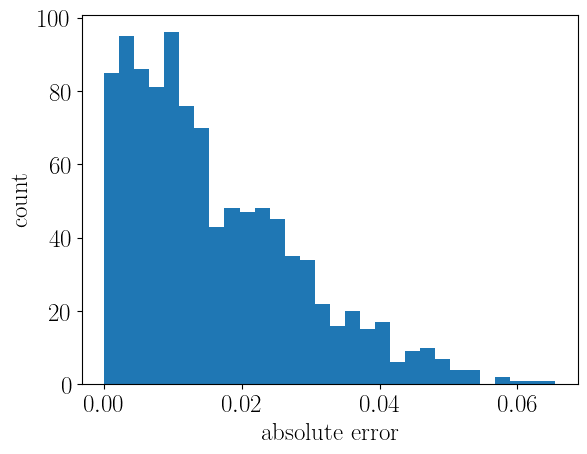

In [201]:
error_hist(test_normalized_pred_dys[:, 0], test_normalized_dys[:, 0])

In [202]:
jnp.sqrt(mse(test_normalized_pred_dys[:, 1], test_normalized_dys[:, 1]))

Array(0.00610605, dtype=float32)

In [203]:
test_normalized_pred_dys / state_std * payoffs_std

Array([[ 2.5737690e-02, -6.1135688e+00],
       [ 5.6885415e-01,  4.5919651e+01],
       [ 9.5691276e-01,  1.9194231e+01],
       ...,
       [ 1.1827595e-01,  1.8408039e+01],
       [ 7.7458841e-01,  5.3792564e+01],
       [ 7.8567356e-01,  4.0025120e+01]], dtype=float32)

In [204]:
test_normalized_dys / state_std * payoffs_std

Array([[2.4982315e-02, 2.5934136e+00],
       [5.8172387e-01, 4.3986668e+01],
       [9.4342381e-01, 1.5548029e+01],
       ...,
       [9.7007260e-02, 1.8420567e+01],
       [7.7526051e-01, 4.7125622e+01],
       [7.6609105e-01, 3.7918346e+01]], dtype=float32)

In [205]:
test_dataset["greeks"]

Array([[2.4982316e-02, 2.5934134e+00],
       [5.8172387e-01, 4.3986668e+01],
       [9.4342387e-01, 1.5548027e+01],
       ...,
       [9.7007267e-02, 1.8420567e+01],
       [7.7526057e-01, 4.7125622e+01],
       [7.6609111e-01, 3.7918346e+01]], dtype=float32)

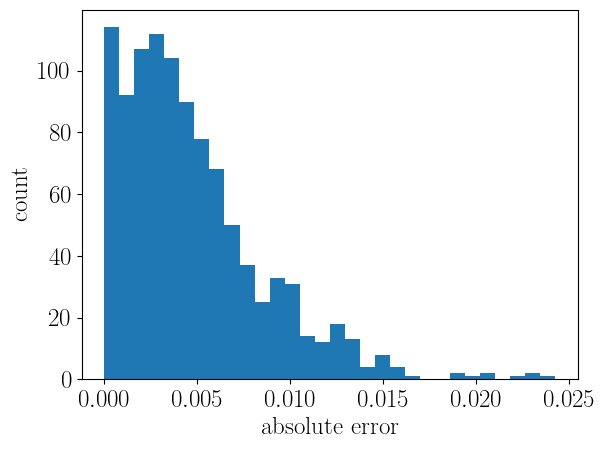

In [206]:
error_hist(test_normalized_pred_dys[:, 1], test_normalized_dys[:, 1])

In [207]:
pred_values, pred_derivs = jax.value_and_grad(surrogate_model)((jnp.array([100.0, 0.09]) - x_mean) / x_std)
print(pred_values * y_std + y_mean)

# unscaled predicted derivs
(payoffs_std / state_std) *  pred_derivs

10.199706857057983


Array([ 0.63984795, 33.98060637], dtype=float64)

In [208]:
res = surrogate_model((test_dataset["initial_states"][2] - x_mean) / x_std)
print(res * y_std + y_mean)
print("vs true: ", test_dataset["prices"][2])

44.8634743753848
vs true:  43.71714


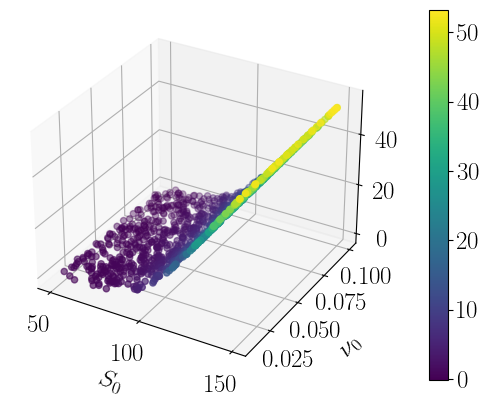

In [209]:
xs = test_dataset["initial_states"]
ys = test_normalized_pred_ys * y_std + y_mean
fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys, "predicted test set prices")

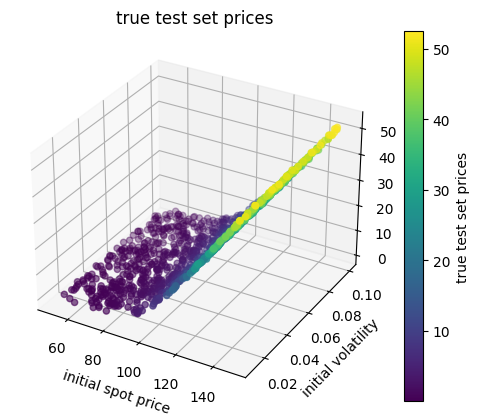

In [288]:
xs = test_dataset["initial_states"]
ys =  test_dataset["prices"]
fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys, "true test set prices")

In [210]:
(y_std / x_std) * test_normalized_pred_dys

Array([[ 2.5755864e-02, -6.1102924e+00],
       [ 5.6925589e-01,  4.5895039e+01],
       [ 9.5758849e-01,  1.9183945e+01],
       ...,
       [ 1.1835946e-01,  1.8398174e+01],
       [ 7.7513540e-01,  5.3763737e+01],
       [ 7.8622836e-01,  4.0003670e+01]], dtype=float32)

In [211]:
 test_dataset["greeks"][:, 1]

Array([ 2.5934134, 43.986668 , 15.548027 , ..., 18.420567 , 47.12562  ,
       37.918346 ], dtype=float32)

In [212]:
test_dataset["greeks"]

Array([[2.4982316e-02, 2.5934134e+00],
       [5.8172387e-01, 4.3986668e+01],
       [9.4342387e-01, 1.5548027e+01],
       ...,
       [9.7007267e-02, 1.8420567e+01],
       [7.7526057e-01, 4.7125622e+01],
       [7.6609111e-01, 3.7918346e+01]], dtype=float32)

In [213]:
y_std

Array(25.20982, dtype=float32)

In [214]:
x_std

Array([2.88675135e+01, 2.59807621e-02], dtype=float64, weak_type=True)

In [215]:
test_normalized_pred_dys / x_std * y_std

Array([[ 2.5755865e-02, -6.1102924e+00],
       [ 5.6925589e-01,  4.5895039e+01],
       [ 9.5758855e-01,  1.9183947e+01],
       ...,
       [ 1.1835946e-01,  1.8398174e+01],
       [ 7.7513540e-01,  5.3763737e+01],
       [ 7.8622842e-01,  4.0003670e+01]], dtype=float32)

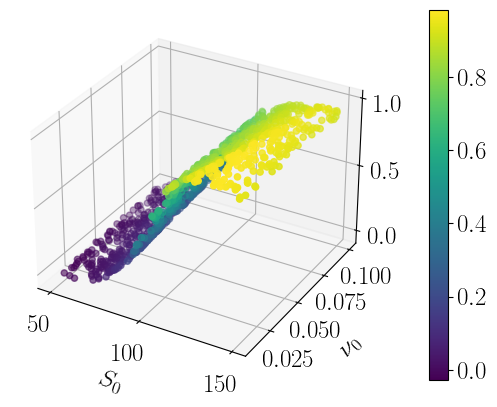

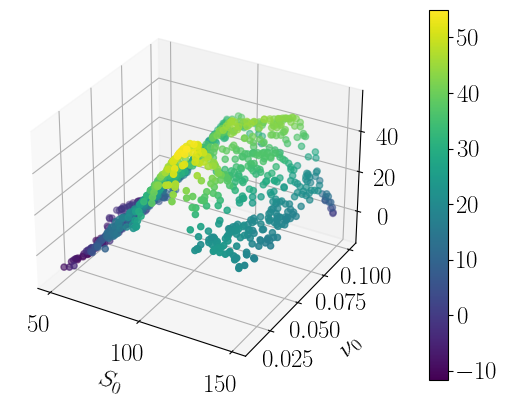

In [216]:
xs = test_dataset["initial_states"]
ys = test_normalized_pred_dys / state_std * payoffs_std

fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys[:, 0], "predicted greeks dS")
fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys[:, 1], "predicted greeks dV")

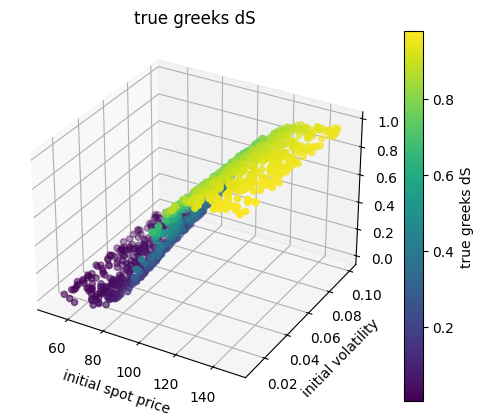

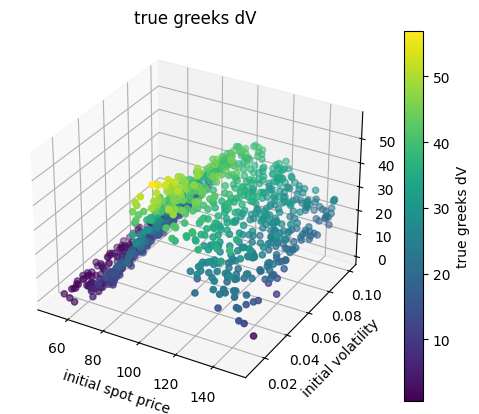

In [296]:
xs = test_dataset["initial_states"]
g0 = test_dataset["greeks"][:, 0]
g1 = test_dataset["greeks"][:, 1]
fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], g0, "true greeks dS")
fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], g1, "true greeks dV")

# Differential ML with on-the-fly data generation

## Definition

In [219]:
def training_batch(key):
    batch_size = 2**8
    key, key_state = jrandom.split(key, 2)

    spot_range = Range(50.0, 150.0)
    vol_range = Range(0.01, 0.1)

    params = Heston.Parameters(
        K = 100.0,   
        r = 0.00,
        T = 1.0,
        rho = -0.3,
        kappa = 1.0,
        theta = 0.09,
        xi = 1.0,
    )
   
    initial_states = jrandom.uniform(key_state, shape=(batch_size, 2), minval=jnp.array([spot_range.minval, vol_range.minval]), maxval=jnp.array([spot_range.maxval, vol_range.maxval]))
    initial_spots = initial_states[:, 0]
    initial_vols = initial_states[:, 1]
    
    hs = Heston.from_parameters(params, S0=initial_spots, v0=initial_vols)
    
    path_seeds = jrandom.split(key, batch_size)
    ps, dps = eqx.filter_vmap(partial(differential_path, n_time_steps=1024))(hs, path_seeds)
    
    # return HestonTrainingSet(initial_states, ps, dps)
    return initial_states, ps, dps

In [220]:
@eqx.filter_jit
def diff_loss_on_the_fly_data_fn(model: eqx.nn.MLP, key: PRNGKeyArray) -> Float:

    x, y, dydx = training_batch(key)
    x = (x - x_mean) / x_std
    y = (y - y_mean) / y_std
    dydx = dydx 
    
    lam = 1
    n_dims = model.in_size
    lambda_scale = lam * n_dims
    alpha = 1.0/(1.0 + lambda_scale)
    beta = lambda_scale/(1.0 + lambda_scale)

    # alpha = 0.5
    # beta = 1.0 - alpha
    y_pred, dydx_pred = vmap(eqx.filter_value_and_grad(model))(x)

    # normalize dydx since the predictions are normalized. TODO: should happen somewhere else
    # dynamic_dydx, static_dydx = eqx.partition(dydx, eqx.is_array)
    # dynamic_dydx = jax.tree_util.tree_map(lambda dy, k: dy / payoffs_std * k, dynamic_dydx, state_std)
    # dydx_scaled = eqx.combine(dynamic_dydx, static_dydx)
    dydx_array = jnp.stack((dydx.S0, dydx.v0), axis=1)
    dydx_scaled = dydx_array / y_std * x_std
    # dydx_scaled = dydx_array / payoffs_std * state_std
    dydx_pred = dydx_pred
        
    assert(y_pred.shape == y.shape)
    assert(dydx_pred.shape == dydx_scaled.shape)
    
    value_loss = jnp.mean((y_pred - y)**2)
    # jax.debug.print("value loss: {}", value_loss)

    grad_loss = jnp.mean(lambda_j**2 * (dydx_pred - dydx_scaled)**2)
    
    # jax.debug.print("dydx_pred: {}", dydx_pred)
    # jax.debug.print("dydx_true: {}", dydx_scaled)
    loss = alpha * value_loss + beta * grad_loss

    # jax.debug.print('[Internal] Value Loss {value_loss} | Grad Loss: {grad_loss}', value_loss=value_loss, grad_loss=grad_loss)
    return loss

In [221]:
Data: TypeAlias = dict[str, Float[Array, "n_samples ..."]]
DataGenerator: TypeAlias = Generator[Data, None, None]

def diff_train_otf(
    model: PyTree,
    key: PRNGKeyArray,
    test_data: Optional[Data],
    optim: optax.GradientTransformation,
    n_epochs: int,
) -> PyTree:
    @eqx.filter_jit
    def train_step(model: PyTree, opt_state: PyTree, key: PRNGKeyArray):
        loss_value, grads = eqx.filter_value_and_grad(diff_loss_on_the_fly_data_fn)(model, key)
        updates, opt_state = optim.update(grads, opt_state, model)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss_value

    opt_state = optim.init(eqx.filter(model, eqx.is_array))
    train_loss = jnp.zeros(1)

    n_steps_per_epoch = 64
    n_steps = n_epochs * n_steps_per_epoch

    keys = jrandom.split(key, n_steps)
    
    for i, key in enumerate(keys):
        model, opt_state, train_loss = train_step(model, opt_state, key)

        if i % n_steps_per_epoch == 0:
            epoch_stats = f"Finished epoch {i:3d} | Train Loss: {train_loss:.5f}"    
            print(epoch_stats)

    return model

## Train

In [222]:
key = jrandom.PRNGKey(0)
key, subkey = jrandom.split(key)

# in_size is 2 for initial_spot and initial_vol
n_dims = 2
mlp = eqx.nn.MLP(key=subkey, in_size=n_dims, out_size="scalar", width_size=20, depth=3, activation=jax.nn.elu)

key, subkey = jax.random.split(key)
mlp = init_linear_weight(mlp, trunc_init, key)
surrogate_model = mlp

In [223]:
n_epochs = 40
BATCH_SIZE = 256

key = jrandom.PRNGKey(42)
generator_test_ds = None
# total_steps = n_epochs * (len(ds["payoffs"]) // BATCH_SIZE) + n_epochs

# total_steps = 128 * n_epochs
# lr_schedule = optax.exponential_decay(init_value=0.01, transition_steps=total_steps, transition_begin=int(total_steps*0.2), decay_rate=0.9)
# optim = optax.adam(learning_rate=lr_schedule)
optim = optax.adam(learning_rate=3e-4)
surrogate_model = diff_train_otf(surrogate_model, key, generator_test_ds, optim, n_epochs=n_epochs)


Finished epoch   0 | Train Loss: 1.15036
Finished epoch  64 | Train Loss: 0.51692
Finished epoch 128 | Train Loss: 0.49701
Finished epoch 192 | Train Loss: 0.81805
Finished epoch 256 | Train Loss: 0.47893
Finished epoch 320 | Train Loss: 0.44494
Finished epoch 384 | Train Loss: 0.37304
Finished epoch 448 | Train Loss: 0.28311
Finished epoch 512 | Train Loss: 0.33764
Finished epoch 576 | Train Loss: 0.37787
Finished epoch 640 | Train Loss: 0.33834
Finished epoch 704 | Train Loss: 0.43067
Finished epoch 768 | Train Loss: 0.28492
Finished epoch 832 | Train Loss: 0.54436
Finished epoch 896 | Train Loss: 0.28890
Finished epoch 960 | Train Loss: 0.52041
Finished epoch 1024 | Train Loss: 0.32201
Finished epoch 1088 | Train Loss: 0.46796
Finished epoch 1152 | Train Loss: 0.51602
Finished epoch 1216 | Train Loss: 0.29067
Finished epoch 1280 | Train Loss: 0.39894
Finished epoch 1344 | Train Loss: 0.52726
Finished epoch 1408 | Train Loss: 0.55918
Finished epoch 1472 | Train Loss: 0.55875
Finished

In [224]:
pred_values, pred_derivs = jax.value_and_grad(surrogate_model)((jnp.array([100.0, 0.09]) - x_mean) / x_std)
print(pred_values * y_std + y_mean)

# unscaled predicted derivs
print((y_std / x_std) *  pred_derivs)
print((payoffs_std / state_std) *  pred_derivs)
print(x_std)
print(state_std)

9.572594175606921
[ 0.58736175 34.7772589 ]
[ 0.58694727 34.79590555]
[2.88675135e+01 2.59807621e-02]
[2.8887899e+01 2.5966838e-02]


In [225]:
payoffs_std

Array(25.20982, dtype=float32)

In [226]:
y_std

Array(25.20982, dtype=float32)

In [227]:
x_std - state_std

Array([-2.03857422e-02,  1.39232725e-05], dtype=float32)

In [228]:
state_std

Array([2.8887899e+01, 2.5966838e-02], dtype=float32)

In [229]:

test_normalized_xs = test_dataset["initial_states"]
test_normalized_xs = (test_normalized_xs - x_mean) / x_std
test_normalized_ys = test_dataset["prices"]
test_normalized_ys = (test_normalized_ys - y_mean) / y_std

# eval on predictions
test_normalized_pred_ys, test_normalized_pred_dys = vmap(jax.value_and_grad(surrogate_model))(test_normalized_xs)
jnp.sqrt(mse(test_normalized_pred_ys, test_normalized_ys))

Array(0.01615282, dtype=float64)

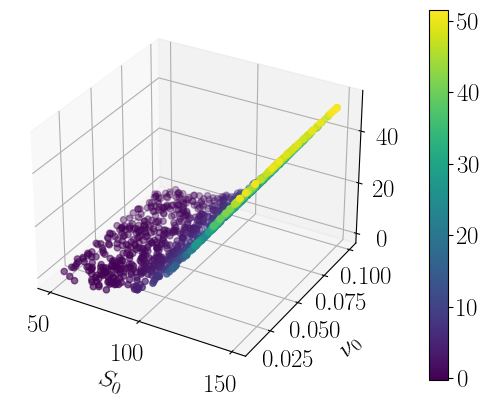

In [230]:
xs = test_dataset["initial_states"]
ys = test_normalized_pred_ys * y_std + y_mean
fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys, "predicted test set prices")

In [231]:
test_normalized_dys = (test_dataset["greeks"] / y_std) * x_std

In [232]:
jnp.sqrt(mse(test_normalized_pred_dys[:, 0], test_normalized_dys[:, 0]))

Array(0.03588276, dtype=float32)

In [233]:
jnp.sqrt(mse(test_normalized_pred_dys[:, 1], test_normalized_dys[:, 1]))

Array(0.00708438, dtype=float32)

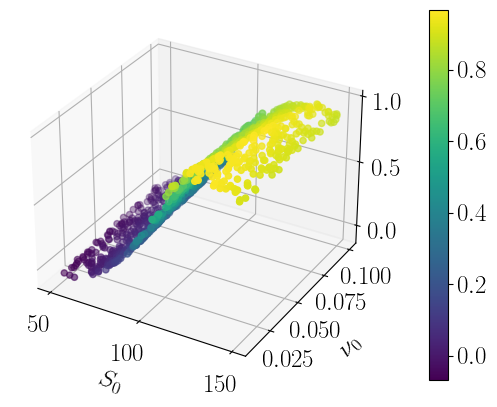

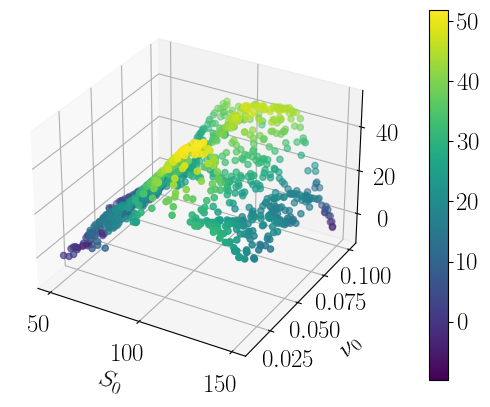

In [234]:
xs = test_dataset["initial_states"]
ys = test_normalized_pred_dys / state_std * payoffs_std

fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys[:, 0], "predicted greeks dS")
fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys[:, 1], "predicted greeks dV")

# Differential ML with on-the-fly data generation and sampling adjustments

In [16]:
key = jrandom.PRNGKey(0)
keys = jrandom.split(key, 1000)

dirichlet_samples = jax.vmap(partial(jrandom.dirichlet, alpha=100.0 * jnp.array([0.4, 0.6])))(keys)

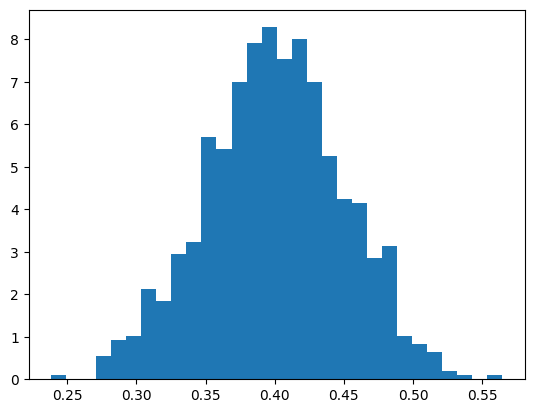

In [17]:

plt.hist(dirichlet_samples[:, 0], 30, density=True)
# plt.hist(res[:, 1], 30, density=True)
plt.show()

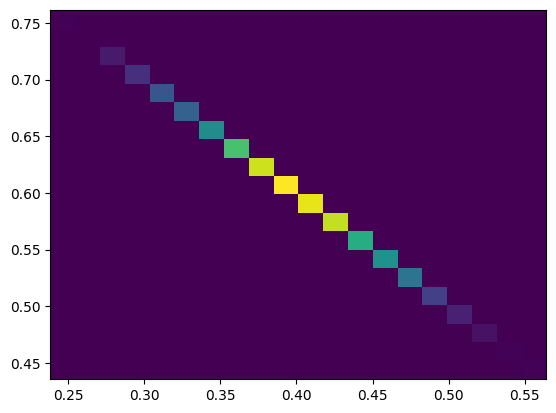

In [18]:
plt.hist2d(dirichlet_samples[:, 0], dirichlet_samples[:, 1], bins=(20, 20)) #, cmap=plt.cm.jet)
plt.show()

In [19]:
dirichlet_samples

Array([[0.47946814, 0.52053186],
       [0.36550767, 0.63449233],
       [0.46493835, 0.53506165],
       ...,
       [0.39014506, 0.60985494],
       [0.33174871, 0.66825129],
       [0.41163669, 0.58836331]], dtype=float64)

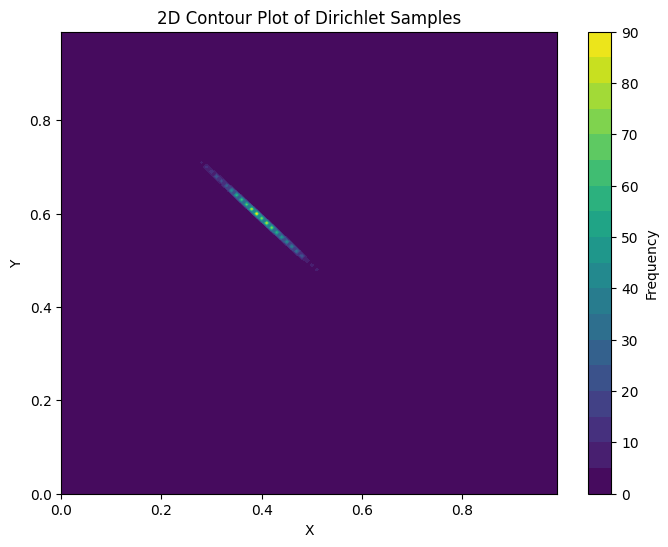

In [20]:

# Set alpha values
alpha_values = jnp.array([10.0, 20.0]) * 0.1

# Generate random samples from a 2D Dirichlet distribution
num_samples = 1000
# samples = jrandom.dirichlet(alpha_values, num_samples)
samples = dirichlet_samples
# Create a 2D histogram for the samples
x = samples[:, 0]
y = samples[:, 1]
hist, xedges, yedges = jnp.histogram2d(x, y, bins=100, range=[[0, 1], [0, 1]])

# Create a contour plot
plt.figure(figsize=(8, 6))
plt.contourf(xedges[:-1], yedges[:-1], hist.T, levels=20) #, cmap='viridis')
plt.colorbar(label='Frequency')
plt.title('2D Contour Plot of Dirichlet Samples')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()


In [100]:
def vis_snd_diffs(xs, ys, label):
    fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys[:, 0], label + " (dSdS)")
    plt.show()

def vis_snd_diffs_pred(xs, ys):
    vis_snd_diffs(xs, ys, "pred")

def vis_snd_diffs_data(xs, ys):
    vis_snd_diffs(xs, jnp.stack((ys.S0, ys.v0), axis=1), "data")

def vis_snd_diffs_delta(xs, ys):
    vis_snd_diffs(xs, ys, "delta")


def vis_diffs(xs, ys, label):
    fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys[:, 0], label + " (S0)")
    plt.show()
    fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys[:, 1], label + " (v0)")
    plt.show()

def vis_diffs_pred(xs, ys):
    vis_diffs(xs, ys, "pred")

def vis_diffs_data(xs, ys):
    vis_diffs(xs, jnp.stack((ys.S0, ys.v0), axis=1), "data")

def vis_diffs_delta(xs, ys):
    vis_diffs(xs, ys, "delta")

def vis_y(xs, ys, label):
    fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys, label + " (y)")
    plt.show()

def vis_y_pred(xs, ys):
    vis_y(xs, ys, "pred")

def vis_y_data(xs, ys):
    vis_y(xs, ys, "data")

def vis_y_delta(xs, ys):
    vis_y(xs, ys, "delta")

In [113]:

def training_batch(key, debug=False):
    batch_size = 2**12
    key, key_state = jrandom.split(key, 2)

    spot_range = Range(50.0, 150.0)
    vol_range = Range(0.01, 0.1)

    params = Heston.Parameters(
        K = 100.0,   
        r = 0.00,
        T = 1.0,
        rho = -0.3,
        kappa = 1.0,
        theta = 0.09,
        xi = 1.0,
    )
   
    initial_states = jrandom.uniform(key_state, shape=(batch_size, 2), minval=jnp.array([spot_range.minval, vol_range.minval]), maxval=jnp.array([spot_range.maxval, vol_range.maxval]))
    initial_spots = initial_states[:, 0]
    initial_vols = initial_states[:, 1]
    
    hs = Heston.from_parameters(params, S0=initial_spots, v0=initial_vols)
    
    path_seeds = jrandom.split(key, batch_size)
    ps, dps = eqx.filter_vmap(partial(differential_path, n_time_steps=1024))(hs, path_seeds)


    xs = initial_states
    ys = dps
    if debug:
        jax.debug.callback(vis_diffs_data, xs, ys)
        jax.debug.callback(vis_y_data, xs, ps)
    # return HestonTrainingSet(initial_states, ps, dps)
    return initial_states, ps, dps

In [79]:
@eqx.filter_jit
def diff_loss_on_the_fly_data_fn(model: eqx.nn.MLP, state, key: PRNGKeyArray, debug=False) -> Float:

    x, y, dydx = training_batch(key, debug=debug)

    # apply batchnorm: TODO: use equinox built-in functionality
    use_batch_norm=False
    if not use_batch_norm:
        x = (x - x_mean) / x_std
        y = (y - y_mean) / y_std
    
        # x_batch_mean = jnp.mean(x)
        # x_batch_std = jnp.std(x)
        # y_batch_mean = jnp.mean(y)
        # y_batch_std = jnp.std(y)
        # x = (x - x_batch_mean) / x_batch_std
        # y = (y - y_batch_mean) / y_batch_std 
        dydx = dydx 
        # normalize dydx since the predictions are normalized. TODO: should happen somewhere else
        # dynamic_dydx, static_dydx = eqx.partition(dydx, eqx.is_array)
        # dynamic_dydx = jax.tree_util.tree_map(lambda dy, k: dy / payoffs_std * k, dynamic_dydx, state_std)
        # dydx_scaled = eqx.combine(dynamic_dydx, static_dydx)
        dydx_array = jnp.stack((dydx.S0, dydx.v0), axis=1)
        # dydx_scaled = dydx_array / y_std * x_std
        dydx_scaled = dydx_array / payoffs_std * state_std
    
    lam = 1
    n_dims = model.in_size
    lambda_scale = lam * n_dims
    alpha = 1.0/(1.0 + lambda_scale)
    beta = lambda_scale/(1.0 + lambda_scale)

    # alpha = 0.5
    # beta = 1.0 - alpha
    if use_batch_norm:
        dmodel = eqx.filter_value_and_grad(model, has_aux=True)
        batch_dmodel = jax.vmap(
            dmodel, axis_name="batch", in_axes=(0, None) ##, out_axes=(0, None)
        )
        # batch_dmodel = jax.vmap(dmodel)
        # (y_pred, dydx_pred), state = batch_dmodel(x, state)
        res = batch_dmodel(x, state)
    else:
        y_pred, dydx_pred = jax.vmap(eqx.filter_value_and_grad(model))(x)
        
    if debug:
        jax.debug.callback(vis_diffs_pred, x, dydx_pred)
        jax.debug.callback(vis_y_pred, x, y_pred)

    assert(y_pred.shape == y.shape)
    assert(dydx_pred.shape == dydx_scaled.shape)
    
    dydx_pred =  dydx_pred * lambda_j
    dydx_scaled = dydx_scaled * lambda_j
    
    value_loss = jnp.mean((y_pred - y)**2)
    grad_loss = jnp.mean((dydx_pred - dydx_scaled)**2)

    if debug:
        jax.debug.callback(vis_y_delta, x, (y_pred - y)**2)
        jax.debug.callback(vis_diffs_delta, x, (dydx_pred - dydx_scaled)**2)
    # jax.debug.print("dydx_pred: {}", dydx_pred)
    # jax.debug.print("dydx_true: {}", dydx_scaled)
    loss = alpha * value_loss + beta * grad_loss

    # jax.debug.print('[Internal] Value Loss {value_loss} | Grad Loss: {grad_loss}', value_loss=value_loss, grad_loss=grad_loss)
    return loss, state

In [80]:
Data: TypeAlias = dict[str, Float[Array, "n_samples ..."]]
DataGenerator: TypeAlias = Generator[Data, None, None]

def diff_train_otf(
    model: PyTree,
    key: PRNGKeyArray,
    test_data: Optional[Data],
    optim: optax.GradientTransformation,
    n_epochs: int,
    debug: bool = False
) -> PyTree:
    @eqx.filter_jit
    def train_step(model: PyTree, state, opt_state: PyTree, key: PRNGKeyArray, debug=False):
        (loss_value, state), grads = eqx.filter_value_and_grad(diff_loss_on_the_fly_data_fn, has_aux=True)(model, state, key, debug=debug)
        updates, opt_state = optim.update(grads, opt_state, model)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss_value

    opt_state = optim.init(eqx.filter(model, eqx.is_array))
    state = eqx.nn.State(model)
    print(state)

    train_loss = jnp.zeros(1)

    n_steps_per_epoch = 64
    n_steps = n_epochs * n_steps_per_epoch

    keys = jrandom.split(key, n_steps)
    
    for i, key in enumerate(keys):
        model, opt_state, train_loss = train_step(model, state, opt_state, key, debug=(i % n_steps_per_epoch == 0) and debug)

        if i % n_steps_per_epoch == 0:
            epoch_stats = f"Finished epoch {i:3d} | Train Loss: {train_loss:.5f}"    
            print(epoch_stats)

    return model

In [81]:
class BatchNormMLP(eqx.Module):
    norm_in: eqx.nn.BatchNorm
    mlp: eqx.nn.MLP
    norm_out: eqx.nn.BatchNorm
    in_size: int
    
    def __init__(self, *, in_size, key):
        key, subkey = jrandom.split(key)
        self.norm_in = eqx.nn.BatchNorm(input_size=in_size, axis_name="batch")
        self.mlp = eqx.nn.MLP(key=subkey, in_size=in_size, out_size=1, width_size=20, depth=3, activation=jax.nn.elu)
        self.norm_out = eqx.nn.BatchNorm(input_size=1, axis_name="batch")
        self.in_size = in_size

    def __call__(self, x, state):
        x, state = self.norm_in(x, state)
        x = self.mlp(x)
        x, state = self.norm_out(x, state)
        x = jnp.squeeze(x)
        return x, state


In [82]:
key = jrandom.PRNGKey(0)
key, subkey = jrandom.split(key)

# in_size is 2 for initial_spot and initial_vol
n_dims = 2
mlp = eqx.nn.MLP(key=subkey, in_size=n_dims, out_size="scalar", width_size=20, depth=3, activation=jax.nn.elu)
# mlp = BatchNormMLP(key=subkey, in_size=n_dims)
key, subkey = jax.random.split(key)
mlp = init_linear_weight(mlp, trunc_init, key)
surrogate_model = mlp

In [83]:
n_epochs = 20
BATCH_SIZE = 256

key = jrandom.PRNGKey(42)
generator_test_ds = None
# total_steps = n_epochs * (len(ds["payoffs"]) // BATCH_SIZE) + n_epochs

# total_steps = 128 * n_epochs
# lr_schedule = optax.exponential_decay(init_value=0.01, transition_steps=total_steps, transition_begin=int(total_steps*0.2), decay_rate=0.9)
# optim = optax.adam(learning_rate=lr_schedule)
optim = optax.adam(learning_rate=3e-4)
surrogate_model = diff_train_otf(surrogate_model, key, generator_test_ds, optim, n_epochs=n_epochs)


State()
Finished epoch   0 | Train Loss: 1.74241
Finished epoch  64 | Train Loss: 0.65157
Finished epoch 128 | Train Loss: 0.52500
Finished epoch 192 | Train Loss: 0.46869
Finished epoch 256 | Train Loss: 0.52361
Finished epoch 320 | Train Loss: 0.48996
Finished epoch 384 | Train Loss: 0.46212
Finished epoch 448 | Train Loss: 0.50851
Finished epoch 512 | Train Loss: 0.51903
Finished epoch 576 | Train Loss: 0.47908
Finished epoch 640 | Train Loss: 0.43220
Finished epoch 704 | Train Loss: 0.44329
Finished epoch 768 | Train Loss: 0.49003
Finished epoch 832 | Train Loss: 0.42022
Finished epoch 896 | Train Loss: 0.46918
Finished epoch 960 | Train Loss: 0.38977
Finished epoch 1024 | Train Loss: 0.45659
Finished epoch 1088 | Train Loss: 0.49240
Finished epoch 1152 | Train Loss: 0.42006
Finished epoch 1216 | Train Loss: 0.46197


In [84]:
pred_values, pred_derivs = jax.value_and_grad(surrogate_model)((jnp.array([100.0, 0.09]) - x_mean) / x_std)
print(pred_values * y_std + y_mean)

# unscaled predicted derivs
print((y_std / x_std) *  pred_derivs)
print((payoffs_std / state_std) *  pred_derivs)

8.678802793630206
[0.54734046 3.80174861]
[ 0.54695423 41.84165876]


In [298]:
payoffs_std

Array(25.20982, dtype=float32)

In [299]:
y_std

Array(25.20982, dtype=float32)

In [300]:
x_std - state_std

Array([-0.02038574,  0.25982153], dtype=float32)

In [301]:
state_std

Array([2.8887899e+01, 2.5966838e-02], dtype=float32)

In [302]:

test_normalized_xs = test_dataset["initial_states"]
test_normalized_xs = (test_normalized_xs - x_mean) / x_std
test_normalized_ys = test_dataset["prices"]
test_normalized_ys = (test_normalized_ys - y_mean) / y_std

test_normalized_pred_ys, test_normalized_pred_dys = vmap(jax.value_and_grad(surrogate_model))(test_normalized_xs)
jnp.sqrt(mse(test_normalized_pred_ys, test_normalized_ys))

Array(0.02896135, dtype=float64)

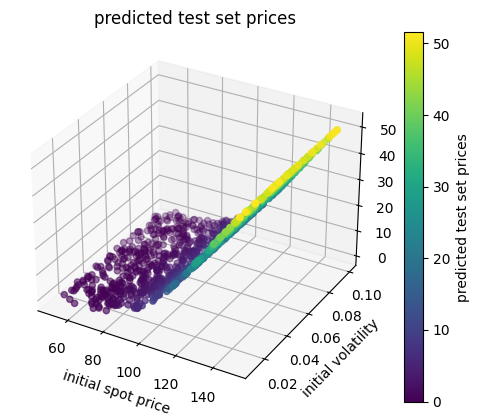

In [303]:
xs = test_dataset["initial_states"]
ys = test_normalized_pred_ys * y_std + y_mean
fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys, "predicted test set prices")

In [306]:
jnp.sqrt(mse(test_normalized_pred_dys[:, 0], test_normalized_dys[:, 0]))

Array(0.05101864, dtype=float32)

In [307]:
jnp.sqrt(mse(test_normalized_pred_dys[:, 1], test_normalized_dys[:, 1]))

Array(0.00606733, dtype=float32)

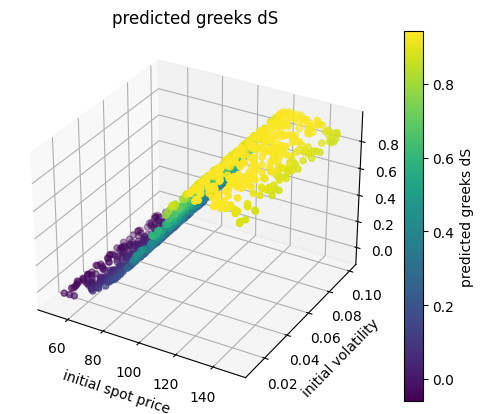

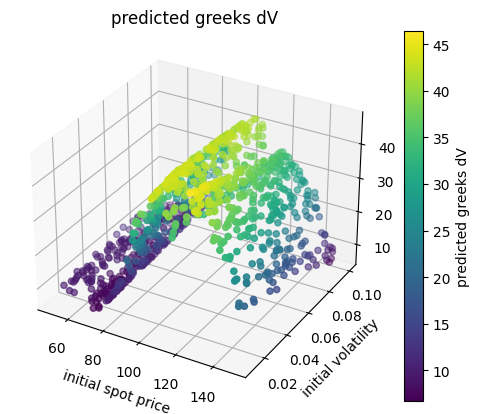

In [308]:
xs = test_dataset["initial_states"]
ys = test_normalized_pred_dys / state_std * payoffs_std

fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys[:, 0], "predicted greeks dS")
fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys[:, 1], "predicted greeks dV")

In [637]:
import numpy as np

# Generate a sample dataset
np.random.seed(0)  # For reproducibility
sample_size = 10000
alpha_true = [2, 100]  # True parameters of the Dirichlet distribution
data = np.random.dirichlet(alpha_true, sample_size)

sample_mean = np.mean(data, axis=0)
sample_covariance = np.cov(data, rowvar=False)

print(sample_mean.shape)
print(sample_covariance.shape)
print(sample_covariance)

def estimate_parameters(sample_mean, sample_covariance):
    k = len(sample_mean)  # Number of components
    alpha_estimated = np.zeros(k)

    for i in range(k):
        alpha_estimated[i] = (sample_mean[i] * (1 - sample_mean[i])) / sample_covariance[i, i] - sample_mean[i]

    return alpha_estimated

alpha_estimated = estimate_parameters(sample_mean, sample_covariance)
print("Estimated Parameters:", alpha_estimated)


(2,)
(2, 2)
[[ 0.00018869 -0.00018869]
 [-0.00018869  0.00018869]]
Estimated Parameters: [102.14023989 101.17956573]


# Second-Order Differential ML

In [235]:
class _Jac(eqx.Module):
    fun: Callable
    has_aux: bool
    rev: bool

    def __call__(self, x, /, *args, **kwargs):
        diff_x, static_x = eqx.partition(x, eqx.is_inexact_array)

        def _fun(_diff_x):
            _x = eqx.combine(_diff_x, static_x)
            _out = self.fun(_x, *args, **kwargs)
            if self.has_aux:
                _out, _aux = _out
            else:
                _aux = None
            _dynamic_out, _static_out = partition(_out, _is_jvp_tracer)
            return _dynamic_out, (_static_out, _aux)

        if self.rev:
            jacobian = jax.jacrev
        else:
            jacobian = jax.jacfwd
        dynamic_out, (static_out, aux) = jacobian(_fun, has_aux=True)(diff_x)
        out = eqx.combine(dynamic_out, static_out)
        if self.has_aux:
            return out, aux
        else:
            return out


def filter_jacfwd(fun, has_aux: bool = False):
    """Computes the Jacobian of `fun`, evaluated using forward-mode AD. The inputs and
    outputs may be arbitrary PyTrees.
    **Arguments:**
    - `fun`: The function to be differentiated.
    - `has_aux`: Indicates whether `fun` returns a pair, with the first element the
        output to be differentiated, and the latter auxiliary data. Defaults to `False`.
    **Returns:**
    A function with the same arguments as `fun`.
    If `has_aux is False` then this function returns just the Jacobian of `fun` with
    respect to its first argument.
    If `has_aux is True` then it returns a pair `(jacobian, aux)`, where `aux` is the
    auxiliary data returned from `fun`.
    """
    return _Jac(fun, has_aux, rev=False)


def filter_jacrev(fun, has_aux: bool = False):
    """Computes the Jacobian of `fun`, evaluated using reverse-mode AD. The inputs and
    outputs may be arbitrary PyTrees.
    **Arguments:**
    - `fun`: The function to be differentiated.
    - `has_aux`: Indicates whether `fun` returns a pair, with the first element the
        output to be differentiated, and the latter auxiliary data. Defaults to `False`.
    **Returns:**
    A function with the same arguments as `fun`.
    If `has_aux is False` then this function returns just the Jacobian of `fun` with
    respect to its first argument.
    If `has_aux is True` then it returns a pair `(jacobian, aux)`, where `aux` is the
    auxiliary data returned from `fun`.
    """
    return _Jac(fun, has_aux, rev=True)


def filter_hessian(fun, has_aux: bool = False):
    """Computes the Hessian of `fun`. The inputs and outputs may be arbitrary PyTrees.
    **Arguments:**
    - `fun`: The function to be differentiated.
    **Returns:**
    A function with the same arguments as `fun`.
    If `has_aux is False` then this function returns just the Hessian of `fun` with
    respect to its first argument.
    If `has_aux is True` then it returns a pair `(hessian, aux)`, where `aux` is the
    auxiliary data returned from `fun`.
    """
    return filter_jacfwd(filter_jacrev(fun, has_aux=has_aux), has_aux=has_aux)

In [29]:
# test set second order data 

In [236]:
def hvp(f, primals, tangents):
    return eqx.filter_jvp(eqx.filter_grad(f), primals, tangents)[1]
    
def second_order_differential_path(self: Heston, key: PRNGKeyArray, n_time_steps: int = 1024):
    use_hvp = True
    if use_hvp:
        p, dp = eqx.filter_value_and_grad(path_fn)(self, key, n_time_steps)
        
        h = self
        h_tangent = Heston(
            S0 = 1.0,       
            K = 0.0,   
            r = 0.00,
            v0 = 0.0, 
            T = 0.0,
            rho = 0.0,
            kappa = 0.0,
            theta = 0.0,
            xi = 0.0,
        )
        ddp = hvp(partial(path, key=key, n_time_steps=n_time_steps), (h, ), (h_tangent, ))
    else:
        p, dp_fn = eqx.filter_vjp(path, self, key, n_time_steps)
        dp, ddp = eqx.filter_jvp(dp_fn, jnp.zeros(p.size).at[0].set(1.0), jnp.zeros(p.size).at[0].set(1.0))
        print(ddp)
        dp = dp[0]
        ddp = ddp[0]
    return p, dp, ddp



def second_order_differential_path(self: Heston, key: PRNGKeyArray, n_time_steps: int = 1024):

    p, dp = eqx.filter_value_and_grad(path_fn)(self, key, n_time_steps)
    
    h = self
    h_tangent = Heston(
        S0 = 1.0,       
        K = 0.0,   
        r = 0.00,
        v0 = 0.0, 
        T = 0.0,
        rho = 0.0,
        kappa = 0.0,
        theta = 0.0,
        xi = 0.0,
    )
    ddp = hvp(partial(path, key=key, n_time_steps=n_time_steps), (h, ), (h_tangent, ))

## Sampling

### Sampling Test Prices

In [237]:
class HestonTestSet(eqx.Module):
    initial_states: Array
    # prices: Array
    # greeks: ModelState
    snd_order_ds: Heston # TODO: right now it is only w.r.t dSdX (where X is any parameter)
    # snd_order_dv: Heston
    
    def as_flattened_dict(self):
        d = asdict(self)
        # d["greeks"] = jnp.stack(self.greeks[-2:], axis=1)
        return d

    def metadata(self, spot_range: Range, vol_range: Range):
        return {"spot_range": asdict(spot_range), "vol_range": asdict(vol_range), "n_samples": self.prices.size}

@eqx.filter_jit
def test_set_precomputed(params: Heston.Parameters, *, key: PRNGKeyArray, spot_range: Range, vol_range: Range) -> HestonTestSet:

    minvals = jnp.array([spot_range.minval, vol_range.minval])
    maxvals = jnp.array([spot_range.maxval, vol_range.maxval])
    n_outer_paths = 2**10
    
    @scan_tqdm(n_outer_paths, print_rate=10)
    def test_set_precomputed_inner(carry, x):
        i, key = x
        n_inner_paths = 2**13
        key, key_state = jrandom.split(key)

        # inisde the inner loop of the test set we always use the same initial state to determine the price afterwards.
        initial_states = jnp.ones((n_inner_paths, 2)) * jrandom.uniform(key_state, shape=(2,), minval=minvals, maxval=maxvals)
        initial_spots = initial_states[:, 0]
        initial_vols = initial_states[:, 1]
        
        # jax.debug.print("initial spots {}", initial_spots)
        
        hs = Heston.from_parameters(params, S0=initial_spots, v0=initial_vols)
        
        path_seeds = jrandom.split(key, n_inner_paths)
        # ps, dps = eqx.filter_vmap(partial(differential_path, n_time_steps=1024))(hs, path_seeds)
        ddps = eqx.filter_vmap(partial(hvp_s_path, n_time_steps=1024))(hs, path_seeds)
        # ddps_v = eqx.filter_vmap(partial(hvp_v_path, n_time_steps=1024))(hs, path_seeds)

        return carry, HestonTestSet(initial_states, ddps)
    
    key, subkey = jrandom.split(key)
    key_rngs = jrandom.split(subkey, n_outer_paths)
    carry, ds = jax.lax.scan(test_set_precomputed_inner, None,  (jnp.arange(n_outer_paths), key_rngs))

    # jax.debug.print("ds payoffs {}", ds.payoffs.shape)
    # jax.debug.print("ds payoffs {}", ds.payoffs)

    def discounted_avg(x, h: Heston.Parameters):
        return jnp.mean(x, axis=1) * jnp.exp(-h.r * h.T) 
    
    test_set = HestonTestSet(*astuple(jax.tree_util.tree_map(partial(discounted_avg, h=hs_params), ds)))

    # jax.debug.print("test set {}", test_set)
    
    return test_set

In [238]:
key = jrandom.PRNGKey(0)

spot_range = Range(50.0, 150.0)
vol_range = Range(0.01, 0.1)

# spot_range = Range(100.0, 100.0)
# vol_range = Range(0.09, 0.09)

hs_params = Heston.Parameters(
    K = 100.0,   
    r = 0.00,
    T = 1.0,
    rho = -0.3,
    kappa = 1.0,
    theta = 0.09,
    xi = 1.0,
)

test_set_snd_order = test_set_precomputed(params=hs_params, key=key, spot_range=spot_range, vol_range=vol_range)

  0%|          | 0/1024 [00:00<?, ?it/s]

In [239]:
test_set_snd_order

HestonTestSet(
  initial_states=f64[1024,2],
  snd_order_ds=(
    None,
    f64[1024],
    f64[1024],
    None,
    f64[1024],
    f64[1024],
    f64[1024],
    f64[1024],
    f64[1024]
  )
)

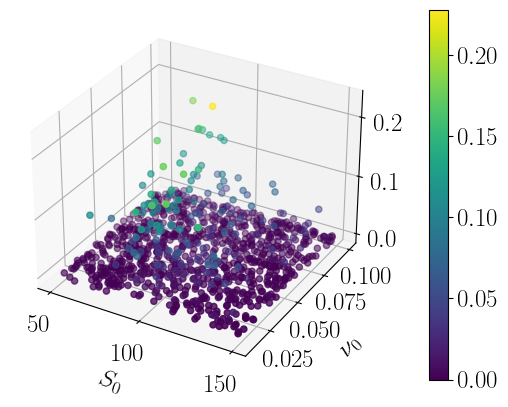

In [240]:
xs = test_set_snd_order.initial_states
xs, ys = xs[:, 0], xs[:, 1]
dsds = test_set_snd_order.snd_order_ds[-2]
# dsdv = test_set_snd_order.snd_order_ds[-1]
# dvds = test_set_snd_order.snd_order_dv[-2]
# dvdv = test_set_snd_order.snd_order_dv[-1]
fig_dSdS = plot_3d_differential_data(xs, ys, dsds, "test dSdS")
# fig_dSdV = plot_3d_differential_data(xs, ys, dsdv, "test dSdv")
# fig_dVdS = plot_3d_differential_data(xs, ys, dvds, "test dVdS")
# fig_dVdV = plot_3d_differential_data(xs, ys, dvdv, "test dVdv")

# fig_dS = plot_3d_differential_data(xs, ys, greeks[:, 0], "deltas")
# fig_dS = plot_3d_differential_data(xs, ys, greeks[:, 1], "dv")

In [241]:
import scipy

In [242]:
scipy.stats.skew(dsds)

3.473735473804065

In [314]:
scipy.stats.variation(dsds)

90.50414352244741

In [315]:
dsds.std()

Array(5.21464282, dtype=float64)

In [243]:
scipy.stats.kurtosis(dsds)

12.90018084058056

In [244]:
scipy.stats.skew(test_set_snd_order.snd_order_ds[-1])

-4.0716815659003345

In [245]:
scipy.stats.kurtosis(test_set_snd_order.snd_order_ds[-1])

65.07828439755222

### Sampling Random Paths

In [246]:
# random data computation like you would see it during training

@eqx.filter_jit
def sample_random_paths(params: Heston.Parameters, *, key: PRNGKeyArray, spot_range: Range, vol_range: Range) -> HestonTestSet:

    minvals = jnp.array([spot_range.minval, vol_range.minval])
    maxvals = jnp.array([spot_range.maxval, vol_range.maxval])
    n_outer_paths = 2**10
    
    @scan_tqdm(n_outer_paths, print_rate=10)
    def test_set_precomputed_inner(carry, x):
        i, key = x
        n_inner_paths = 2**13
        key, key_state = jrandom.split(key)

        # inisde the inner loop of the test set we always use the same initial state to determine the price afterwards.
        initial_states = jrandom.uniform(key_state, shape=(n_inner_paths, 2), minval=minvals, maxval=maxvals)
        initial_spots = initial_states[:, 0]
        initial_vols = initial_states[:, 1]
        hs = Heston.from_parameters(params, S0=initial_spots, v0=initial_vols)
        path_seeds = jrandom.split(key, n_inner_paths)
        ddps = eqx.filter_vmap(partial(hvp_s_path, n_time_steps=1024))(hs, path_seeds)
        
        return carry, HestonTestSet(initial_states, ddps)
    
    key, subkey = jrandom.split(key)
    key_rngs = jrandom.split(subkey, n_outer_paths)
    carry, ds = jax.lax.scan(test_set_precomputed_inner, None,  (jnp.arange(n_outer_paths), key_rngs))

    return ds

In [247]:
key = jrandom.PRNGKey(0)

spot_range = Range(50.0, 150.0)
vol_range = Range(0.01, 0.1)

# spot_range = Range(100.0, 100.0)
# vol_range = Range(0.09, 0.09)

hs_params = Heston.Parameters(
    K = 100.0,   
    r = 0.00,
    T = 1.0,
    rho = -0.3,
    kappa = 1.0,
    theta = 0.09,
    xi = 1.0,
)

snd_order_path_samples = sample_random_paths(params=hs_params, key=key, spot_range=spot_range, vol_range=vol_range)

  0%|          | 0/1024 [00:00<?, ?it/s]

In [248]:
snd_order_path_samples

HestonTestSet(
  initial_states=f64[1024,8192,2],
  snd_order_ds=Heston(
    K=None,
    r=f64[1024,8192],
    T=f64[1024,8192],
    rho=None,
    kappa=f64[1024,8192],
    theta=f64[1024,8192],
    xi=f64[1024,8192],
    S0=f64[1024,8192],
    v0=f64[1024,8192]
  )
)

In [324]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": "EB Garamond",
    "font.size": 18
})


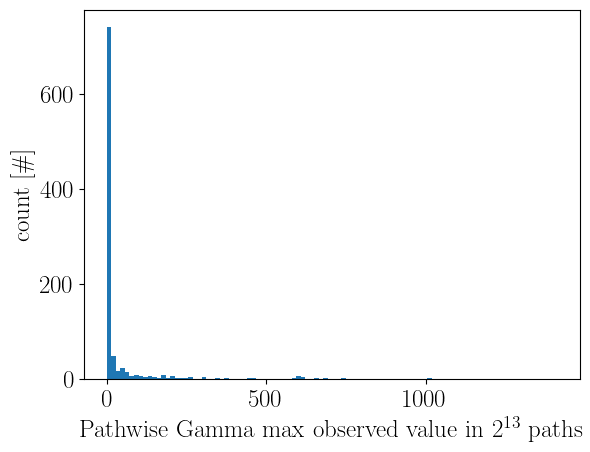

In [325]:
fig = plt.figure()
# plt.title("Histogram of Max values")
plt.hist(jnp.max(snd_order_path_samples.snd_order_ds.S0, axis=1), 100)
plt.xlabel("Pathwise Gamma max observed value in $2^{13}$ paths")
plt.ylabel("count [\#]")
fig.savefig(f'results/heston/hist_max_values.png', bbox_inches='tight', dpi=600)
fig.savefig(f'results/heston/hist_max_values.pdf', bbox_inches='tight')
plt.show()

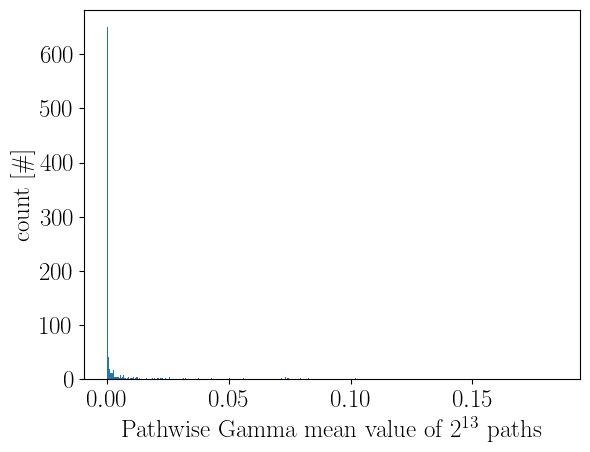

In [320]:
fig = plt.figure()
# plt.title("Histogram of Mean values")
plt.hist(jnp.mean(snd_order_path_samples.snd_order_ds.S0, axis=1), 500)
plt.xlabel("Pathwise Gamma mean value of $2^{13}$ paths")
plt.ylabel("count [\#]")
fig.savefig(f'results/heston/hist_mean_values.png', bbox_inches='tight', dpi=600)
fig.savefig(f'results/heston/hist_mean_values.pdf', bbox_inches='tight')
plt.show()

In [259]:
scipy.stats.skew(snd_order_path_samples.snd_order_ds.S0.flatten())

341.69158287908226

In [316]:
jnp.mean(snd_order_path_samples.snd_order_ds.S0.flatten())

Array(0.00943372, dtype=float64)

In [318]:
jnp.var(snd_order_path_samples.snd_order_ds.S0.flatten())

Array(5.26196633, dtype=float64)

In [260]:
scipy.stats.kurtosis(snd_order_path_samples.snd_order_ds.S0.flatten())

137745.23433212689

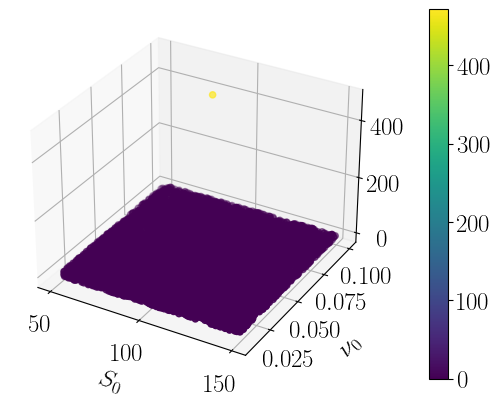

In [310]:
xs = snd_order_path_samples.initial_states
i = 10
dsds = snd_order_path_samples.snd_order_ds.S0[i, :]
fig_dSdS = plot_3d_differential_data(xs[i, :, 0], xs[i, :, 1], dsds, "dSdS path samples")

In [262]:
jnp.max(dsds)

Array(472.00440003, dtype=float64)

In [263]:
xs[jnp.argmax(dsds)]

Array([[1.22681357e+02, 3.54695821e-02],
       [1.05727870e+02, 3.82477719e-02],
       [6.62459533e+01, 5.67125902e-02],
       ...,
       [1.40110182e+02, 7.17229722e-02],
       [8.26756467e+01, 5.56353007e-02],
       [8.20937036e+01, 3.93590467e-02]], dtype=float64)

In [264]:
ys[jnp.argmax(dsds)]

Array(0.09062084, dtype=float64)

## Normalization Constants

In [265]:
x_std[0] / y_std

Array(1.14509, dtype=float32)

In [266]:
normalized_dsds = (x_std[0] * x_std[0] / y_std) * dsds
lambda_jj = 1.0 / jnp.sqrt(jnp.mean(normalized_dsds**2, axis=0))
lambda_jj

Array(0.00580096, dtype=float64)

In [267]:
normalized_dsds = (x_std[0] * x_std[0] / y_std) * dsds
normalized_dsds

Array([0., 0., 0., ..., 0., 0., 0.], dtype=float64)

In [268]:
jnp.sqrt(jnp.mean(normalized_dsds**2, axis=0))

Array(172.38523645, dtype=float64)

In [269]:
lambda_jj = 1 / jnp.mean(dsds)
lambda_jj

Array(17.35577041, dtype=float64)

In [270]:
jnp.linalg.norm(normalized_dsds, 2)

Array(15602.5305179, dtype=float64)

In [271]:
class ScanState(eqx.Module):
    payoff_sum: Array
    dpayoff_sum: ModelState
    ddpayoff_sum: ModelState # TODO: expand this to accept a hessian
    ddp_hvp_sum: Heston
    
    def __iter__(self):
        return iter(astuple(self))

@eqx.filter_jit
def price(heston: Heston, *, key: PRNGKeyArray, n_multiplier: int = 1):
    n_simulations = 100000 * n_multiplier
    n_outside_iter = 1000 * n_multiplier
    n_sims_per_iter = n_simulations // n_outside_iter
    payoff_sum: float = 0.0
    n_states = heston.S0.shape[0]

    if n_simulations % n_states:
        raise ValueError("n_states must be divisor of 1000")

    def pathwise_payoff_fn(pp: ScanState, key):
        # jax.debug.print("-" * 15)
        payoff_sum = pp.payoff_sum
        dpayoff_sum = pp.dpayoff_sum
        ddpayoff_sum = pp.ddpayoff_sum
        ddp_hvp_sum = pp.ddp_hvp_sum
        
        def payoff(heston, key):
            keys_path = jrandom.split(key, num=n_sims_per_iter)
            keys_path = jnp.reshape(keys_path, (n_sims_per_iter//n_states, n_states, 2))
            
            # p, dp, ddp = jax.vmap(lambda x: eqx.filter_vmap(second_order_differential_path)(heston, x))(keys_path)
            p, dp = jax.vmap(lambda x: eqx.filter_vmap(differential_path)(heston, x))(keys_path)

            # ddp = jax.vmap(lambda x: eqx.filter_vmap(jax.hessian(path))(heston, x))(keys_path)
            ddp = jax.vmap(lambda x: eqx.filter_vmap(hessian_path)(heston, x))(keys_path)
            # jax.debug.print("ddp: {}", ddp.S0.S0)

            ddp_hvp = jax.vmap(lambda x: eqx.filter_vmap(hvp_s_path)(heston, x))(keys_path)
            # print(ddp_hvp)
            # print(res)
            # print("res.shape: ", res)
            pathwise_payoff = jnp.reshape(p, n_sims_per_iter)
            dpayoff = dp
            ddpayoff = ddp
            return pathwise_payoff, dpayoff, ddpayoff, ddp_hvp


        pathwise_payoff, dpayoff, ddpayoff, ddp_hvp = payoff(heston, key)
        # jax.debug.print("dpayoff {}", dpayoff)
        # jax.debug.print("ddpayoff {}", ddpayoff)

        
        payoff_sum_iter = jnp.sum(pathwise_payoff, axis=0)
        dpayoff_sum_iter = jax.tree_util.tree_map(lambda x: jnp.sum(x, axis=0), dpayoff)
        ddpayoff_sum_iter = jax.tree_util.tree_map(lambda x: jnp.sum(x, axis=0), ddpayoff)
        ddp_hvp_sum_iter = jax.tree_util.tree_map(lambda x: jnp.sum(x, axis=0), ddp_hvp)
        # ddpayoff_sum_iter = jax.tree_util.tree_map(lambda x: x if x is None else jnp.zeros(1), ddpayoff_sum_iter)
        # jax.debug.print("dpayoff_sum_iter {}", dpayoff_sum_iter)
        # print("ddpayoff_sum_iter {}", ddpayoff_sum_iter)
        print(ddp_hvp_sum_iter)
        
        payoff_sum += payoff_sum_iter
        dpayoff_sum = ModelState(dpayoff_sum.S0 + dpayoff_sum_iter.S0, dpayoff_sum.v0 + dpayoff_sum_iter.v0)
        # ddpayoff_sum = Heston(S0=ddpayoff_sum.S0 + ddpayoff_sum_iter.S0)
        ddpayoff_sum = eqx.apply_updates(ddpayoff_sum, ddpayoff_sum_iter)

        ddp_hvp_sum = eqx.apply_updates(ddp_hvp_sum, ddp_hvp_sum_iter)
        # ddpayoff_sum = jax.tree_util.tree_map(lambda x, y: x + y if y is not None else x, ddpayoff_sum, ddpayoff_sum_iter)
        # print("ddpayoff_sum ", ddpayoff_sum)
        
        return ScanState(payoff_sum, dpayoff_sum, ddpayoff_sum, ddp_hvp_sum), pathwise_payoff
        
    keys = jrandom.split(key, num=n_outside_iter)
    
    # print("heston.n_states: :", n_states)

    zero_heston = jax.tree_util.tree_map(lambda x: jnp.zeros(1), Heston())
    init_ddheston = jax.tree_util.tree_map(lambda x: zero_heston, Heston())

    init_ddheston_hvp = zero_heston
    
    (payoff_sum, dpayoff_sum, ddpayoff_sum, ddp_hvp_sum), pathwise_payoffs = jax.lax.scan(pathwise_payoff_fn, ScanState(jnp.zeros(n_states), ModelState(jnp.zeros(n_states), jnp.zeros(n_states)), init_ddheston, init_ddheston_hvp), keys, length=n_outside_iter)
    # print(payoff_sum)
    # option_price = (payoff_sum / n_simulations) * jnp.exp(-heston.r * heston.T)
    return (payoff_sum, dpayoff_sum, ddpayoff_sum, ddp_hvp_sum), pathwise_payoffs


In [272]:
zero_heston = jax.tree_util.tree_map(lambda x: jnp.zeros(1), Heston())
init_ddheston = jax.tree_util.tree_map(lambda x: zero_heston, Heston())

In [164]:
key = jrandom.PRNGKey(0)
key, subkey = jrandom.split(key)
key, key_spots, key_vols = jrandom.split(subkey, 3)
n_samples = 1

initial_spots = jnp.ones(n_samples) * 100
initial_vols = jnp.ones(n_samples) * 0.09

h = Heston(S0=initial_spots, v0=initial_vols,
    K = 100.0,   
    r = 0.00,
    T = 1.0,
    rho = -0.3,
    kappa = 1.0,
    theta = 0.09,
    xi = 1.0,
)

key, subkey = jrandom.split(key)
# prices, vjp_fn = eqx.filter_vjp(partial(price, key=subkey, n_multiplier=1), h)
prices, pathwise_payoffs = price(h, key=subkey, n_multiplier=1)

Heston(
  K=None,
  r=f64[1],
  T=f64[1],
  rho=None,
  kappa=f64[1],
  theta=f64[1],
  xi=f64[1],
  S0=f64[1],
  v0=f64[1]
)


In [317]:
jax.tree_util.tree_flatten(Heston())

([100.0, 0.05, 5.0, -0.3, 2.0, 0.09, 1.0, 100.0, 0.09],
 PyTreeDef(CustomNode(Heston[('K', 'r', 'T', 'rho', 'kappa', 'theta', 'xi', 'S0', 'v0'), (), ()], [*, *, *, *, *, *, *, *, *])))

In [318]:
Heston()

Heston(
  K=100.0,
  r=0.05,
  T=5.0,
  rho=-0.3,
  kappa=2.0,
  theta=0.09,
  xi=1.0,
  S0=100.0,
  v0=0.09
)

In [165]:
n_simulations = 100000.0
jax.tree_util.tree_map(lambda x: (x/n_simulations) * jnp.exp(-h.r * h.T), prices)

(Array([9.83622213], dtype=float64),
 (Array([0.60697778], dtype=float64), Array([38.82452652], dtype=float64)),
 ((Array([0.], dtype=float64),
   Array([0.], dtype=float64),
   Array([0.], dtype=float64),
   Array([0.], dtype=float64),
   Array([0.], dtype=float64),
   Array([0.], dtype=float64),
   Array([0.], dtype=float64),
   Array([0.], dtype=float64),
   Array([0.], dtype=float64)),
  (Array([0.], dtype=float64),
   Array([266.61967736], dtype=float64),
   Array([48.42052198], dtype=float64),
   Array([0.], dtype=float64),
   Array([2.967605], dtype=float64),
   Array([137.75440818], dtype=float64),
   Array([-34.95620566], dtype=float64),
   Array([2.66880303], dtype=float64),
   Array([110.47576537], dtype=float64)),
  (Array([0.], dtype=float64),
   Array([48.42052198], dtype=float64),
   Array([-2.05120904], dtype=float64),
   Array([0.], dtype=float64),
   Array([10.74781329], dtype=float64),
   Array([107.92777437], dtype=float64),
   Array([-21.78229519], dtype=float64),


In [273]:
def hvp(f, primals, tangents):
    return jax.jvp(lambda x: eqx.filter_grad(f)(x), primals, tangents)[1]

def hmp(f, primals):
    
    def hvp_(tangents):
        return hvp(f, (primals,), (tangents, ))

    return eqx.filter_vmap(hvp_)

def batch_hmp(f):

    def hvp_(primals, tangents):
        return hvp(f, (primals, ), (tangents, ))

    return eqx.filter_vmap(eqx.filter_vmap(hvp_, in_axes=(0, None)), in_axes=(None, 1))

def hvp_args(f, primals, tangents, *f_args):
    return jax.jvp(lambda x: eqx.filter_grad(f)(x, *f_args), primals, tangents)[1]

def hmp_args(f, primals, *f_args):
    
    def hvp_(tangents):
        return hvp_args(f, (primals,), (tangents, ), *f_args)

    return eqx.filter_vmap(hvp_)

def batch_hmp_args(f, vmapped_args: Tuple = ()):

    def hvp_(primals, tangents, *f_args):
        return hvp_args(f, (primals, ), (tangents, ), *f_args)

    return eqx.filter_vmap(eqx.filter_vmap(hvp_, in_axes=(0, None, *vmapped_args)), in_axes=(None, 1, *tuple([None for _ in range(len(vmapped_args))])))

# jax cannot deal with dynamic slices of arrays
# therefore, we cannot simply slice the principal_components array while using batch_hmp

# this is a version where a 0 vector principal component will lead to a different path (namely returning 0) compared to computing a hvp.
def cond_fn_pca(tangents, *args):
    return jnp.any(tangents[0] > 0.0)  # NOTE: we set the tangents to zero if we do not want to compute its derivative (because principle component is too small)

def hvp_pca(f, primals, tangents):
    return jax.lax.cond(cond_fn_pca(tangents), lambda _: hvp(f, primals, tangents), lambda _: tangents[0], None)

def batch_hmp_select(f):

    def hvp_(primals, tangents):
        return hvp_pca(f, (primals,), (tangents,))

    return eqx.filter_vmap(eqx.filter_vmap(hvp_, in_axes=(0, None)), in_axes=(None, 1))

# this is a version where we explicitly add a list of boolean values, indicating whether we should compute the hvp or not
def hvp_conditional(f, primals, tangents, eval_hvp):
    return jax.lax.cond(eval_hvp, lambda _: hvp(f, primals, tangents), lambda _: jnp.zeros(shape=(primals[0].shape[-1],)), None)

def batch_hmp_cond(f):

    def hvp_(primals, tangents, eval_hvp):
        return hvp_conditional(f, (primals,), (tangents,), eval_hvp)

    return eqx.filter_vmap(eqx.filter_vmap(hvp_, in_axes=(0, None, None)), in_axes=(None, 1, 0))

In [274]:
@eqx.filter_jit
def second_order_diff_loss_fn(model: eqx.nn.MLP, x: Float[Array, "batch ..."], y: Float[Array, "batch ..."], dydx: Float[Array, "batch ..."]) -> Float:
    lam = 1
    n_dims = x.shape[1]
    lambda_scale = lam * n_dims
    alpha = 1.0/(1.0 + lambda_scale)
    beta = lambda_scale/(1.0 + lambda_scale)

    # alpha = 0.0
    # beta = 1.0 - alpha
    y_pred, dydx_pred = vmap(eqx.filter_value_and_grad(model))(x)

    # normalize dydx since the predictions are normalized. TODO: should happen somewhere else
    dydx_scaled = dydx / y_std * x_std
    dydx_pred = dydx_pred
        
    assert(y_pred.shape == y.shape)
    assert(dydx_pred.shape == dydx_scaled.shape)
    
    # compute second-order information
                # res = jax.vmap(lambda x: eqx.filter_vmap(jax.hessian(path_fn))(heston, x))(keys_path)
    ddy_pred = eqx.filter_vmap(jax.hessian(model))(x)
    # ddy_true = 
    
    value_loss = jnp.mean((y_pred - y)**2)
    # jax.debug.print("value loss: {}", value_loss)
    grad_loss = jnp.mean(lambda_j**2 * (dydx_pred - dydx_scaled)**2)
    # jax.debug.print("dydx_pred: {}", dydx_pred)
    # jax.debug.print("dydx_true: {}", dydx_scaled)
    loss = alpha * value_loss + beta * grad_loss

    # jax.debug.print('[Internal] Value Loss {value_loss} | Grad Loss: {grad_loss}', value_loss=value_loss, grad_loss=grad_loss)
    return loss

In [275]:
Data: TypeAlias = dict[str, Float[Array, "n_samples ..."]]
DataGenerator: TypeAlias = Generator[Data, None, None]

def snd_diff_train(
    model: PyTree,
    train_data: DataGenerator,
    test_data: Optional[Data],
    optim: optax.GradientTransformation,
    n_epochs: int,
) -> PyTree:
    @eqx.filter_jit
    def train_step(model: PyTree, opt_state: PyTree, batch: Data):

        x = batch["normalized_initial_states"]
        y = batch["normalized_payoffs"]
        dydx = batch["differentials"]
        
        loss_value, grads = eqx.filter_value_and_grad(second_order_diff_loss_fn)(model, x, y, dydx)
        updates, opt_state = optim.update(grads, opt_state, model)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss_value

    opt_state = optim.init(eqx.filter(model, eqx.is_array))
    train_loss = jnp.zeros(1)

    n_steps_per_epoch = 64
    n_steps = n_epochs * n_steps_per_epoch
    
    for i, batch in zip(range(n_steps), train_data):
        model, opt_state, train_loss = train_step(model, opt_state, batch)

        if i % n_steps_per_epoch == 0:
            epoch_stats = f"Finished epoch {i:3d} | Train Loss: {train_loss:.5f}"    
            print(epoch_stats)

    return model

## Train

### Train only second order data

In [276]:

def snd_order_training_batch(key, debug=False):
    batch_size = 2**8
    key, key_state = jrandom.split(key, 2)

    spot_range = Range(50.0, 150.0)
    vol_range = Range(0.01, 0.1)

    params = Heston.Parameters(
        K = 100.0,   
        r = 0.00,
        T = 1.0,
        rho = -0.3,
        kappa = 1.0,
        theta = 0.09,
        xi = 1.0,
    )
   
    initial_states = jrandom.uniform(key_state, shape=(batch_size, 2), minval=jnp.array([spot_range.minval, vol_range.minval]), maxval=jnp.array([spot_range.maxval, vol_range.maxval]))
    initial_spots = initial_states[:, 0]
    initial_vols = initial_states[:, 1]
    
    hs = Heston.from_parameters(params, S0=initial_spots, v0=initial_vols)
    
    path_seeds = jrandom.split(key, batch_size)
    ps, dps = eqx.filter_vmap(partial(differential_path, n_time_steps=1024))(hs, path_seeds)

    ddps_ref = eqx.filter_vmap(partial(hessian_path, n_time_steps=1024))(hs, path_seeds)
    # ddps_ref = eqx.filter_vmap(partial(jax.hessian(path), n_time_steps=1024))(hs, path_seeds)
    # jax.tree_util.tree_structure(ddps_ref)
    # jax.tree_util.tree_map(lambda x: jax.debug.print("{}", x), ddps_ref)
    # jax.debug.print("ddps_ref {}", ddps_ref.S0.S0)
    # jax.debug.print("--------------")

    ddps = ddps_ref
    # ddps = eqx.filter_vmap(partial(snd_order_differential_path, n_time_steps=1024))(hs, path_seeds)
    # jax.debug.print("ddps {}", ddps.S0)
    
    xs = initial_states
    if debug:        
        jax.debug.callback(vis_snd_diffs_data, xs, ddps.S0)
        jax.debug.callback(vis_diffs_data, xs, dps)
        jax.debug.callback(vis_y_data, xs, ps)
    # return HestonTrainingSet(initial_states, ps, dps)
    return initial_states, ps, dps, ddps

In [ ]:
@eqx.filter_jit
def snd_order_diff_loss_on_the_fly_data_fn(model: eqx.nn.MLP, key: PRNGKeyArray, debug=False) -> Float:

    x, y, dydx, ddy = snd_order_training_batch(key, debug=debug)
    #initial_states, ps, dps, ddps
    # jax.debug.print("ddy is: {}", ddy)
    x = (x - x_mean) / x_std
    y = (y - y_mean) / y_std
    dydx = dydx 
    
    lam = 1
    n_dims = model.in_size
    lambda_scale = lam * n_dims
    alpha = 1.0/(1.0 + lambda_scale)
    beta = lambda_scale/(1.0 + lambda_scale)
    gamma = 0.0

    # alpha = 0.0
    # beta = 0.0
    # gamma = 1.0 - alpha - beta
    alpha = 0.2
    beta = 0.6
    gamma = 0.2
    
    y_pred, dydx_pred = vmap(eqx.filter_value_and_grad(model))(x)
    # ddy_pred = eqx.filter_vmap(jax.hessian(model))(x)

    def model_hvp(x):
        return hvp(model, (x, ), (jnp.ones_like(x), ))
    ddy_pred = eqx.filter_vmap(model_hvp)(x)
    # jax.debug.print("ddy_pred is {}", ddy_pred.shape)
    
    # jax.debug.print("y_pred is {}", y_pred.shape)
    # jax.debug.print("dydx_pred is {}", dydx_pred.shape)
    # jax.debug.print("ddy_pred is {}", ddy_pred[0])

    if debug:
        jax.debug.callback(vis_snd_diffs_pred, x, ddy_pred)
        jax.debug.callback(vis_diffs_pred, x, dydx_pred)
        jax.debug.callback(vis_y_pred, x, y_pred)
    
    dydx_array = jnp.stack((dydx.S0, dydx.v0), axis=1)
    dydx_scaled = (x_std / y_std) * dydx_array 
    # jax.debug.print("delta dydx-scaled: {}", dydx_scaled - ((x_std/y_std) * dydx_array))
    
    only_S0 = True
    if only_S0:
        ddy_scaled = (x_std[0]**2 / y_std) * ddy.S0.S0
    else:    
        ddy_array = jnp.stack((ddy.S0.S0, ddy.S0.v0, ddy.v0.S0, ddy.v0.v0), axis=1)
        ddy_array = jnp.reshape(ddy_array, ddy_pred.shape)
        ddy_scaled = (jnp.outer(x_std, x_std) / y_std) * ddy_array
        print(ddy_scaled)

    # jax.debug.print("ddy_array is: {}", ddy_array.shape)
    
    assert(y_pred.shape == y.shape)
    assert(dydx_pred.shape == dydx_scaled.shape)
    
    value_loss = jnp.mean((y_pred - y)**2)
    grad_loss = jnp.mean(lambda_j**2 * (dydx_pred - dydx_scaled)**2)
    if only_S0:
        hess_loss = jnp.mean(lambda_jj * (ddy_pred[:, 0] - ddy_scaled) ** 2)
    else:
        hess_loss = jnp.mean((ddy_pred[:, 0] - ddy_scaled[:, 0]) ** 2)
    # jax.debug.print("hess_loss {}", hess_loss)
    
    if debug:
        jax.debug.callback(vis_y_delta, x, (y_pred - y)**2)
        jax.debug.callback(vis_diffs_delta, x, (dydx_pred - dydx_scaled)**2)
    # jax.debug.print("dydx_pred: {}", dydx_pred)
    # jax.debug.print("dydx_true: {}", dydx_scaled)
    loss = alpha * value_loss + beta * grad_loss + gamma * hess_loss

    # jax.debug.print('[Internal] Value Loss {value_loss} | Grad Loss: {grad_loss} | Hess Loss: {hess_loss}', value_loss=value_loss, grad_loss=grad_loss, hess_loss=hess_loss)
    return loss

In [296]:
Data: TypeAlias = dict[str, Float[Array, "n_samples ..."]]
DataGenerator: TypeAlias = Generator[Data, None, None]

def snd_order_diff_train_otf(
    model: PyTree,
    key: PRNGKeyArray,
    test_data: Optional[Data],
    optim: optax.GradientTransformation,
    n_epochs: int,
    debug: bool = False
) -> PyTree:
    @eqx.filter_jit
    def train_step(model: PyTree, opt_state: PyTree, key: PRNGKeyArray, debug=False):
        loss_value, grads = eqx.filter_value_and_grad(snd_order_diff_loss_on_the_fly_data_fn)(model, key, debug=debug)
        updates, opt_state = optim.update(grads, opt_state, model)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss_value

    opt_state = optim.init(eqx.filter(model, eqx.is_array))
    train_loss = jnp.zeros(1)

    n_steps_per_epoch = 64
    n_steps = n_epochs * n_steps_per_epoch

    keys = jrandom.split(key, n_steps)
    
    for i, key in enumerate(keys):
        model, opt_state, train_loss = train_step(model, opt_state, key, debug=(i % n_steps_per_epoch == 0) and debug)

        if i % n_steps_per_epoch == 0:
            epoch_stats = f"Finished epoch {i:3d} | Train Loss: {train_loss:.5f}"    
            print(epoch_stats)

    return model

In [279]:
key = jrandom.PRNGKey(0)
key, subkey = jrandom.split(key)

# in_size is 2 for initial_spot and initial_vol
n_dims = 2
mlp = eqx.nn.MLP(key=subkey, in_size=n_dims, out_size="scalar", width_size=20, depth=3, activation=jax.nn.elu)

key, subkey = jax.random.split(key)
mlp = init_linear_weight(mlp, trunc_init, key)
surrogate_model = mlp

In [280]:
n_epochs = 60
BATCH_SIZE = 256

key = jrandom.PRNGKey(42)
generator_test_ds = None
# total_steps = n_epochs * (len(ds["payoffs"]) // BATCH_SIZE) + n_epochs

# total_steps = 128 * n_epochs
# lr_schedule = optax.exponential_decay(init_value=0.01, transition_steps=total_steps, transition_begin=int(total_steps*0.2), decay_rate=0.9)
# optim = optax.adam(learning_rate=lr_schedule)
optim = optax.adam(learning_rate=3e-4)
surrogate_model = snd_order_diff_train_otf(surrogate_model, key, generator_test_ds, optim, n_epochs=n_epochs, debug=False)


Finished epoch   0 | Train Loss: 0.50948
Finished epoch  64 | Train Loss: 0.12155
Finished epoch 128 | Train Loss: 0.11191
Finished epoch 192 | Train Loss: 0.08238
Finished epoch 256 | Train Loss: 0.19369
Finished epoch 320 | Train Loss: 0.15945
Finished epoch 384 | Train Loss: 0.16638
Finished epoch 448 | Train Loss: 0.15986
Finished epoch 512 | Train Loss: 0.16079
Finished epoch 576 | Train Loss: 0.18038
Finished epoch 640 | Train Loss: 0.33434
Finished epoch 704 | Train Loss: 0.55588
Finished epoch 768 | Train Loss: 0.45155
Finished epoch 832 | Train Loss: 0.42104
Finished epoch 896 | Train Loss: 0.34667
Finished epoch 960 | Train Loss: 0.31237
Finished epoch 1024 | Train Loss: 0.37771
Finished epoch 1088 | Train Loss: 0.34951
Finished epoch 1152 | Train Loss: 0.29276
Finished epoch 1216 | Train Loss: 0.30490
Finished epoch 1280 | Train Loss: 0.24954
Finished epoch 1344 | Train Loss: 0.23757
Finished epoch 1408 | Train Loss: 0.21764
Finished epoch 1472 | Train Loss: 0.21698
Finished

In [281]:

test_normalized_xs = test_dataset["initial_states"]
test_normalized_xs = (test_normalized_xs - x_mean) / x_std
test_normalized_ys = test_dataset["prices"]
test_normalized_ys = (test_normalized_ys - y_mean) / y_std

test_normalized_pred_ys, test_normalized_pred_dys = vmap(jax.value_and_grad(surrogate_model))(test_normalized_xs)
jnp.sqrt(mse(test_normalized_pred_ys, test_normalized_ys))

Array(0.8505612, dtype=float64)

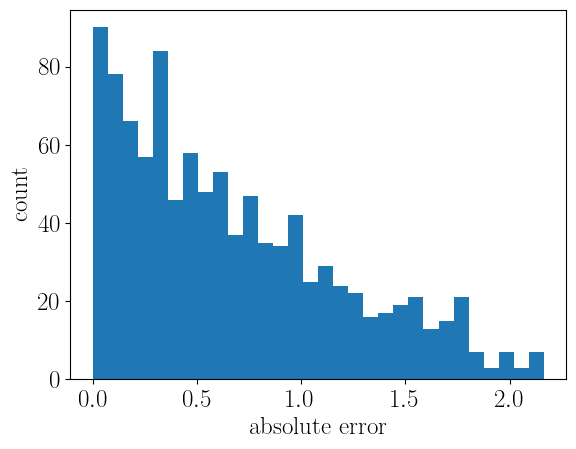

In [282]:
error_hist(test_normalized_pred_ys, test_normalized_ys)

In [283]:
test_normalized_dys = (test_dataset["greeks"] / y_std) * x_std
# test_normalized_dys = 
print(test_normalized_dys)

[[0.028607   0.00267272]
 [0.6661262  0.04533182]
 [1.0803052  0.0160235 ]
 ...
 [0.11108205 0.01898389]
 [0.8877431  0.04856677]
 [0.8772432  0.03907793]]


In [285]:
# overall error in dS predictions
jnp.sqrt(mse(test_normalized_pred_dys[:, 0], test_normalized_dys[:, 0]))

Array(0.7722909, dtype=float32)

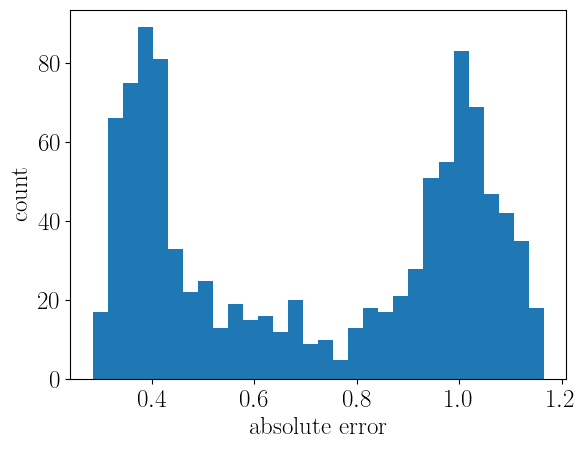

In [286]:
error_hist(test_normalized_pred_dys[:, 0], test_normalized_dys[:, 0])

In [287]:
jnp.sqrt(mse(test_normalized_pred_dys[:, 1], test_normalized_dys[:, 1]))

Array(0.2836075, dtype=float32)

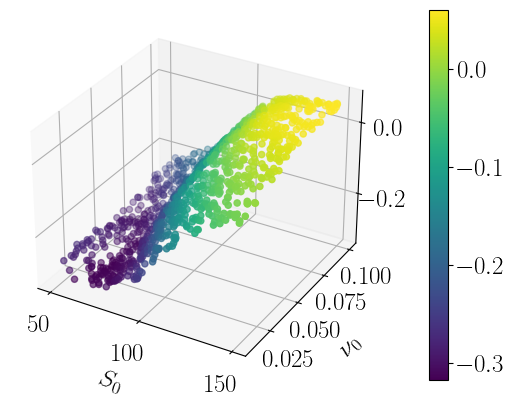

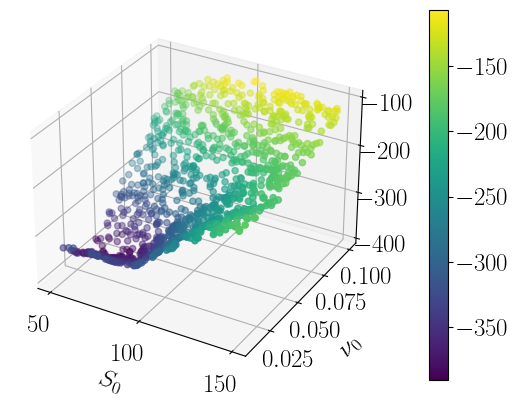

In [288]:
xs = test_dataset["initial_states"]
ys = test_normalized_pred_dys / x_std * y_std

fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys[:, 0], "predicted greeks dS")
fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys[:, 1], "predicted greeks dV")

In [289]:
test_normalized_pred_ddys = eqx.filter_vmap(jax.hessian(surrogate_model))(test_normalized_xs)
test_normalized_pred_ddys.shape

(1024, 2, 2)

In [290]:
test_normalized_xs.shape

(1024, 2)

In [291]:
(jnp.array([100, 0.09]) - x_mean) / x_std

Array([0.        , 1.34715063], dtype=float64)

In [292]:
jax.hessian(surrogate_model)((jnp.array([100, 0.09]) - x_mean) / x_std)

Array([[ 0.2272281 , -0.01238291],
       [-0.01238291,  0.10636161]], dtype=float64)

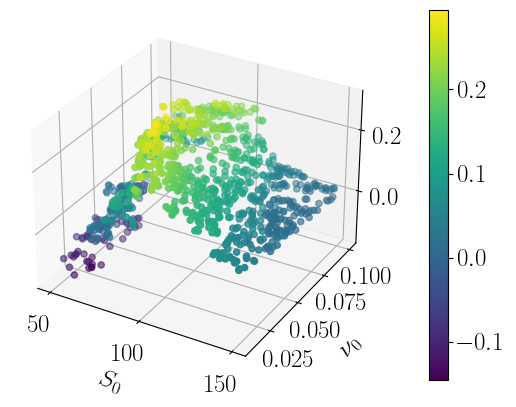

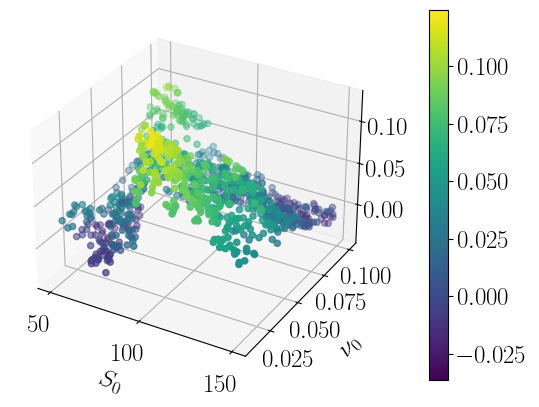

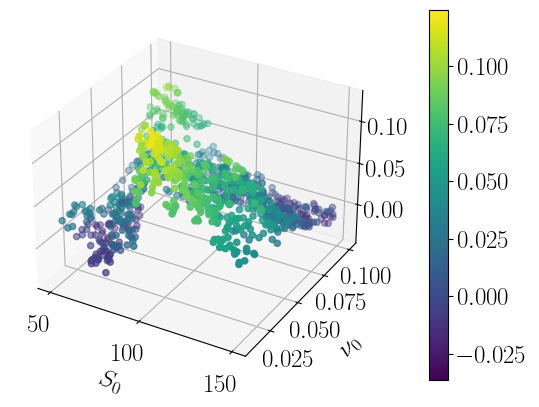

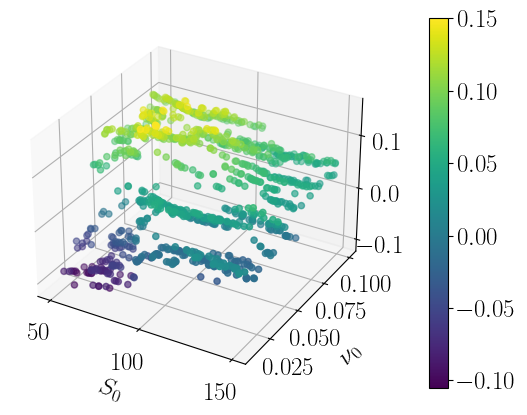

In [293]:
xs = test_dataset["initial_states"]
ys = test_normalized_pred_ddys #/ x_std * y_std

fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys[:, 0, 0], "predicted greeks dSdS")
fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys[:, 0, 1], "predicted greeks dSdV")
fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys[:, 1, 0], "predicted greeks dVdS")
fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys[:, 1, 1], "predicted greeks dVdV")

### Train with second order data

In [297]:
key = jrandom.PRNGKey(0)
key, subkey = jrandom.split(key)

# in_size is 2 for initial_spot and initial_vol
n_dims = 2
mlp = eqx.nn.MLP(key=subkey, in_size=n_dims, out_size="scalar", width_size=20, depth=3, activation=jax.nn.elu)

key, subkey = jax.random.split(key)
mlp = init_linear_weight(mlp, trunc_init, key)
surrogate_model = mlp

In [298]:
n_epochs = 60
BATCH_SIZE = 256

key = jrandom.PRNGKey(42)
generator_test_ds = None
optim = optax.adam(learning_rate=3e-4)
surrogate_model = snd_order_diff_train_otf(surrogate_model, key, generator_test_ds, optim, n_epochs=n_epochs, debug=False)


Finished epoch   0 | Train Loss: 1.20635
Finished epoch  64 | Train Loss: 0.67573
Finished epoch 128 | Train Loss: 0.55085
Finished epoch 192 | Train Loss: 1.91216
Finished epoch 256 | Train Loss: 0.45863
Finished epoch 320 | Train Loss: 0.41185
Finished epoch 384 | Train Loss: 0.61815
Finished epoch 448 | Train Loss: 0.45042
Finished epoch 512 | Train Loss: 0.50993
Finished epoch 576 | Train Loss: 0.52372
Finished epoch 640 | Train Loss: 1.19304
Finished epoch 704 | Train Loss: 0.62213
Finished epoch 768 | Train Loss: 0.58306
Finished epoch 832 | Train Loss: 0.46433
Finished epoch 896 | Train Loss: 0.50235
Finished epoch 960 | Train Loss: 0.50023
Finished epoch 1024 | Train Loss: 0.57119
Finished epoch 1088 | Train Loss: 0.56424
Finished epoch 1152 | Train Loss: 0.66601
Finished epoch 1216 | Train Loss: 0.43447
Finished epoch 1280 | Train Loss: 0.39898
Finished epoch 1344 | Train Loss: 0.41268
Finished epoch 1408 | Train Loss: 0.49989
Finished epoch 1472 | Train Loss: 0.52672
Finished

In [299]:
test_normalized_xs = test_dataset["initial_states"]
test_normalized_xs = (test_normalized_xs - x_mean) / x_std
test_normalized_ys = test_dataset["prices"]
test_normalized_ys = (test_normalized_ys - y_mean) / y_std

test_normalized_pred_ys, test_normalized_pred_dys = vmap(jax.value_and_grad(surrogate_model))(test_normalized_xs)
jnp.sqrt(mse(test_normalized_pred_ys, test_normalized_ys))

Array(0.17423947, dtype=float64)

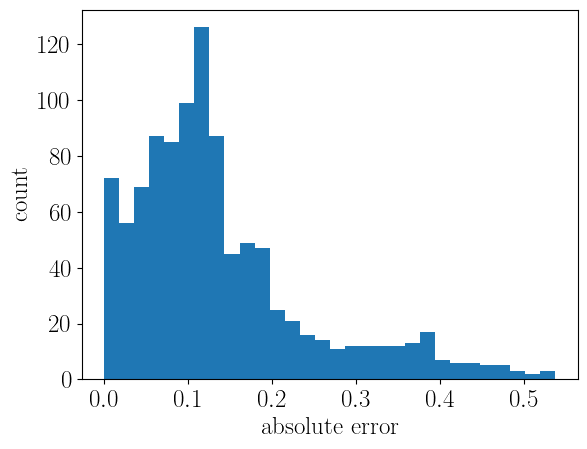

In [300]:
error_hist(test_normalized_pred_ys, test_normalized_ys)

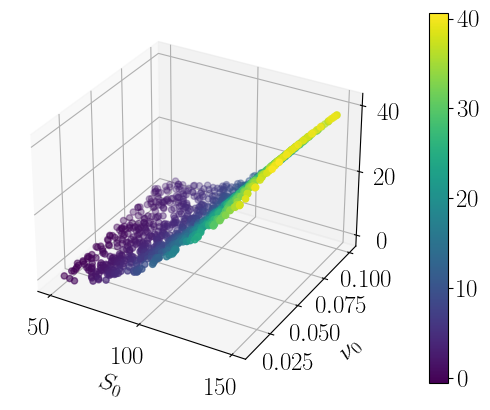

In [301]:
xs = test_dataset["initial_states"]
ys = test_normalized_pred_ys * y_std + y_mean
fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys, "predicted test set prices")

In [302]:
jnp.sqrt(mse(test_normalized_pred_dys[:, 0], test_normalized_dys[:, 0]))

Array(0.24502672, dtype=float32)

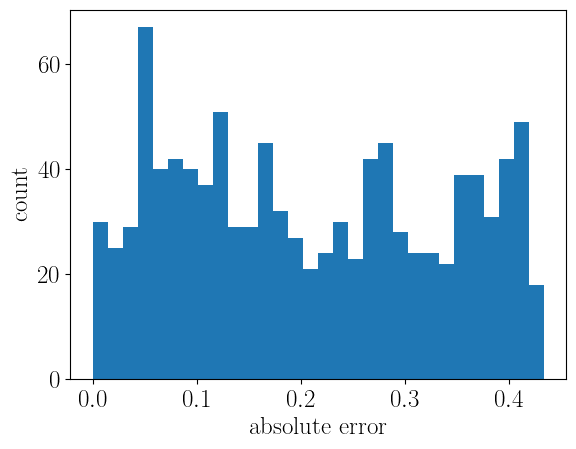

In [303]:
error_hist(test_normalized_pred_dys[:, 0], test_normalized_dys[:, 0])

In [304]:
jnp.sqrt(mse(test_normalized_pred_dys[:, 1], test_normalized_dys[:, 1]))

Array(0.04692734, dtype=float32)

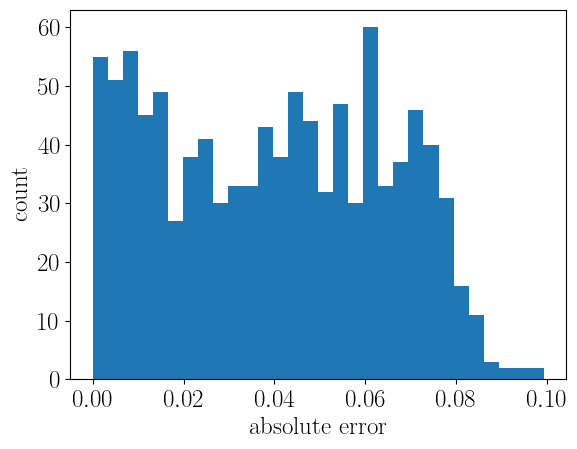

In [305]:
error_hist(test_normalized_pred_dys[:, 1], test_normalized_dys[:, 1])

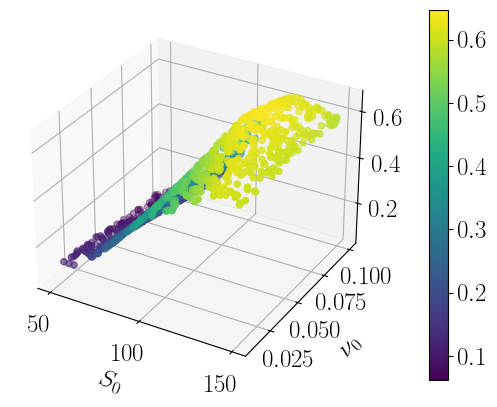

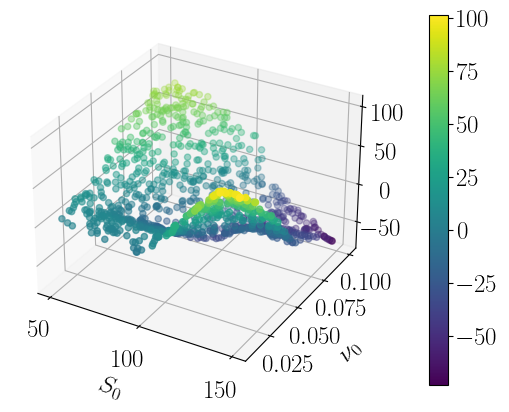

In [306]:
xs = test_dataset["initial_states"]
ys = test_normalized_pred_dys / x_std * y_std

fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys[:, 0], "predicted greeks dS")
fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys[:, 1], "predicted greeks dV")

In [307]:
test_normalized_pred_ddys = eqx.filter_vmap(jax.hessian(surrogate_model))(test_normalized_xs)
jax.hessian(surrogate_model)((jnp.array([100, 0.09]) - x_mean) / x_std)

Array([[ 0.4525539 , -0.07983593],
       [-0.07983593,  0.06653144]], dtype=float64)

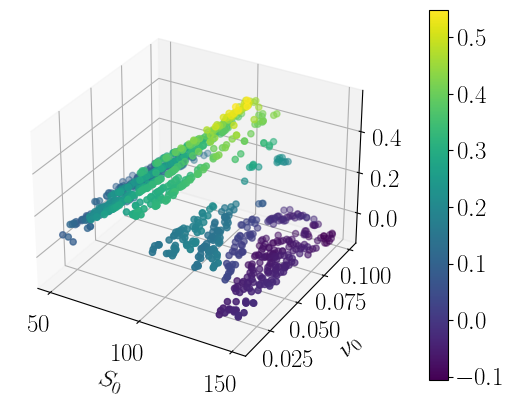

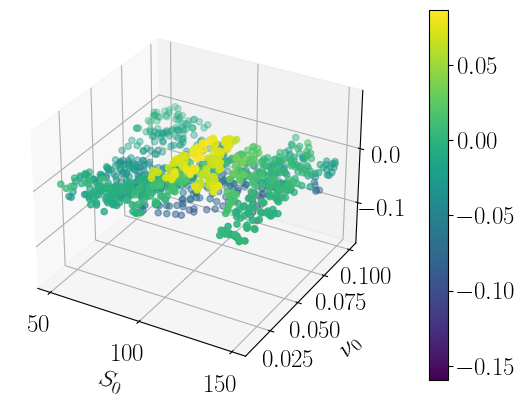

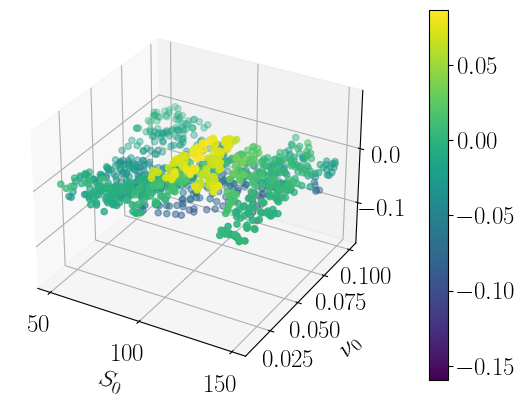

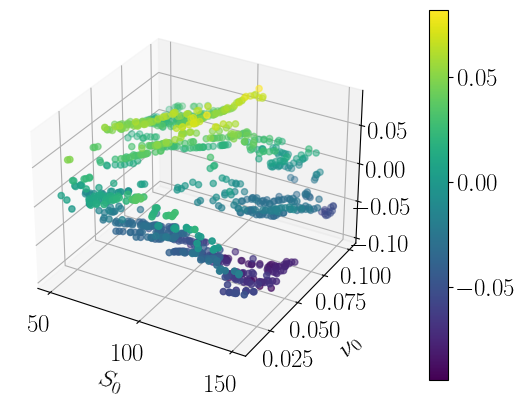

In [308]:
xs = test_dataset["initial_states"]
ys = test_normalized_pred_ddys #/ x_std * y_std

fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys[:, 0, 0], "predicted greeks dSdS")
fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys[:, 0, 1], "predicted greeks dSdV")
fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys[:, 1, 0], "predicted greeks dVdS")
fig_payoff = plot_3d_differential_data(xs[:, 0], xs[:, 1], ys[:, 1, 1], "predicted greeks dVdV")

In [309]:
pred_values, pred_derivs = jax.value_and_grad(surrogate_model)((jnp.array([100.0, 0.09]) - x_mean) / x_std)
print(pred_values * y_std + y_mean)

# unscaled predicted derivs
(payoffs_std / state_std) *  pred_derivs

10.857645277558838


Array([ 0.37929444, 21.34646994], dtype=float64)